## M2 - EDA V6_2

Rodrigo Arguello-Serrano

## 1) Problem statement

### Business context

Product listing pages, home carousels, and “related items” compete for screen real estate: more items can aid discovery, yet too much choice may stall action. Research question (RQ):

 ***How does assortment complexity during the first T minutes of a session (default T = 5) affect the probability that the session ends in a purchase?***

### Operationalization.

#### Response
PurchaseInSession ∈ {0,1}: 1 if a session contains ≥1 purchase event, else 0. (Multiple purchases in a session collapse to one order.)

#### Predictors (first T minutes).

  - Breadth_T: distinct product_id viewed.

  - CatSwitchRate_T: category transitions per minute across consecutive view events.

  - ViewPace_T: views per minute.

  - EarlyCart_T: indicator of any cart event in the first T minutes.


#### Key controls.
- Session duration
- whole‑session events/min
- hour of day
- day of week
- top‑level category mix
- mean log price in minute 1.


####Data :
Kaggle “eCommerce behavior data from multi‑category store,” Oct‑2019→Apr‑2020, event‑level view/cart/remove_from_cart/purchase logs with schema.


| Property | Description |
| :--- | :--- |
| `event_time` | Time when event happened at (in UTC). |
| `event_type` | Only one kind of event: purchase. |
| `product_id` | ID of a product. |
| `category_id` | Product's category ID. |
| `category_code` | Product's category taxonomy. (Code name) if it was possible to make it. Usually present for meaningful categories and skipped for different kinds of accessories. |
| `brand` | Downcased string of brand name. Can be missed. |
| `price` | Float price of a product. Present. |
| `user_id` | Permanent user ID. |
| **`user_session`** | Temporary user's session ID. Same for each user's session. Is changed every time user come back to online store from a long pause. |


##### Event types

Events can be:
* `view` - a user viewed a product
* `cart` - a user added a product to shopping cart
* `remove_from_cart` - a user removed a product from shopping cart
* `purchase` - a user purchased a product

##### Multiple purchases per session

A session can have multiple `purchase` events. It's ok, because it's a single order.


### Hypotheses
- H₀ (null): Early‑session breadth, switching, pace, and early‑cart show no association with PurchaseInSession after controls.

- H₁a (Breadth): Purchase probability increases with Breadth_T up to a point, then declines (inverted‑U).

- H₁b (Switching): Higher CatSwitchRate_T is associated with lower purchase probability (aimless browsing signal).

- H₁c (Pace/Intent): Higher ViewPace_T and presence of EarlyCart_T correlate positively with purchase likelihood, conditional on breadth.


### Tweaks from Milestone‑1
- Feature precision. Use top‑level token from category_code for switching; treat nulls as “unknown.” Compute CatSwitchRate_T as transitions/min among time‑ordered views. Confirm purchase collapsing per session.

- Scope & validation. Begin with Oct/Nov files to prove the pipeline and to preserve a natural time split; scale to Oct–Apr after checks.


- Professor’s guidance folded in. Generate descriptives to verify distributions/missingness; visualize the Breadth_T → purchase curve to test the inverted‑U; and probe confounding via stratified/cohort plots (e.g., by day‑part and CatSwitchRate_T terciles).


- Sensitivity. Re‑estimate with alternative windows T ∈ {3,5,8} and retain controls listed above.

### 2) Dataset

#### **Source & coverage.**
Primary source: Kaggle — eCommerce behavior data from a multi‑category store (Open CDP / REES46). The corpus contains 285M event‑level records spanning Oct-2019 → Apr-2020, provided as monthly CSV/Parquet files (~1.6–2.7 GB each).

#### **Schema (per row)**
`event_time (UTC timestamp), event_type, product_id, category_id, category_code, brand, price, user_id, user_session.` Field notes: `category_code` is a dot‑separated taxonomy (e.g., `electronics.smartphone`) and is sometimes missing; `brand` is lower‑cased and may be missing; `user_session` is a temporary session identifier that resets after a long pause; `price` is a floating‑point value.


#### **Event types & sessionization**
Events include `view, cart, remove_from_cart,` and `purchase`. A single session can contain multiple purchase events—these correspond to one order. For session‑level analysis I collapse this to the binary target `PurchaseInSession` = 1 if ≥1 purchase in the session, else 0. (For robustness checks I may also compute ItemsPurchasedInSession and OrderValueInSession as session‑level aggregates.)

#### **Scale preview & initial expectations (to be verified in EDA)**
From the Kaggle Nov‑2019 file preview: ~67.5M events; event_type mix ≈ view 94%, cart 4%, remainder ≈ 1% (`remove_from_cart` + `purchase`); `category_code` ≈ 32% null; brand ≈ 14% null; and ≈ 13.8M unique user_session. I will treat these as priors and recalculate all figures directly from the raw files during EDA.

Attribution.
As requested by the source, final materials will credit the Kaggle dataset and the REES46 Marketing Platform

###3) Data joining/cleaning

#### **Read strategy** for scale

It begins with October/November to demonstrate the pipeline for approximately two months, and then “turns the dial” to the entire October-April set. Why Oct/Nov? Two successive months provide an inherent time split for verification later, including a holiday ramp from the beginning (a stress test for volume), and keeping compute/I/O in check before scaling to the entire ~285M events and all months. It also adheres to milestone guidance to cache long calcs so that reviewers won't have to re-run heavy steps.
(Columns presumed from the database schema: `event_time, event_type, product_id, category_id, category_code, brand, price, user_id, user_session`)



In [1]:
%%writefile config.py
# =========================
# Cell 0.0 — Write config.py, declaring GLOBALS
# =========================
# ---- Config ----
from pathlib import Path
import polars as pl
import sys
import os

# Define the project directory path
PROJECT_DIR = Path("../")

# Create the directory if it doesn't exist
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Add the directory containing config.py to the Python path
config_path = PROJECT_DIR
if str(config_path) not in sys.path:
    sys.path.insert(0, str(config_path))

# Project roots
DATA_DIR    = PROJECT_DIR / "data"
OUT_DIR     = PROJECT_DIR / "cache_data"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Month scopes
MONTHS_FULL = ["2019-Oct","2019-Nov","2019-Dec","2020-Jan","2020-Feb","2020-Mar","2020-Apr"]
# MONTHS      = ["2019-Oct","2019-Nov","2019-Dec","2020-Jan","2020-Feb","2020-Mar","2020-Apr"]  # starter focus
MONTHS      = ["2020-Jan","2020-Feb","2020-Mar",]  # starter focus

# Session feature window
T_MIN = 5

# CSV schema (avoid guessing)
CSV_DTYPES = {
    "event_time":   pl.Utf8,     # parsed to tz-aware UTC downstream
    "event_type":   pl.Utf8,
    "product_id":   pl.Int64,
    "category_id":  pl.Int64,
    "category_code":pl.Utf8,
    "brand":        pl.Utf8,
    "price":        pl.Float64,
    "user_id":      pl.Int64,
    "user_session": pl.Utf8,
}

FEATURE_COLS = [
    "event_time","event_type","product_id","category_id",
    "category_code","brand","price","user_id","user_session",
]

# Leakage-safe train/test pairs
LEAK_PAIRS = [
    ("2019-Oct","2019-Nov"),
    ("2019-Dec","2020-Jan"),
    ("2020-Feb","2020-Mar"),
    ("2020-Apr",),  # tail single
]
#LEAK_MONTHS = ["2019-Oct", "2019-Nov", "2019-Dec"]
LEAK_MONTHS   = [ "2020-Apr"]
MONTHS_ORDERED = MONTHS_FULL
WRITE_COMBINED = True

Overwriting config.py


In [2]:
# =========================
# Cell 0.1 — Boot + helpers (robust config import; low-RAM safe)
# =========================
from pathlib import Path
from datetime import datetime
from pprint import pformat
import os, sys, importlib
import polars as pl

import config            # now available to all later cells


# ---- print configs (drop-in) ----
def _print_cfg(
    names=(
        "DATA_DIR", "OUT_DIR", "MONTHS", "MONTHS_FULL",
        "T_MIN", "SESS_MONTHS", "T_FOR_SESS",
        "LEAK_MONTHS", "LEAK_PAIRS", "MONTHS_ORDERED", "WRITE_COMBINED",
    )
):
    """
    Pretty-print a subset of configuration variables from the global scope
    and the imported ``config`` module.

    This is intended as a drop-in utility for quick sanity checks in notebooks.
    It will look for each requested name first in ``globals()``, then as an
    attribute on the imported ``config`` module.

    Parameters
    ----------
    names : iterable of str, optional
        Configuration names to display. By default, shows common project
        globals such as ``DATA_DIR``, ``OUT_DIR``, ``MONTHS``, ``T_MIN``,
        ``LEAK_MONTHS``, etc.

    Notes
    -----
    * Any values that are :class:`pathlib.Path` objects are stringified so the
      output is JSON-/log-friendly.
    * The function is side-effect-only: it prints to stdout and returns None.
    """
    from pathlib import Path
    from pprint import pprint
    from datetime import datetime

    g = globals()
    cfg = {}
    for n in names:
        if n in g or hasattr(config, n):
            v = g.get(n, getattr(config, n, None))
            if isinstance(v, Path):
                v = str(v)
            cfg[n] = v

    print(f"=== Config @ {datetime.now().isoformat(timespec='seconds')} ===")
    pprint(cfg, sort_dicts=False)
    print("-" * 60)


# --- file discovery & scan ---
def discover_month_files(data_dir: Path, months: list[str]) -> list[Path]:
    """
    Locate per-month input files, preferring cached Parquet over raw sources.

    For each month tag (e.g. ``\"2019-Oct\"``) this checks, in order:

    1. ``config.OUT_DIR / \"{month}.parquet\"``  (cached features/raw)
    2. ``data_dir / \"{month}.parquet\"``        (raw Parquet, if present)
    3. ``data_dir / \"{month}.csv\"``
    4. ``data_dir / \"{month}.xlsx\"``
    5. ``data_dir / \"{month}.xls\"``

    The first existing file is returned for each month.

    Parameters
    ----------
    data_dir : Path
        Root directory containing the raw monthly files (CSV / Parquet / Excel).
    months : list of str
        Month tags such as ``\"2019-Oct\"``, ``\"2019-Nov\"``, etc.

    Returns
    -------
    list of Path
        One resolved path per month, in the same order as ``months``.

    Raises
    ------
    FileNotFoundError
        If no candidate file is found for any given month tag.
    """
    out = []
    for m in months:
        candidates = [
            config.OUT_DIR / f"{m}.parquet",   # cached Parquet
            data_dir / f"{m}.parquet",         # raw Parquet (if any)
            data_dir / f"{m}.csv",
            data_dir / f"{m}.xlsx",
            data_dir / f"{m}.xls",
        ]
        hit = next((p for p in candidates if p.exists()), None)
        if not hit:
            raise FileNotFoundError(f"No file for {m} in OUT_DIR/DATA_DIR")
        out.append(hit)
    return out


def scan_month(path: Path) -> pl.LazyFrame:
    """
    Lazily scan a monthly events file and normalize core dtypes.

    This helper abstracts away the input format (Parquet / CSV / Excel) and
    returns a :class:`polars.LazyFrame` with a consistent schema suitable for
    downstream feature engineering.

    Supported formats
    -----------------
    * ``.parquet`` – read via :func:`polars.scan_parquet`
    * ``.csv``     – read via :func:`polars.scan_csv` using
      ``config.CSV_DTYPES`` and no schema inference
    * ``.xlsx`` / ``.xls`` – read via :mod:`pandas`, then converted to Polars

    Normalization steps
    -------------------
    * ``event_time`` is parsed from UTF-8 string, stripped of timezone suffixes
      like ``\" UTC\"``, ``\"Z\"`` or ``\"+00:00\"``, and converted to a
      timezone-aware ``Datetime[UTC]`` column.
    * ``event_type``, ``category_code`` and ``brand`` are cast to
      ``pl.Categorical`` for compact storage.
    * ``price`` is cast to ``pl.Float64``.
    * ``product_id``, ``category_id`` and ``user_id`` are cast to ``pl.Int64``.
    * ``user_session`` is cast to ``pl.Utf8``.

    Parameters
    ----------
    path : Path
        Path to a single monthly file.

    Returns
    -------
    polars.LazyFrame
        Lazy frame with columns restricted to ``config.FEATURE_COLS`` and
        normalized dtypes.

    Raises
    ------
    ValueError
        If the file extension is not one of the supported formats.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path,
            has_header=True,
            schema_overrides=config.CSV_DTYPES,   # all columns fully specified
            infer_schema_length=0,                # skip inference for speed
            ignore_errors=False,
        )
    elif suf in (".xlsx", ".xls"):
        import pandas as pd
        df = pd.read_excel(path)
        lf = pl.from_pandas(df, nan_to_null=True).lazy()
    else:
        raise ValueError(f"Unsupported file type: {path}")

    return (
        lf.select(config.FEATURE_COLS)
          .with_columns(
              pl.col("event_time")
                .cast(pl.Utf8)
                .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
                .str.to_datetime(strict=False, time_zone="UTC"),
              pl.col(["event_type", "category_code", "brand"]).cast(pl.Categorical),
              pl.col("price").cast(pl.Float64),
              pl.col(["product_id", "category_id", "user_id"]).cast(pl.Int64),
              pl.col("user_session").cast(pl.Utf8),
          )
    )


def nice_print(timestamps, message, obj=None, pl_obj=None, preview=5):
    """
    Convenience logger for notebooks: timestamped message + optional payloads.

    This helper is designed to keep cell output readable when debugging pipeline
    steps. It supports:

    * a single timestamp, string, or iterable of timestamps in the header
    * a generic Python object pretty-printed via :func:`pprint.pformat`
    * a Polars object preview (LazyFrame/DataFrame/Series), with a limited
      number of rows.

    Parameters
    ----------
    timestamps : datetime | str | iterable | None
        Timestamp(s) to show in the log header. If ``None``, only ``message``
        is printed. If an iterable, all items are joined with ``" | "``.
    message : str
        Human-readable message describing the action or state.
    obj : Any, optional
        Arbitrary Python object (dict, list, etc.) to pretty-print beneath
        the message.
    pl_obj : polars.LazyFrame | polars.DataFrame | polars.Series, optional
        Polars object to preview. LazyFrames are collected before preview.
    preview : int, default 5
        Number of rows to show when printing Polars tabular objects.

    Notes
    -----
    * If Polars is not importable, the Polars preview is skipped gracefully.
    * This function prints to stdout and returns ``None``.
    """
    # --- header ---
    def _fmt_ts(t):
        return t.isoformat(timespec="seconds") if isinstance(t, datetime) else str(t)

    if timestamps is None:
        header = ""
    elif isinstance(timestamps, (list, tuple, set)):
        header = " | ".join(_fmt_ts(t) for t in timestamps)
    else:
        header = _fmt_ts(timestamps)

    print(f"[{header}] {message}" if header else message)

    # --- Python object ---
    if obj is not None:
        print(pformat(obj, width=100, compact=True))

    # --- Polars object ---
    if pl_obj is not None:
        try:
            import polars as pl
        except Exception:
            print("(Polars not installed — skipping Polars display)")
            return

        if isinstance(pl_obj, pl.LazyFrame):
            df = pl_obj.collect()
            print(f"Polars LazyFrame (collected): shape={df.shape}")
            print(df.head(preview))
        elif isinstance(pl_obj, pl.DataFrame):
            print(f"Polars DataFrame: shape={pl_obj.shape}")
            print(pl_obj.head(preview))
        elif isinstance(pl_obj, pl.Series):
            print(f"Polars Series: name={pl_obj.name!r}, len={len(pl_obj)})")
            print(pl_obj.head(preview))
        else:
            print(f"(Unknown Polars type: {type(pl_obj).__name__})")


# =========================
# Hotfix — rebuild build_session_features_lazy with 2-pass deps
# =========================
def build_session_features_lazy(lf: pl.LazyFrame, T: int | None = None) -> pl.LazyFrame:
    """
    Build session-level features from raw event logs in a leak-free, 2-pass way.

    Given an event-level :class:`polars.LazyFrame` with at least:

    * ``user_session``
    * ``user_id``
    * ``event_time``
    * ``event_type``
    * ``category_code``
    * ``price``

    this function constructs one row per session with:

    * whole-session targets/controls
      - ``PurchaseInSession`` (binary: any purchase in session)
      - ``SessionDurationMin``
      - ``EventsPerMin``
      - ``DayPart`` (night / morning / afternoon / evening)
      - ``DayOfWeek`` (0–6)
    * early-window (first T minutes) behavioral features
      - ``Breadth_T`` (distinct products viewed)
      - ``ViewPace_T`` (views per minute in first T)
      - ``CatSwitchRate_T`` (category transitions per minute in first T)
      - ``EarlyCart_T`` (any cart in first T)
      - ``MeanLogPrice_1min`` (mean log(price) among first-minute views > 0)

    Implementation details
    ----------------------
    * **Pass 1** computes core helpers:

      ``mins_from_start``, one-hot flags for event_type, top-level
      ``category_top``, and ``session_month``.

    * **Pass 2** derives:

      ``is_first_T`` and ``is_first_min`` from ``mins_from_start``.

    * Session-level aggregates are computed in ``sessions_all``; first-T window
      aggregates from view events live in ``sessions_T``.

    * Category transitions are made deterministic by sorting
      ``["user_session", "event_time"]`` before applying ``shift`` within
      groups.

    Parameters
    ----------
    lf : polars.LazyFrame
        Event-level lazy frame for one or more months of data.
    T : int or None, optional
        Early-session window in minutes. If ``None``, falls back to
        ``config.T_MIN`` (default 5).

    Returns
    -------
    polars.LazyFrame
        Session-level LazyFrame with one row per ``user_session`` and the
        following columns (ordered):

        ``[
            "user_session", "user_id", "session_start", "session_month",
            "SessionDurationMin", "EventsPerMin", "DayPart", "DayOfWeek",
            "Breadth_T", "CatSwitchRate_T", "ViewPace_T", "EarlyCart_T",
            "MeanLogPrice_1min", "PurchaseInSession",
        ]``

    Notes
    -----
    * Nulls in ``Breadth_T``, ``ViewPace_T``, ``CatSwitchRate_T`` and
      ``EarlyCart_T`` are filled with 0/0.0 to keep downstream typing simple.
    * ``SessionDurationMin`` is floored to a small positive value
      (1/60 minute) when non-positive, to avoid division by zero in
      ``EventsPerMin``.
    """
    T = int(T or getattr(config, "T_MIN", 5))

    # Session roots
    sess_start = (
        lf.group_by("user_session")
          .agg(
              pl.col("event_time").min().alias("session_start"),
              pl.col("user_id").first().alias("user_id"),
          )
    )

    # Join once
    base = lf.join(sess_start, on="user_session", how="left")

    # PASS 1: create mins_from_start and other primitives
    base = base.with_columns(
        ((pl.col("event_time").dt.epoch("ms") - pl.col("session_start").dt.epoch("ms")) / 60000.0)
            .alias("mins_from_start"),
        (pl.col("event_type") == "view").cast(pl.Int8).alias("is_view"),
        (pl.col("event_type") == "cart").cast(pl.Int8).alias("is_cart"),
        (pl.col("event_type") == "purchase").cast(pl.Int8).alias("is_purchase"),
        pl.when(pl.col("category_code").is_null())
          .then(pl.lit("unknown"))
          .otherwise(pl.col("category_code").cast(pl.Utf8).str.split(by=".").list.get(0))
          .alias("category_top"),
        pl.col("session_start").dt.strftime("%Y-%m").alias("session_month"),
    )

    # PASS 2: columns that depend on mins_from_start
    base = base.with_columns(
        (pl.col("mins_from_start") <= T).alias("is_first_T"),
        (pl.col("mins_from_start") < 1).alias("is_first_min"),
    )

    # Whole-session targets & controls
    sessions_all = (
        base.group_by("user_session")
            .agg(
                pl.first("session_start").alias("session_start"),
                pl.first("session_month").alias("session_month"),
                pl.first("user_id").alias("user_id"),
                pl.len().alias("EventsTotal"),
                (pl.col("is_purchase").sum() > 0).cast(pl.Int8).alias("PurchaseInSession"),
                ((pl.max("event_time").dt.epoch("ms") - pl.min("event_time").dt.epoch("ms")) / 60000.0)
                    .alias("SessionDurationMin"),
            )
            .with_columns(
                pl.when(pl.col("SessionDurationMin") <= 0)
                  .then(pl.lit(1.0/60))
                  .otherwise(pl.col("SessionDurationMin"))
                  .alias("SessionDurationMin_safe"),
                (pl.col("EventsTotal") / pl.col("SessionDurationMin_safe")).alias("EventsPerMin"),
                pl.col("session_start").dt.hour().alias("hour"),
            )
            .with_columns(
                pl.when(pl.col("hour") < 6).then(pl.lit("night"))
                 .when(pl.col("hour") < 12).then(pl.lit("morning"))
                 .when(pl.col("hour") < 18).then(pl.lit("afternoon"))
                 .otherwise(pl.lit("evening"))
                 .alias("DayPart"),
                pl.col("session_start").dt.weekday().alias("DayOfWeek"),
            )
            .select([
                "user_session", "user_id", "session_start", "session_month",
                "SessionDurationMin", "EventsPerMin", "DayPart", "DayOfWeek", "PurchaseInSession",
            ])
    )

    # First-T window
    firstT = base.filter(pl.col("is_first_T"))

    # Deterministic within-session ordering for transitions
    views_T = (
        firstT
        .filter(pl.col("is_view") == 1)
        .sort(["user_session", "event_time"])  # ensure chrono order for shift
        .with_columns(
            pl.col("category_top").shift(1).over("user_session").alias("prev_cat")
        )
        .with_columns(
            pl.when(pl.col("prev_cat").is_null())
              .then(pl.lit(0))
              .otherwise(pl.col("category_top").ne(pl.col("prev_cat")).cast(pl.Int64))
              .alias("trans")
        )
    )

    views_agg = (
        views_T.group_by("user_session")
               .agg(
                   pl.len().alias("Views_T"),
                   pl.n_unique("product_id").alias("Breadth_T"),
                   pl.sum("trans").alias("CatTransitions_T"),
                   pl.col("price")
                     .filter(pl.col("is_first_min") & (pl.col("price") > 0))
                     .log()
                     .mean()
                     .alias("MeanLogPrice_1min"),
               )
    )

    carts_agg = (
        firstT.group_by("user_session")
              .agg((pl.col("is_cart").sum() > 0).cast(pl.Int8).alias("EarlyCart_T"))
    )

    sessions_T = (
        views_agg.join(carts_agg, on="user_session", how="left")
                 .with_columns(
                     (pl.col("Views_T") / pl.lit(T)).alias("ViewPace_T"),
                     (pl.col("CatTransitions_T") / pl.lit(T)).alias("CatSwitchRate_T"),
                     pl.col("EarlyCart_T").fill_null(0),
                 )
    )

    return (
        sessions_all.join(sessions_T, on="user_session", how="left")
            .with_columns(
                pl.col("Breadth_T").fill_null(0),
                pl.col("ViewPace_T").fill_null(0.0),
                pl.col("CatSwitchRate_T").fill_null(0.0),
                pl.col("EarlyCart_T").fill_null(0),
                pl.col("MeanLogPrice_1min").cast(pl.Float64),
            )
            .select([
                "user_session", "user_id", "session_start", "session_month",
                "SessionDurationMin", "EventsPerMin", "DayPart", "DayOfWeek",
                "Breadth_T", "CatSwitchRate_T", "ViewPace_T", "EarlyCart_T",
                "MeanLogPrice_1min", "PurchaseInSession",
            ])
    )


In [3]:
# =========================
# Cell 0.2 — Polars version, GPU config checks
# =========================
import polars as pl
import config  # noqa: F401  # imported for consistency with other cells

nice_print(datetime.now(), message=f"Polars: {pl.__version__}")


def _gpu_engine():
    """
    Return the engine argument to use when testing Polars GPU support.

    On newer Polars builds (that expose :class:`polars.GPUEngine`) this
    constructs a ``GPUEngine`` instance with ``raise_on_fail=False`` so that
    GPU execution is attempted but will fall back cleanly to CPU if the GPU
    is not available or misconfigured.

    On older Polars builds (that do not have ``GPUEngine``), this returns
    the literal string ``"gpu"`` which is understood by legacy versions of
    :meth:`LazyFrame.collect` as the engine selector.

    Returns
    -------
    polars.GPUEngine | str
        A GPU engine handle or the legacy ``"gpu"`` token that can be passed
        as ``engine=_gpu_engine()`` into ``collect()``.
    """
    # Prefer explicit GPUEngine if present; otherwise old-style "gpu" token.
    return pl.GPUEngine(raise_on_fail=False) if hasattr(pl, "GPUEngine") else "gpu"


try:
    pl.LazyFrame({"x": [1, 2, 3]}).select(pl.col("x").sum()).collect(engine=_gpu_engine())
    nice_print(datetime.now(), message="GPU engine usable (or cleanly falling back).")
except Exception as e:
    nice_print(datetime.now(), message="GPU engine not usable:")


[2025-12-17T21:05:45] Polars: 1.36.1
[2025-12-17T21:05:45] GPU engine not usable:


In [4]:
# =========================
# Cell 0.3 — CSV → Parquet (one-time, streaming) + selective refresh
# =========================
from pathlib import Path
import sys
from datetime import datetime
import polars as pl

if "_print_cfg" in globals():
    _print_cfg()

# ---------- knobs (set these before running) ----------
# Example: set MONTH_FILTER = ["2020-Apr"] to refresh just April 2020.
# MONTH_FILTER: list[str] | None = None    # e.g., ["2020-Apr"] or None for default sets below
# FORCE: bool = False                      # set True to overwrite existing .parquet for months in MONTH_FILTER
MONTH_FILTER = None
FORCE = True


# ---------- helpers ----------
def _csv_path(month: str) -> Path:
    """
    Build the expected CSV path for a given month tag.

    Parameters
    ----------
    month : str
        Month identifier such as ``"2019-Oct"`` or ``"2020-Apr"``.

    Returns
    -------
    pathlib.Path
        Path under ``config.DATA_DIR`` pointing to ``"{month}.csv"``.
    """
    return config.DATA_DIR / f"{month}.csv"


def _parquet_path(month: str) -> Path:
    """
    Build the canonical Parquet cache path for a given month tag.

    The Parquet file is written into ``config.OUT_DIR`` so that all derived
    artifacts live under the cache directory instead of cluttering the raw
    data tree.

    Parameters
    ----------
    month : str
        Month identifier such as ``"2019-Oct"`` or ``"2020-Apr"``.

    Returns
    -------
    pathlib.Path
        Path under ``config.OUT_DIR`` pointing to ``"{month}.parquet"``.
    """
    # Write to cache_data so all derived artifacts live under OUT_DIR
    return config.OUT_DIR / f"{month}.parquet"


def _scan_csv_month(path_csv: Path) -> pl.LazyFrame:
    """
    Lazily scan a monthly CSV and normalize it into the project schema.

    This is a low-RAM helper that:

    * reads the CSV with an explicit schema (``config.CSV_DTYPES``) and
      no inference;
    * parses ``event_time`` as a timezone-aware UTC ``Datetime`` after
      stripping legacy suffixes like ``" UTC"``, ``"Z"`` or ``"+00:00"``;
    * restricts columns to ``config.FEATURE_COLS`` when defined;
    * casts high-cardinality string columns (``event_type``,
      ``category_code``, ``brand``) to ``Categorical`` to shrink the
      resulting Parquet file.

    Parameters
    ----------
    path_csv : pathlib.Path
        Path to the monthly CSV file.

    Returns
    -------
    polars.LazyFrame
        A lazy frame with a normalized schema, ready to be written to
        Parquet or fed into downstream feature builders.
    """
    lf = pl.scan_csv(
        path_csv,
        has_header=True,
        schema_overrides=getattr(config, "CSV_DTYPES", None),
        infer_schema_length=0,  # skip extra inference; schema provided
    )
    lf = lf.with_columns(
        pl.col("event_time")
          .cast(pl.Utf8)
          .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
          .str.to_datetime(strict=False, time_zone="UTC")
    )
    names = lf.collect_schema().names()
    keep = [c for c in getattr(config, "FEATURE_COLS", names) if c in names]
    lf = lf.select(keep)

    # Compact high-card strings up front; keeps the resulting Parquet smaller
    cats = [c for c in ("event_type", "category_code", "brand") if c in keep]
    if cats:
        lf = lf.with_columns(pl.col(cats).cast(pl.Categorical))

    return lf


def csv_to_parquet_for_month(month: str, *, force: bool = False) -> dict:
    """
    Convert a single month's CSV file to Parquet, with idempotent behavior.

    This function encapsulates the CSV→Parquet logic for one month tag:

    * If no CSV exists but a Parquet cache does, it assumes conversion was
      done previously and returns a “skipped (parquet exists)” result.
    * If neither CSV nor Parquet exists, it logs and returns a “skipped
      (no CSV)” result.
    * If Parquet exists and ``force=False``, it skips re-write.
    * Otherwise, it lazily scans the CSV via :func:`_scan_csv_month` and
      writes a compressed Zstandard Parquet file to ``config.OUT_DIR``.

    Parameters
    ----------
    month : str
        Month identifier such as ``"2019-Oct"`` or ``"2020-Apr"``.
    force : bool, keyword-only, default False
        If True, overwrite any existing Parquet file for that month. If
        False, existing Parquet caches are reused and not regenerated.

    Returns
    -------
    dict
        A small status dictionary with keys like:

        * ``"month"`` (str)
        * ``"ok"`` (bool)
        * ``"skipped"`` (bool)
        * ``"reason"`` (str, when skipped)
        * ``"parquet"`` (str path, when present)
        * ``"rows"`` (int row count, when Parquet exists)

    Notes
    -----
    * All logging is done via :func:`nice_print` with timestamps.
    * Conversion uses a streaming ``sink_parquet`` call to keep memory
      usage low on large monthly files.
    """
    ts = datetime.now()
    src_csv = _csv_path(month)
    dst_parq = _parquet_path(month)

    if not src_csv.exists():
        # Nothing to do (maybe already Parquet-only month)
        if dst_parq.exists():
            rows = int(pl.scan_parquet(dst_parq).select(pl.len()).collect()["len"][0])
            nice_print(
                ts,
                f"[{month}] No CSV found; Parquet already present.",
                obj={"parquet": str(dst_parq), "rows": rows},
            )
            return {
                "month": month,
                "ok": True,
                "skipped": True,
                "reason": "no_csv_parquet_exists",
                "rows": rows,
            }
        nice_print(ts, f"[{month}] Skipped: no CSV present.", obj={"csv": str(src_csv)})
        return {"month": month, "ok": True, "skipped": True, "reason": "no_csv"}

    if dst_parq.exists() and not force:
        rows = int(pl.scan_parquet(dst_parq).select(pl.len()).collect()["len"][0])
        nice_print(
            ts,
            f"[{month}] Parquet exists (skip).",
            obj={"parquet": str(dst_parq), "rows": rows},
        )
        return {
            "month": month,
            "ok": True,
            "skipped": True,
            "parquet": str(dst_parq),
            "rows": rows,
        }

    # Convert (streamed write; low RAM)
    lf = _scan_csv_month(src_csv)
    lf.sink_parquet(dst_parq, compression="zstd")

    rows = int(pl.scan_parquet(dst_parq).select(pl.len()).collect()["len"][0])
    nice_print(
        ts,
        f"[{month}] CSV → Parquet written.",
        obj={"parquet": str(dst_parq), "rows": rows, "force": force},
    )
    return {
        "month": month,
        "ok": True,
        "skipped": False,
        "parquet": str(dst_parq),
        "rows": rows,
    }


def convert_csvs_to_parquet(
    months: list[str],
    *,
    force: bool = False,
    month_filter: list[str] | None = None,
) -> list[dict]:
    """
    Batch-convert CSV months to Parquet with optional filtering.

    This is the top-level driver for CSV→Parquet conversion in the notebook.
    It is typically called twice:

    * once on a small “pair” window (e.g., ``LEAK_MONTHS``) to smoke-test the
      pipeline; and
    * once on the full month range.

    Parameters
    ----------
    months : list of str
        Month tags to consider (e.g., ``["2019-Oct", "2019-Nov", ...]``).
    force : bool, keyword-only, default False
        Passed through to :func:`csv_to_parquet_for_month`; if True, forces
        overwriting Parquet outputs for the selected months.
    month_filter : list of str or None, keyword-only, optional
        If provided, only months that appear in this list are processed.
        If ``None``, all months in ``months`` are considered.

    Returns
    -------
    list of dict
        A list of status dictionaries, one per processed month, in the order
        of ``target_months``.

    Notes
    -----
    * Logs a start and end message (via :func:`nice_print`) with basic
      aggregate counts for how many months were written vs skipped.
    * Does not raise if individual months are skipped due to missing CSV;
      see each element's ``"ok"``/``"reason"`` fields instead.
    """
    ts = datetime.now()
    # Apply filter if provided
    target_months = [m for m in months if (month_filter is None or m in month_filter)]
    nice_print(ts, "CSV → Parquet conversion start", obj={"months": target_months, "force": force})

    results = []
    for m in target_months:
        results.append(csv_to_parquet_for_month(m, force=force))

    wrote   = sum(1 for r in results if r.get("ok") and not r.get("skipped"))
    skipped = sum(1 for r in results if r.get("ok") and r.get("skipped"))
    nice_print(
        datetime.now(),
        "CSV → Parquet conversion done",
        obj={"total": len(results), "wrote": wrote, "skipped": skipped},
    )
    return results


# ---------- run (pair first, then full window) ----------
pair_months = list(getattr(config, "LEAK_MONTHS", config.MONTHS))
full_months = list(getattr(config, "MONTHS_FULL", pair_months))

# If you want to refresh just a specific month, set MONTH_FILTER = ["2020-Apr"] above and FORCE=True/False as needed.
convert_csvs_to_parquet(pair_months, force=FORCE, month_filter=MONTH_FILTER)
convert_csvs_to_parquet(full_months, force=FORCE, month_filter=MONTH_FILTER)


=== Config @ 2025-12-17T21:05:45 ===
{'DATA_DIR': '../data',
 'OUT_DIR': '../cache_data',
 'MONTHS': ['2020-Jan', '2020-Feb', '2020-Mar'],
 'MONTHS_FULL': ['2019-Oct',
                 '2019-Nov',
                 '2019-Dec',
                 '2020-Jan',
                 '2020-Feb',
                 '2020-Mar',
                 '2020-Apr'],
 'T_MIN': 5,
 'LEAK_MONTHS': ['2020-Apr'],
 'LEAK_PAIRS': [('2019-Oct', '2019-Nov'),
                ('2019-Dec', '2020-Jan'),
                ('2020-Feb', '2020-Mar'),
                ('2020-Apr',)],
 'MONTHS_ORDERED': ['2019-Oct',
                    '2019-Nov',
                    '2019-Dec',
                    '2020-Jan',
                    '2020-Feb',
                    '2020-Mar',
                    '2020-Apr'],
 'WRITE_COMBINED': True}
------------------------------------------------------------
[2025-12-17T21:05:45] CSV → Parquet conversion start
{'force': True, 'months': ['2020-Apr']}
[2025-12-17T21:05:45] [2020-Apr] CSV → Parquet writt

[{'month': '2019-Oct',
  'ok': True,
  'skipped': False,
  'parquet': '../cache_data/2019-Oct.parquet',
  'rows': 42448764},
 {'month': '2019-Nov',
  'ok': True,
  'skipped': False,
  'parquet': '../cache_data/2019-Nov.parquet',
  'rows': 67501979},
 {'month': '2019-Dec',
  'ok': True,
  'skipped': False,
  'parquet': '../cache_data/2019-Dec.parquet',
  'rows': 67542878},
 {'month': '2020-Jan',
  'ok': True,
  'skipped': False,
  'parquet': '../cache_data/2020-Jan.parquet',
  'rows': 55967041},
 {'month': '2020-Feb',
  'ok': True,
  'skipped': False,
  'parquet': '../cache_data/2020-Feb.parquet',
  'rows': 55318565},
 {'month': '2020-Mar',
  'ok': True,
  'skipped': False,
  'parquet': '../cache_data/2020-Mar.parquet',
  'rows': 56341241},
 {'month': '2020-Apr',
  'ok': True,
  'skipped': False,
  'parquet': '../cache_data/2020-Apr.parquet',
  'rows': 66589268}]

In [5]:
# =========================
# Cell 1.0 — Sanity Check (low-RAM, cached, no deprecations)
# =========================
from pathlib import Path
from datetime import datetime
import sys
import polars as pl

# ---------- knobs ----------
USE_CACHE   = True
CACHE_PATH  = config.OUT_DIR / "_metrics_month.parquet"
COLUMNS_NEEDED = ["event_type", "user_id", "user_session"]  # keep it lean


# ---------- helpers ----------
def discover_month_files(data_dir: Path, months: list[str]) -> list[Path]:
    """
    Discover monthly source files for the sanity check.

    For each month tag (e.g. ``"2019-Oct"``) this looks under ``data_dir``
    for the first existing file in the order:

    1. ``{month}.parquet``
    2. ``{month}.csv``
    3. ``{month}.xlsx``

    Parameters
    ----------
    data_dir : Path
        Directory containing per-month source files.
    months : list[str]
        Month identifiers such as ``"2019-Oct"`` or ``"2020-Apr"``.

    Returns
    -------
    list[Path]
        List of paths (one per month), in the same order as ``months``.

    Raises
    ------
    FileNotFoundError
        If none of the expected files exist for *any* of the requested months.
    """
    exts = (".parquet", ".csv", ".xlsx")
    out = []
    for m in months:
        for ext in exts:
            p = data_dir / f"{m}{ext}"
            if p.exists():
                out.append(p)
                break
    if not out:
        raise FileNotFoundError(f"No files found for {months} under {data_dir}")
    return out


def scan_light(path: Path) -> pl.LazyFrame:
    """
    Lazily scan a monthly file, reading only a minimal set of columns.

    This helper is designed for very low RAM usage in quick sanity checks.
    It avoids datetime parsing and restricts the schema to ``COLUMNS_NEEDED``
    so we can compute high-level metrics cheaply.

    Supported formats
    -----------------
    * ``.parquet`` – via :func:`polars.scan_parquet` with ``columns=`` filter
    * ``.csv`` – via :func:`polars.scan_csv`, then ``.select(COLUMNS_NEEDED)``
    * ``.xlsx``/``.xls`` – via :mod:`pandas.read_excel` and conversion to Polars

    Parameters
    ----------
    path : Path
        Path to a single monthly file.

    Returns
    -------
    polars.LazyFrame
        Lazy frame exposing only ``event_type``, ``user_id``, and ``user_session``.

    Raises
    ------
    ValueError
        If the file extension is not one of the supported formats.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        return pl.scan_parquet(path, columns=COLUMNS_NEEDED)
    elif suf == ".csv":
        # Projection pushdown happens after select; infer_schema_length=0 for speed.
        return (
            pl.scan_csv(path, has_header=True, infer_schema_length=0)
              .select(COLUMNS_NEEDED)
        )
    elif suf in (".xlsx", ".xls"):
        # XLSX fallback via pandas
        import pandas as pd
        df = pd.read_excel(path, usecols=COLUMNS_NEEDED)
        return pl.from_pandas(df, nan_to_null=True).lazy()
    else:
        raise ValueError(f"Unsupported file type: {path}")


def monthly_metrics_lazy(path: Path) -> pl.LazyFrame:
    """
    Compute tiny per-month event metrics as a LazyFrame.

    For a single month file, this function:

    * loads only the minimal columns via :func:`scan_light`;
    * casts ``user_session`` to ``Categorical`` to keep n_unique cheap;
    * aggregates counts per ``event_type``:
      - ``events``   – number of rows
      - ``users``    – distinct ``user_id`` values
      - ``sessions`` – distinct ``user_session`` values
    * attaches a ``month`` column derived from the file stem.

    Parameters
    ----------
    path : Path
        Path to a month-level source file (Parquet/CSV/XLSX).

    Returns
    -------
    polars.LazyFrame
        LazyFrame with columns ``["month", "event_type", "events", "users", "sessions"]``.
    """
    month = path.stem  # e.g., "2019-Oct"
    lf = scan_light(path).with_columns(
        pl.col("user_session").cast(pl.Categorical)  # shrink memory for n_unique
    )
    return (
        lf.group_by("event_type")
          .agg(
              events   = pl.len(),
              users    = pl.n_unique("user_id"),
              sessions = pl.n_unique("user_session"),
          )
          .with_columns(pl.lit(month).alias("month"))
          .select(["month", "event_type", "events", "users", "sessions"])
    )


# ---------- run ----------
# Discover the raw/cached monthly files we’ll summarize.
files = discover_month_files(config.DATA_DIR, config.MONTHS_FULL)

if USE_CACHE and CACHE_PATH.exists():
    # Fast path: reuse precomputed monthly metrics.
    metrics = pl.read_parquet(CACHE_PATH).sort(["month", "event_type"])
else:
    # Slow path: recompute metrics from source files (still very cheap).
    dfs = []
    for p in files:
        # No deprecated streaming flag needed; per-file tables are tiny.
        df_m = monthly_metrics_lazy(p).collect()
        dfs.append(df_m)
    metrics = pl.concat(dfs, how="vertical").sort(["month", "event_type"])
    if USE_CACHE:
        metrics.write_parquet(CACHE_PATH)

nice_print(
    datetime.now(),
    message="Sanity Check - Full Window",
    pl_obj=metrics,
    preview=45,
)



[2025-12-17T21:07:50] Sanity Check - Full Window
Polars DataFrame: shape=(21, 5)
shape: (21, 5)
┌──────────┬────────────┬──────────┬─────────┬──────────┐
│ month    ┆ event_type ┆ events   ┆ users   ┆ sessions │
│ ---      ┆ ---        ┆ ---      ┆ ---     ┆ ---      │
│ str      ┆ str        ┆ u32      ┆ u32     ┆ u32      │
╞══════════╪════════════╪══════════╪═════════╪══════════╡
│ 2019-Dec ┆ cart       ┆ 3394763  ┆ 923882  ┆ 1983488  │
│ 2019-Dec ┆ purchase   ┆ 1162048  ┆ 500997  ┆ 970005   │
│ 2019-Dec ┆ view       ┆ 62986067 ┆ 4576955 ┆ 15577871 │
│ 2019-Nov ┆ cart       ┆ 3028930  ┆ 826323  ┆ 1743343  │
│ 2019-Nov ┆ purchase   ┆ 916939   ┆ 441638  ┆ 773214   │
│ …        ┆ …          ┆ …        ┆ …       ┆ …        │
│ 2020-Jan ┆ purchase   ┆ 835007   ┆ 359105  ┆ 690930   │
│ 2020-Jan ┆ view       ┆ 52490785 ┆ 4383932 ┆ 13757026 │
│ 2020-Mar ┆ cart       ┆ 2968397  ┆ 807030  ┆ 1638659  │
│ 2020-Mar ┆ purchase   ┆ 1024934  ┆ 453487  ┆ 849142   │
│ 2020-Mar ┆ view       ┆ 52347910

In [6]:
# =========================
# Cell 2 — features + caching (dependency-safe, low-RAM)
# =========================
from pathlib import Path
import sys
from datetime import datetime
import polars as pl


def write_feature_cache(month: str, T: int | None = None, *, force: bool = False) -> Path:
    """
    Materialize a single month’s session feature cache as a compressed Parquet file.

    This is the core “one month” helper: it discovers an input file for the
    given month (preferring Parquet over CSV/XLSX via
    :func:`discover_month_files` from Cell 1), builds leak-free session
    features using :func:`build_session_features_lazy`, and writes the result
    to a cache path under ``config.OUT_DIR``.

    Parameters
    ----------
    month : str
        Month identifier such as ``"2019-Oct"`` or ``"2020-Mar"``.
    T : int or None, optional
        Early-session window in minutes. If ``None``, falls back to
        ``config.T_MIN``.
    force : bool, keyword-only, default False
        If True, overwrite any existing cache for this month. If False,
        the function is idempotent: it returns the existing cache path
        without recomputing.

    Returns
    -------
    pathlib.Path
        Path to the (existing or newly written) Parquet feature cache for
        the requested month.

    Notes
    -----
    * The feature builder is run lazily and written via ``sink_parquet``,
      so the full month is never loaded into memory as a single DataFrame.
    * Relies on the following helpers defined in earlier cells:
      - :func:`discover_month_files`
      - :func:`scan_month`
      - :func:`build_session_features_lazy`
      - ``_cache_path(month, T)``
    """
    T = int(T or config.T_MIN)
    src = discover_month_files(config.DATA_DIR, [month])[0]
    out = _cache_path(month, T)

    if out.exists() and not force:
        return out

    # Build lazily, write directly to Parquet (no big DataFrame in RAM)
    build_session_features_lazy(scan_month(src), T=T).sink_parquet(out, compression="zstd")
    return out


def write_feature_caches(
    months: list[str],
    T: int | None = None,
    *,
    force: bool = False,
    workers: int | None = None,
) -> dict[str, dict]:
    """
    Build (or refresh) session feature caches for multiple months.

    This is the batch driver over :func:`write_feature_cache`. It can operate
    sequentially (default, lowest RAM usage) or with light multithreading via
    :class:`concurrent.futures.ThreadPoolExecutor` when ``workers > 1``.

    Parameters
    ----------
    months : list[str]
        Month tags to process, e.g. ``["2019-Oct", "2019-Nov", ...]``.
    T : int or None, optional
        Early-session window in minutes. If ``None``, defaults to
        ``config.T_MIN``.
    force : bool, keyword-only, default False
        If True, recompute caches even when the target Parquet file exists.
        If False, existing caches are reused and marked as ``"skipped"``.
    workers : int or None, keyword-only, optional
        If provided and > 1, enables a small amount of parallelism over
        months using threads. Keep this small (e.g. 2–3) in constrained
        environments like Colab.

    Returns
    -------
    dict[str, dict]
        A mapping from month tag to a status dict:

        ``{
            "ok": bool,
            "path": Path | None,
            "skipped": bool,
            "err": str | None
        }``

    Side Effects
    ------------
    * Logs a one-line summary via :func:`nice_print` (if available in
      ``globals()``) or prints a plain string otherwise.
    * Writes Parquet caches under ``config.OUT_DIR`` for each month where
      ``ok=True`` and ``skipped=False``.

    Notes
    -----
    * All exceptions from worker threads or sequential runs are caught and
      stored in the ``"err"`` field for that month.
    * The function does not raise on individual month failures; aggregate
      counts (wrote/skipped/failed) are included in the log message.
    """
    T = int(T or config.T_MIN)
    results: dict[str, dict] = {
        m: {"ok": False, "path": None, "skipped": False, "err": None} for m in months
    }

    # Sequential by default (lowest RAM). Enable small parallelism by setting workers > 1.
    if workers and workers > 1:
        from concurrent.futures import ThreadPoolExecutor, as_completed

        def _one(m: str):
            existed_before = _cache_path(m, T).exists()
            p = write_feature_cache(m, T=T, force=force)
            return m, p, (existed_before and not force)

        with ThreadPoolExecutor(max_workers=workers) as ex:
            futs = {ex.submit(_one, m): m for m in months}
            for fut in as_completed(futs):
                m = futs[fut]
                try:
                    m2, path, skipped = fut.result()
                    results[m2]["ok"] = True
                    results[m2]["path"] = path
                    results[m2]["skipped"] = skipped
                except Exception as e:
                    results[m]["ok"] = False
                    results[m]["err"] = f"{type(e).__name__}: {e}"
    else:
        for m in months:
            try:
                existed_before = _cache_path(m, T).exists()
                path = write_feature_cache(m, T=T, force=force)
                results[m]["ok"] = True
                results[m]["path"] = path
                results[m]["skipped"] = (existed_before and not force)
            except Exception as e:
                results[m]["ok"] = False
                results[m]["err"] = f"{type(e).__name__}: {e}"

    wrote   = sum(1 for v in results.values() if v["ok"] and not v["skipped"])
    skipped = sum(1 for v in results.values() if v["ok"] and v["skipped"])
    failed  = sum(1 for v in results.values() if not v["ok"])
    msg = f"[cache] months={len(months)} wrote={wrote} skipped={skipped} failed={failed} force={force} T={T}"

    if "nice_print" in globals():
        nice_print(datetime.now(), msg, results)
    else:
        print(msg)

    return results


# ---------- Then run starters / full window ----------
# “Starter” subset: quick smoke test on the smaller config.MONTHS window.
starter_results = write_feature_caches(
    config.MONTHS,
    T=config.T_MIN,
    force=False,
    workers=None,
)

nice_print(datetime.now(), "Starter cache results:\n\n", starter_results)
print("\n" + 50 * "*=*" + "\n")

# Full window over all months configured in MONTHS_FULL.
# When ready (keep workers small in Colab; 2–3 max if you try it).
full_results = write_feature_caches(
    config.MONTHS_FULL,
    T=config.T_MIN,
    force=False,
    workers=None,
)

nice_print(datetime.now(), "Full window cache results:\n\n", obj=full_results, preview=45)


[2025-12-17T21:07:50] [cache] months=3 wrote=0 skipped=0 failed=3 force=False T=5
{'2020-Feb': {'err': "NameError: name '_cache_path' is not defined",
              'ok': False,
              'path': None,
              'skipped': False},
 '2020-Jan': {'err': "NameError: name '_cache_path' is not defined",
              'ok': False,
              'path': None,
              'skipped': False},
 '2020-Mar': {'err': "NameError: name '_cache_path' is not defined",
              'ok': False,
              'path': None,
              'skipped': False}}
[2025-12-17T21:07:50] Starter cache results:


{'2020-Feb': {'err': "NameError: name '_cache_path' is not defined",
              'ok': False,
              'path': None,
              'skipped': False},
 '2020-Jan': {'err': "NameError: name '_cache_path' is not defined",
              'ok': False,
              'path': None,
              'skipped': False},
 '2020-Mar': {'err': "NameError: name '_cache_path' is not defined",
              'ok

#### **Duplicates**:
**Quantify, document rate, and drop exact dupes only**



In [7]:
# =========================
# Cell 3 — Duplicates from session caches (self-healing, low-RAM, robust)
# =========================
from pathlib import Path
from datetime import datetime
import polars as pl

# ---- window + params ----
# Start with a small leakage window (LEAK_MONTHS); you can later swap to MONTHS_FULL.
MONTHS_WINDOW = list(getattr(config, "LEAK_MONTHS", config.MONTHS))
T = int(getattr(config, "T_MIN", 5))


# ---- paths ----
def _feature_cache_path(month: str, T: int) -> Path:
    """
    Build the canonical path for a per-month session feature cache.

    Parameters
    ----------
    month : str
        Month identifier, e.g. ``"2019-Oct"``.
    T : int
        Early-session window in minutes (part of the filename).

    Returns
    -------
    pathlib.Path
        Path under ``config.OUT_DIR`` where the session feature Parquet
        for this month and T is stored.
    """
    return config.OUT_DIR / f"session_features_{month}_T{T}.parquet"


def _events_sessionizable_path(month: str) -> Path:
    """
    Path to the per-month “sessionizable events” cache for a month.

    This file is typically produced by the missingness pipeline (Cell 4) and
    contains a filtered subset of events that are safe for sessionization
    (valid keys, known event types, etc.).

    Parameters
    ----------
    month : str
        Month identifier such as ``"2020-Apr"``.

    Returns
    -------
    pathlib.Path
        Path to ``events_sessionizable_{month}.parquet`` in ``OUT_DIR``.
    """
    return config.OUT_DIR / f"events_sessionizable_{month}.parquet"


def _discover_month_file(month: str) -> Path:
    """
    Discover an event source file for a given month.

    Preference order:
    1. ``OUT_DIR/{month}.parquet``  (cached by earlier conversion)
    2. ``DATA_DIR/{month}.parquet``
    3. ``DATA_DIR/{month}.csv``
    4. ``DATA_DIR/{month}.xlsx``
    5. ``DATA_DIR/{month}.xls``

    Parameters
    ----------
    month : str
        Month identifier such as ``"2019-Nov"``.

    Returns
    -------
    pathlib.Path
        Path to the first matching file.

    Raises
    ------
    FileNotFoundError
        If no candidate file is found for this month.
    """
    candidates = [
        config.OUT_DIR / f"{month}.parquet",
        config.DATA_DIR / f"{month}.parquet",
        config.DATA_DIR / f"{month}.csv",
        config.DATA_DIR / f"{month}.xlsx",
        config.DATA_DIR / f"{month}.xls",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No monthly source found for {month} in OUT_DIR/DATA_DIR")


# ---- safe scanner (no re-parsing for Parquet) ----
def _scan_events_source(path: Path) -> pl.LazyFrame:
    """
    Lazily scan a raw monthly events file into a normalized Polars LazyFrame.

    Behavior
    --------
    * For Parquet: uses :func:`polars.scan_parquet` directly.
    * For CSV / Excel: uses a minimal schema-driven reader, normalizes
      ``event_time`` to a timezone-aware UTC datetime, and keeps only the
      columns listed in ``config.FEATURE_COLS`` when available.

    Parameters
    ----------
    path : pathlib.Path
        Path to a monthly events file (Parquet, CSV, XLSX/XLS).

    Returns
    -------
    polars.LazyFrame
        Lazy frame containing only the feature columns needed for downstream
        session feature building.

    Raises
    ------
    ValueError
        If the file type is not supported.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path,
            has_header=True,
            schema_overrides=getattr(config, "CSV_DTYPES", None),
            infer_schema_length=0,
        ).with_columns(
            pl.col("event_time").cast(pl.Utf8)
              .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
              .str.to_datetime(strict=False, time_zone="UTC")
        )
    elif suf in (".xlsx", ".xls"):
        import pandas as pd
        df = pd.read_excel(path)
        lf = (
            pl.from_pandas(df, nan_to_null=True)
              .lazy()
              .with_columns(
                  pl.col("event_time").cast(pl.Utf8)
                    .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
                    .str.to_datetime(strict=False, time_zone="UTC")
              )
        )
    else:
        raise ValueError(f"Unsupported file type: {path}")

    # Keep only what we need (feature columns).
    names = lf.collect_schema().names()
    keep = [c for c in getattr(config, "FEATURE_COLS", names) if c in names]
    return lf.select(keep)


# ---- normalize hot-string cols to Utf8 (avoid categorical panics) ----
def _normalize_strings(lf: pl.LazyFrame) -> pl.LazyFrame:
    """
    Normalize high-cardinality string columns to UTF-8.

    This avoids potential issues with categorical internals when running
    feature engineering (especially across Polars versions) by ensuring
    key string columns are plain ``Utf8``.

    Parameters
    ----------
    lf : polars.LazyFrame
        Lazy frame with at least some of
        ``["event_type", "category_code", "brand"]`` present.

    Returns
    -------
    polars.LazyFrame
        The same lazy frame with those columns cast to ``Utf8`` if present.
    """
    names = lf.collect_schema().names()
    cast_cols = [c for c in ("event_type", "category_code", "brand") if c in names]
    if cast_cols:
        lf = lf.with_columns([pl.col(c).cast(pl.Utf8) for c in cast_cols])
    return lf


# ---- patched builder (2-pass; no intermediate col dependencies) ----
def build_session_features_lazy_patched(lf: pl.LazyFrame, T: int) -> pl.LazyFrame:
    """
    Build leak-safe session-level features using a robust 2-pass dependency pattern.

    This function is a “patched” version of ``build_session_features_lazy`` that
    avoids column dependency issues by:

    * computing ``mins_from_start`` and other helpers in Pass 1;
    * deriving time-window flags (``is_first_T``, ``is_first_min``) in Pass 2.

    Output features
    ---------------
    For each ``user_session``, the returned LazyFrame includes:

    * Whole-session features:
      - ``session_start``, ``session_month``, ``user_id``
      - ``SessionDurationMin``, ``EventsPerMin``
      - ``DayPart`` (night / morning / afternoon / evening)
      - ``DayOfWeek`` (0–6)
      - ``PurchaseInSession`` (binary)

    * Early-window (first T minutes) features:
      - ``Breadth_T`` (distinct products viewed)
      - ``ViewPace_T`` (views per minute)
      - ``CatSwitchRate_T`` (category switches per minute)
      - ``EarlyCart_T`` (any cart event in first T)
      - ``MeanLogPrice_1min`` (avg log(price) in first minute for positive prices)

    Parameters
    ----------
    lf : polars.LazyFrame
        Event-level lazy frame for a month (or trio of months) with
        ``user_session``, ``user_id``, ``event_time``, ``event_type``,
        ``category_code``, ``price`` etc.
    T : int
        Early-session window in minutes.

    Returns
    -------
    polars.LazyFrame
        Session-level features with one row per ``user_session``.
    """
    # Session starts (and stable IDs)
    sess_start = (
        lf.group_by("user_session")
          .agg(
              pl.col("event_time").min().alias("session_start"),
              pl.col("user_id").first().alias("user_id"),
          )
    )

    # Join once
    base = lf.join(sess_start, on="user_session", how="left")

    # PASS 1: helpers
    base = base.with_columns(
        ((pl.col("event_time").dt.epoch("ms") - pl.col("session_start").dt.epoch("ms")) / 60000.0)
            .alias("mins_from_start"),
        (pl.col("event_type") == "view").cast(pl.Int8).alias("is_view"),
        (pl.col("event_type") == "cart").cast(pl.Int8).alias("is_cart"),
        (pl.col("event_type") == "purchase").cast(pl.Int8).alias("is_purchase"),
        pl.when(pl.col("category_code").is_null())
          .then(pl.lit("unknown"))
          .otherwise(pl.col("category_code").cast(pl.Utf8).str.split(by=".").list.get(0))
          .alias("category_top"),
        pl.col("session_start").dt.strftime("%Y-%m").alias("session_month"),
    )

    # PASS 2: needs mins_from_start
    base = base.with_columns(
        (pl.col("mins_from_start") <= T).alias("is_first_T"),
        (pl.col("mins_from_start") < 1).alias("is_first_min"),
    )

    # Whole-session targets & controls
    sessions_all = (
        base.group_by("user_session")
            .agg(
                pl.first("session_start").alias("session_start"),
                pl.first("session_month").alias("session_month"),
                pl.first("user_id").alias("user_id"),
                pl.len().alias("EventsTotal"),
                (pl.col("is_purchase").sum() > 0).cast(pl.Int8).alias("PurchaseInSession"),
                ((pl.max("event_time").dt.epoch("ms") - pl.min("event_time").dt.epoch("ms")) / 60000.0)
                    .alias("SessionDurationMin"),
            )
            .with_columns(
                (pl.col("EventsTotal") / pl.when(pl.col("SessionDurationMin") <= 0)
                   .then(pl.lit(1.0 / 60))
                   .otherwise(pl.col("SessionDurationMin"))).alias("EventsPerMin"),
                pl.col("session_start").dt.hour().alias("hour"),
            )
            .with_columns(
                pl.when(pl.col("hour") < 6).then(pl.lit("night"))
                 .when(pl.col("hour") < 12).then(pl.lit("morning"))
                 .when(pl.col("hour") < 18).then(pl.lit("afternoon"))
                 .otherwise(pl.lit("evening"))
                 .alias("DayPart"),
                pl.col("session_start").dt.weekday().alias("DayOfWeek"),
            )
            .select([
                "user_session", "user_id", "session_start", "session_month",
                "SessionDurationMin", "EventsPerMin", "DayPart", "DayOfWeek", "PurchaseInSession",
            ])
    )

    # First-T window: views + transitions (chronological)
    firstT = base.filter(pl.col("is_first_T"))
    views_T = firstT.filter(pl.col("is_view") == 1).sort(["user_session", "event_time"])
    views_T = views_T.with_columns(
        pl.col("category_top").shift(1).over("user_session").alias("prev_cat")
    ).with_columns(
        pl.when(pl.col("prev_cat").is_null())
          .then(pl.lit(0))
          .otherwise(pl.col("category_top").ne(pl.col("prev_cat")).cast(pl.Int64))
          .alias("trans")
    )

    views_agg = (
        views_T.group_by("user_session")
               .agg(
                   pl.len().alias("Views_T"),
                   pl.n_unique("product_id").alias("Breadth_T"),
                   pl.sum("trans").alias("CatTransitions_T"),
                   pl.col("price")
                     .filter(pl.col("is_first_min") & (pl.col("price") > 0))
                     .log()
                     .mean()
                     .alias("MeanLogPrice_1min"),
               )
    )
    carts_agg = firstT.group_by("user_session").agg(
        (pl.col("is_cart").sum() > 0).cast(pl.Int8).alias("EarlyCart_T")
    )

    sessions_T = (
        views_agg.join(carts_agg, on="user_session", how="left")
                 .with_columns(
                     (pl.col("Views_T") / pl.lit(float(T))).alias("ViewPace_T"),
                     (pl.col("CatTransitions_T") / pl.lit(float(T))).alias("CatSwitchRate_T"),
                     pl.col("EarlyCart_T").fill_null(0),
                 )
    )

    return (
        sessions_all.join(sessions_T, on="user_session", how="left")
            .with_columns(
                pl.col("Breadth_T").fill_null(0),
                pl.col("ViewPace_T").fill_null(0.0),
                pl.col("CatSwitchRate_T").fill_null(0.0),
                pl.col("EarlyCart_T").fill_null(0),
                pl.col("MeanLogPrice_1min").cast(pl.Float64),
            )
            .select([
                "user_session", "user_id", "session_start", "session_month",
                "SessionDurationMin", "EventsPerMin", "DayPart", "DayOfWeek",
                "Breadth_T", "CatSwitchRate_T", "ViewPace_T", "EarlyCart_T",
                "MeanLogPrice_1min", "PurchaseInSession",
            ])
    )


# ---- build (only if missing) ----
def ensure_feature_cache_for_month(month: str, T: int, *, force: bool = False) -> Path:
    """
    Ensure a session feature cache exists for a given month (build if needed).

    Resolution order for the event source:

    1. Use ``events_sessionizable_{month}.parquet`` if it exists (output
       from Cell 4’s missingness/sessionizable pipeline).
    2. Otherwise, discover a raw monthly file via :func:`_discover_month_file`
       and normalize it with :func:`_scan_events_source`.

    In both cases the resulting lazy frame is normalized via
    :func:`_normalize_strings` and passed to
    :func:`build_session_features_lazy_patched` to produce
    ``session_features_{month}_T{T}.parquet``.

    Parameters
    ----------
    month : str
        Month identifier, e.g. ``"2020-Apr"``.
    T : int
        Early-session window in minutes.
    force : bool, keyword-only, default False
        If True, recompute the cache even if it already exists.

    Returns
    -------
    pathlib.Path
        Path to the per-month session feature cache.
    """
    out = _feature_cache_path(month, T)
    if out.exists() and not force:
        return out

    sess_p = _events_sessionizable_path(month)
    if sess_p.exists():
        lf_src = pl.scan_parquet(sess_p)
    else:
        src_file = _discover_month_file(month)
        lf_src = _scan_events_source(src_file)

    # Critical: normalize hot-string columns to Utf8 before feature math.
    lf_src = _normalize_strings(lf_src)

    build_session_features_lazy_patched(lf_src, T=T).sink_parquet(out, compression="zstd")
    return out


def ensure_feature_caches(months: list[str], T: int, *, force: bool = False) -> list[Path]:
    """
    Ensure session feature caches exist for all months in the given window.

    This is a thin wrapper over :func:`ensure_feature_cache_for_month` that
    also emits small progress and summary logs via :func:`nice_print`.

    Parameters
    ----------
    months : list[str]
        Month identifiers to process.
    T : int
        Early-session window in minutes.
    force : bool, keyword-only, default False
        If True, rebuild caches even if they already exist.

    Returns
    -------
    list[pathlib.Path]
        List of cache paths (one per month), in the same order as ``months``.
    """
    ts = datetime.now()
    created, skipped = 0, 0
    paths: list[Path] = []
    for m in months:
        already = _feature_cache_path(m, T).exists()
        p = ensure_feature_cache_for_month(m, T, force=force)
        paths.append(p)
        if already and not force:
            skipped += 1
        else:
            created += 1
        nice_print(ts, f"[Cell 3] ensured cache for {m}", obj={"path": str(p), "created": (not already) or force})
    nice_print(
        datetime.now(),
        "[Cell 3] ensure_feature_caches summary",
        obj={"months": months, "created": created, "skipped": skipped, "force": force},
    )
    return paths


# ---- duplicate summarization (per file; low RAM) ----
def _month_from_cache_path(path: Path) -> str:
    """
    Extract the month tag from a session feature cache filename.

    Examples
    --------
    * ``session_features_2019-Oct_T5.parquet`` → ``"2019-Oct"``
    * ``session_features_2020-Apr_T5_DEDUP.parquet`` → ``"2020-Apr"``

    Parameters
    ----------
    path : pathlib.Path
        Path to a session features Parquet file.

    Returns
    -------
    str
        The extracted month tag.
    """
    stem = path.stem  # "session_features_2019-Oct_T5"
    s = stem[len("session_features_"):] if stem.startswith("session_features_") else stem
    cut = s.rfind("_T")
    return s[:cut] if cut != -1 else s


def summarize_dupes_for_file(path: Path) -> dict:
    """
    Compute exact-row duplicate statistics within a single month's cache.

    Approach
    --------
    * Hash the full row (struct of all columns) into ``row_hash``.
    * Group by ``row_hash`` and compute:
      - ``dupe_groups``: number of groups with count > 1
      - ``dupe_rows``: total extra rows across those groups (n - 1)
      - ``max_group_size``: largest group size
      - ``rows``: total number of rows

    Parameters
    ----------
    path : pathlib.Path
        Path to a ``session_features_{month}_T{T}.parquet`` file.

    Returns
    -------
    dict
        Dictionary with keys:

        ``{
            "month": str,
            "rows": int,
            "dupe_groups": int,
            "dupe_rows": int,
            "max_group_size": int,
            "dupe_rate": float
        }``
    """
    month = _month_from_cache_path(path)
    lf = pl.scan_parquet(path)
    cols = lf.collect_schema().names()

    stats = (
        lf.with_columns(pl.struct([pl.col(c) for c in cols]).hash().alias("row_hash"))
          .group_by("row_hash").agg(n=pl.len())
          .select(
              rows=pl.col("n").sum(),
              dupe_groups=(pl.col("n") > 1).sum(),
              dupe_rows=pl.when(pl.col("n") > 1).then(pl.col("n") - 1).otherwise(0).sum(),
              max_group_size=pl.col("n").max(),
          )
          .collect()
    )
    d = stats.to_dicts()[0] if stats.height else {}
    rows = int(d.get("rows", 0) or 0)
    dupe_groups = int(d.get("dupe_groups", 0) or 0)
    dupe_rows = int(d.get("dupe_rows", 0) or 0)
    max_group_size = int(d.get("max_group_size", 0) or 0)

    return {
        "month": month,
        "rows": rows,
        "dupe_groups": dupe_groups,
        "dupe_rows": dupe_rows,
        "max_group_size": max_group_size,
        "dupe_rate": (dupe_rows / rows) if rows else 0.0,
    }


def dedup_lazy_for_file(path: Path) -> pl.LazyFrame:
    """
    Build a LazyFrame with exact-duplicate rows removed (within a single file).

    Deduplication is done using :meth:`LazyFrame.unique` with ``keep="first"``,
    so for each exact duplicate group only the first row is preserved.

    Parameters
    ----------
    path : pathlib.Path
        Path to a single-month session feature cache.

    Returns
    -------
    polars.LazyFrame
        LazyFrame representing the deduplicated content of the file.
    """
    return pl.scan_parquet(path).unique(keep="first")


# ---- run ----
ts0 = datetime.now()
nice_print(ts0, f"Cell 3 start — window: {MONTHS_WINDOW[0]} … {MONTHS_WINDOW[-1]}")

# 0) Make sure per-month feature caches exist (build if missing).
cache_files = ensure_feature_caches(MONTHS_WINDOW, T, force=False)

# 1) Summaries per month.
summaries = [summarize_dupes_for_file(p) for p in cache_files]
dupe_summary_df = pl.DataFrame(summaries).sort("month")
nice_print(ts0, "Duplicate summary by month (within-file exact dupes):", pl_obj=dupe_summary_df)

# 2) Overall before/after from summaries (no extra scans over the data itself).
total_rows_before = int(dupe_summary_df["rows"].sum()) if dupe_summary_df.height else 0
total_dupes = int(dupe_summary_df["dupe_rows"].sum()) if dupe_summary_df.height else 0
total_rows_after = total_rows_before - total_dupes
nice_print(
    ts0,
    "Rows before/after dedup (computed from per-month summaries):",
    obj={"rows_before": total_rows_before, "rows_after": total_rows_after, "dropped": total_dupes},
)

# 3) Per-month rows AFTER dedup (derived).
after_df = (
    dupe_summary_df
    .with_columns(rows_after = pl.col("rows") - pl.col("dupe_rows"))
    .select(["month", "rows_after"])
    .sort("month")
)
nice_print(ts0, "Per-month rows AFTER dedup (derived):", pl_obj=after_df)

# 4) Build combined deduped cache (keep first within each file; fast + low RAM).
dedup_lfs = [dedup_lazy_for_file(p) for p in cache_files]
lf_combined_dedup = pl.concat(dedup_lfs, how="vertical")

combined_out = config.OUT_DIR / f"session_features_{MONTHS_WINDOW[0]}_to_{MONTHS_WINDOW[-1]}_T{T}_DEDUP.parquet"
lf_combined_dedup.sink_parquet(combined_out, compression="zstd")
nice_print(datetime.now(), "Wrote combined deduped cache", obj={"path": str(combined_out)})

# 5) (optional) tiny peek without loading it all.
peek = (
    pl.scan_parquet(combined_out)
      .select(["user_session", "session_month", "PurchaseInSession"])
      .limit(5)
      .collect()
)
nice_print(datetime.now(), "Preview of combined deduped cache:", pl_obj=peek)



[2025-12-17T21:07:50] Cell 3 start — window: 2020-Apr … 2020-Apr
[2025-12-17T21:07:50] [Cell 3] ensured cache for 2020-Apr
{'created': False, 'path': '../cache_data/session_features_2020-Apr_T5.parquet'}
[2025-12-17T21:07:50] [Cell 3] ensure_feature_caches summary
{'created': 0, 'force': False, 'months': ['2020-Apr'], 'skipped': 1}
[2025-12-17T21:07:50] Duplicate summary by month (within-file exact dupes):
Polars DataFrame: shape=(1, 6)
shape: (1, 6)
┌──────────┬──────────┬─────────────┬───────────┬────────────────┬───────────┐
│ month    ┆ rows     ┆ dupe_groups ┆ dupe_rows ┆ max_group_size ┆ dupe_rate │
│ ---      ┆ ---      ┆ ---         ┆ ---       ┆ ---            ┆ ---       │
│ str      ┆ i64      ┆ i64         ┆ i64       ┆ i64            ┆ f64       │
╞══════════╪══════════╪═════════════╪═══════════╪════════════════╪═══════════╡
│ 2020-Apr ┆ 11652262 ┆ 0           ┆ 0         ┆ 1              ┆ 0.0       │
└──────────┴──────────┴─────────────┴───────────┴────────────────┴─────

#### **Missingness**:
Profile NA by column **and** by `event_type`; don’t impute yet—propose strategy (e.g., treat missing `brand`/`category_code` as “Unknown” flags later).

##### **Plan for Post-Analysis Handling**

-  **Brand and Category Code**: Keep the brand and category_code as they are during exploratory data analysis (EDA). Afterward, encode the implicit "Unknown" buckets, and add binary flags for is_brand_missing and is_category_missing in the models and stratified plots.

-  **Price**: Do not apply global filling for missing price values. When calculating MeanLogPrice_1min, only include rows where the price is greater than 0. If there are no such entries in the first minute, leave MeanLog_1min as N/A and set the is_price_missing_1min flag.

-  **Sessionization Keys**: For keys such as event_time, user_session, and event_type, if any are missing or invalid, skip those rows before creating features. It is best to assume that we cannot rely on session boundaries in such cases.

In [8]:
# =========================
# Cell 4 — Missingness (per-month map-reduce; low-RAM; writes sessionizable caches)
# =========================
from pathlib import Path
import sys
from datetime import datetime
from pprint import pformat
import polars as pl


# ---------- constants ----------
ALLOWED_EVENT_TYPES = ["view", "cart", "remove_from_cart", "purchase"]
NA_COLS = ["event_time", "user_session", "brand", "category_code", "price"]  # keys + attrs to profile


# ---------- source discovery (prefer caches) ----------
def discover_month_source(month: str) -> Path:
    """
    Discover a suitable source file for a given month, preferring cached Parquet.

    Preference order:
    1. ``OUT_DIR/{month}.parquet``     (output of Cell 0.3)
    2. ``DATA_DIR/{month}.parquet``
    3. ``DATA_DIR/{month}.csv``
    4. ``DATA_DIR/{month}.xlsx``
    5. ``DATA_DIR/{month}.xls``

    Parameters
    ----------
    month : str
        Month identifier, e.g. ``"2019-Oct"`` or ``"2020-Apr"``.

    Returns
    -------
    pathlib.Path
        Path to the first existing file in the preference order.

    Raises
    ------
    FileNotFoundError
        If no matching file exists in either ``OUT_DIR`` or ``DATA_DIR``.
    """
    candidates = [
        config.OUT_DIR / f"{month}.parquet",
        config.DATA_DIR / f"{month}.parquet",
        config.DATA_DIR / f"{month}.csv",
        config.DATA_DIR / f"{month}.xlsx",
        config.DATA_DIR / f"{month}.xls",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No monthly source found for {month} (checked OUT_DIR/DATA_DIR)")


# ---------- scanner (normalize time for non-parquet; select minimal columns) ----------
def scan_month_minimal(path: Path) -> pl.LazyFrame:
    """
    Lazily scan a month file, keeping only the minimal columns needed for missingness.

    Behavior
    --------
    * For Parquet: use :func:`polars.scan_parquet` directly.
    * For CSV/Excel: read with a minimal schema (using ``config.CSV_DTYPES`` if
      provided), then convert to a lazy Polars frame.
    * Restrict to the union of:

      ``["event_time", "event_type", "user_session", "brand", "category_code", "price"]``

    * If ``event_time`` is present, normalize it to a timezone-aware
      ``Datetime[UTC]``.
    * Keep “hot string” columns (``event_type``, ``category_code``, ``brand``)
      as plain ``Utf8`` to avoid categorical corner cases.

    Parameters
    ----------
    path : pathlib.Path
        Path to a monthly Parquet/CSV/XLSX file.

    Returns
    -------
    polars.LazyFrame
        Lazy frame with a minimal set of columns and normalized time.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path,
            has_header=True,
            schema_overrides=getattr(config, "CSV_DTYPES", None),
            infer_schema_length=0,
        )
    else:
        import pandas as pd
        df = pd.read_excel(path)
        lf = pl.from_pandas(df, nan_to_null=True).lazy()

    # Normalize event_time only if needed; selecting minimal columns keeps memory low.
    # We’ll ensure event_time is datetime[UTC] for downstream filters.
    names = lf.collect_schema().names()
    keep = [c for c in ["event_time", "event_type", "user_session", "brand", "category_code", "price"] if c in names]
    lf = lf.select(keep)

    if "event_time" in keep:
        lf = lf.with_columns(
            pl.col("event_time").cast(pl.Utf8)
              .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
              .str.to_datetime(strict=False, time_zone="UTC")
        )

    # Avoid categorical internals that sometimes panic; keep hot strings as Utf8.
    for col in ("event_type", "category_code", "brand"):
        if col in keep:
            lf = lf.with_columns(pl.col(col).cast(pl.Utf8))

    return lf


# ---------- per-month processing (map step) ----------
def process_month_missingness(month: str) -> tuple[dict, list[dict], dict]:
    """
    Compute missingness metrics and write a “sessionizable events” cache for one month.

    Map-step responsibilities for a single ``month``:

    1) Read the month via :func:`discover_month_source` and :func:`scan_month_minimal`.
    2) Compute overall NA counts for key columns (rows + NA counts).
    3) Compute NA counts by ``event_type`` (excluding null event types).
    4) Write a per-month ``events_sessionizable_{month}.parquet`` containing
       only rows with:

       * non-null ``event_time`` (if present),
       * non-null ``user_session`` (if present),
       * ``event_type`` in :data:`ALLOWED_EVENT_TYPES` (if present).

    Parameters
    ----------
    month : str
        Month identifier such as ``"2019-Nov"``.

    Returns
    -------
    tuple
        ``(overall_counts, by_type_rows, sessionizable_meta)`` where:

        * ``overall_counts`` is a dict with keys like ``"rows"`` and NA counts.
        * ``by_type_rows`` is a list of dicts, one per non-null ``event_type``,
          including per-type NA counts.
        * ``sessionizable_meta`` is a dict
          ``{"path": <str>, "rows_after": <int>}`` for the sessionizable cache.
    """
    src = discover_month_source(month)
    lf  = scan_month_minimal(src)

    # Overall NA counts (single collect; tiny).
    overall_df = lf.select(
        rows=pl.len(),
        na_event_time=pl.col("event_time").is_null().sum() if "event_time" in lf.collect_schema().names() else pl.lit(0),
        na_user_session=pl.col("user_session").is_null().sum() if "user_session" in lf.collect_schema().names() else pl.lit(0),
        na_brand=pl.col("brand").is_null().sum() if "brand" in lf.collect_schema().names() else pl.lit(0),
        na_category_code=pl.col("category_code").is_null().sum() if "category_code" in lf.collect_schema().names() else pl.lit(0),
        na_price=pl.col("price").is_null().sum() if "price" in lf.collect_schema().names() else pl.lit(0),
        na_event_type=pl.col("event_type").is_null().sum() if "event_type" in lf.collect_schema().names() else pl.lit(0),
    ).collect()
    o = overall_df.to_dicts()[0]
    overall_counts = {k: int(o[k]) for k in o}

    # By-event_type NA counts (null event_type naturally excluded).
    by_type_rows: list[dict] = []
    if "event_type" in lf.collect_schema().names():
        bt = (
            lf.group_by("event_type").agg(
                rows=pl.len(),
                na_event_time=pl.col("event_time").is_null().sum() if "event_time" in lf.collect_schema().names() else pl.lit(0),
                na_user_session=pl.col("user_session").is_null().sum() if "user_session" in lf.collect_schema().names() else pl.lit(0),
                na_brand=pl.col("brand").is_null().sum() if "brand" in lf.collect_schema().names() else pl.lit(0),
                na_category_code=pl.col("category_code").is_null().sum() if "category_code" in lf.collect_schema().names() else pl.lit(0),
                na_price=pl.col("price").is_null().sum() if "price" in lf.collect_schema().names() else pl.lit(0),
            ).collect()
        )
        by_type_rows = [
            {k: (int(v) if k != "event_type" else v) for k, v in r.items()}
            for r in bt.to_dicts() if r.get("event_type") is not None
        ]

    # Write per-month sessionizable events (keys valid; no impute).
    conds = []
    if "event_time" in lf.collect_schema().names():
        conds.append(pl.col("event_time").is_not_null())
    if "user_session" in lf.collect_schema().names():
        conds.append(pl.col("user_session").is_not_null())
    if "event_type" in lf.collect_schema().names():
        conds.append(pl.col("event_type").is_in(ALLOWED_EVENT_TYPES))
    cond = conds[0]
    for c in conds[1:]:
        cond = cond & c

    out_path = config.OUT_DIR / f"events_sessionizable_{month}.parquet"
    # Only write if not present to avoid rework.
    if not out_path.exists():
        lf.filter(cond).sink_parquet(out_path, compression="zstd")
    rows_after = int(pl.scan_parquet(out_path).select(pl.len()).collect()["len"][0])
    sessionizable_meta = {"path": str(out_path), "rows_after": rows_after}

    return overall_counts, by_type_rows, sessionizable_meta


# ---------- reducer (combine tiny per-month results) ----------
def reduce_missingness(
    overall_list: list[dict],
    by_type_lists: list[list[dict]],
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """
    Combine per-month missingness outputs into overall and per-event-type summaries.

    Parameters
    ----------
    overall_list : list[dict]
        One ``overall_counts`` dict per month, as returned by
        :func:`process_month_missingness`.
    by_type_lists : list[list[dict]]
        One list of per-event-type dicts per month.

    Returns
    -------
    (overall_df, by_type_df) : tuple[polars.DataFrame, polars.DataFrame]
        * ``overall_df`` – one row per column in :data:`NA_COLS`, with:

          ``{"column", "nulls", "rate"}``, sorted by highest NA rate first.

        * ``by_type_df`` – one row per ``event_type`` with total rows and
          NA counts/rates per field (e.g. ``na_brand``, ``rate_brand``, etc.).
    """
    totals = {
        "rows": 0,
        "na_event_time": 0, "na_user_session": 0, "na_brand": 0,
        "na_category_code": 0, "na_price": 0, "na_event_type": 0,
    }
    for d in overall_list:
        for k in totals:
            totals[k] += int(d.get(k, 0))

    rows_total = totals["rows"]
    overall_rows = [
        {"column": "event_time",    "nulls": totals["na_event_time"],    "rate": (totals["na_event_time"]    / rows_total) if rows_total else 0.0},
        {"column": "user_session",  "nulls": totals["na_user_session"],  "rate": (totals["na_user_session"]  / rows_total) if rows_total else 0.0},
        {"column": "brand",         "nulls": totals["na_brand"],         "rate": (totals["na_brand"]         / rows_total) if rows_total else 0.0},
        {"column": "category_code", "nulls": totals["na_category_code"], "rate": (totals["na_category_code"] / rows_total) if rows_total else 0.0},
        {"column": "price",         "nulls": totals["na_price"],         "rate": (totals["na_price"]         / rows_total) if rows_total else 0.0},
        {"column": "event_type",    "nulls": totals["na_event_type"],    "rate": (totals["na_event_type"]    / rows_total) if rows_total else 0.0},
    ]
    overall_df = pl.DataFrame(overall_rows).sort(["rate", "nulls"], descending=[True, True])

    # Accumulate per event_type across months.
    bt_acc: dict[str, dict] = {}
    for rows in by_type_lists:
        for r in rows:
            et = r["event_type"]
            x = bt_acc.setdefault(
                et,
                {"rows": 0, "na_event_time": 0, "na_user_session": 0, "na_brand": 0, "na_category_code": 0, "na_price": 0},
            )
            x["rows"]             += int(r["rows"])
            x["na_event_time"]    += int(r["na_event_time"])
            x["na_user_session"]  += int(r["na_user_session"])
            x["na_brand"]         += int(r["na_brand"])
            x["na_category_code"] += int(r["na_category_code"])
            x["na_price"]         += int(r["na_price"])

    by_type_rows: list[dict] = []
    for et, d in sorted(bt_acc.items()):
        row = {"event_type": et, "rows": d["rows"]}
        for col, key in [
            ("event_time", "na_event_time"),
            ("user_session", "na_user_session"),
            ("brand", "na_brand"),
            ("category_code", "na_category_code"),
            ("price", "na_price"),
        ]:
            row[f"na_{col}"]   = d[key]
            row[f"rate_{col}"] = (d[key] / d["rows"]) if d["rows"] else 0.0
        by_type_rows.append(row)

    by_type_df = (
        pl.DataFrame(by_type_rows).sort("event_type")
        if by_type_rows
        else pl.DataFrame({"event_type": [], "rows": []})
    )
    return overall_df, by_type_df


# ---------- driver ----------
def run_missingness_pipeline(months: list[str], label: str) -> None:
    """
    Run the missingness map-reduce pipeline over a list of months.

    Steps
    -----
    1) For each month:
       - discover source and run :func:`process_month_missingness`.
       - collect overall counts, per-type counts, and sessionizable cache metadata.
    2) Reduce to overall and per-event-type DataFrames via
       :func:`reduce_missingness`.
    3) Log:
       - overall missingness (sorted by NA rate),
       - missingness by event type,
       - the list of per-month sessionizable caches.
    4) Print a strategy note describing how missingness will be handled in
       later cells (no imputation done here).

    Parameters
    ----------
    months : list[str]
        Month identifiers to process.
    label : str
        Human-readable label for logging, e.g. ``"pair"`` or ``"full-window"``.

    Returns
    -------
    None
    """
    ts = datetime.now()
    nice_print(ts, f"Missingness — start ({label})", obj={"months": months})

    overall_list: list[dict] = []
    by_type_lists: list[list[dict]] = []
    sessionizable_meta: list[dict] = []

    for m in months:
        nice_print(ts, f"Processing {m} …", obj={"source": str(discover_month_source(m))})
        over, by_t, sess = process_month_missingness(m)
        overall_list.append(over)
        by_type_lists.append(by_t)
        sessionizable_meta.append({"month": m, **sess})

    # Reduce to tiny tables.
    overall_df, by_type_df = reduce_missingness(overall_list, by_type_lists)
    sess_df = pl.DataFrame(sessionizable_meta).sort("month")

    nice_print(ts, "Event-level overall missingness (sorted by rate)", pl_obj=overall_df)
    nice_print(ts, "Event-level missingness by event_type", pl_obj=by_type_df)
    nice_print(ts, "Sessionizable event caches (per month)", pl_obj=sess_df)

    # Strategy note (no imputation here).
    plan = {
        "brand/category_code": "EDA as-is; later, encode explicit 'Unknown' buckets + add is_brand_missing / is_category_missing flags.",
        "price": "No global fill. MeanLogPrice_1min uses price > 0; if none in first minute ⇒ leave N/A and set is_price_missing_1min.",
        "sessionization_keys": "Drop rows with missing/invalid keys (event_time, user_session, event_type) before feature builds.",
    }
    nice_print(ts, "Post-analysis handling plan (for Cells 5–6)", obj=plan)
    nice_print(datetime.now(), f"Missingness — done ({label})")


# ---- execute (pair first, then full window) ----
pair_months = list(getattr(config, "LEAK_MONTHS", config.MONTHS))
full_months = list(getattr(config, "MONTHS_FULL", pair_months))

run_missingness_pipeline(pair_months, label="pair")
run_missingness_pipeline(full_months, label="full-window")



[2025-12-17T21:07:51] Missingness — start (pair)
{'months': ['2020-Apr']}
[2025-12-17T21:07:51] Processing 2020-Apr …
{'source': '../cache_data/2020-Apr.parquet'}
[2025-12-17T21:07:51] Event-level overall missingness (sorted by rate)
Polars DataFrame: shape=(6, 3)
shape: (5, 3)
┌───────────────┬─────────┬──────────┐
│ column        ┆ nulls   ┆ rate     │
│ ---           ┆ ---     ┆ ---      │
│ str           ┆ i64     ┆ f64      │
╞═══════════════╪═════════╪══════════╡
│ brand         ┆ 8985057 ┆ 0.134933 │
│ category_code ┆ 6755873 ┆ 0.101456 │
│ user_session  ┆ 109     ┆ 0.000002 │
│ event_time    ┆ 0       ┆ 0.0      │
│ price         ┆ 0       ┆ 0.0      │
└───────────────┴─────────┴──────────┘
[2025-12-17T21:07:51] Event-level missingness by event_type
Polars DataFrame: shape=(3, 12)
shape: (3, 12)
┌────────────┬──────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ event_type ┆ rows     ┆ na_event_ ┆ rate_even ┆ … ┆ na_catego ┆ rate_cate ┆ na_pri

#### **Sessionization**
##### **Validate `user_session` boundaries**
What this checks

- `multi_user_reuse`: same user_session string used by >1 user (rare but we check).

- `has_long_gap`: big pause within a session (default 120 min) ⇒ suspect boundary.

- `cross_month`: session spills across months (not inherently bad, but you’ll handle it below).

- `valid_global`: safe to use for EDA/modeling aggregates.

In [9]:
# =========================
# Cell 5 — Sessionization (map-reduce; ultra-low-RAM; cache-first)
# =========================
from pathlib import Path
from datetime import datetime
import os, sys, gc
import polars as pl

# Keep peaks calmer on Colab (steady RAM > speed)
os.environ.setdefault("POLARS_MAX_THREADS", "2")


# ------------------ knobs ------------------
SESS_MONTHS         = list(getattr(config, "MONTHS_FULL", [])) or list(getattr(config, "MONTHS", []))
T_FOR_SESS          = int(getattr(config, "T_MIN", 5))
AUTO_BUILD_MISSING  = True          # build per-month feature caches if missing
ENABLE_LONG_GAP     = False         # turn True later; per-month map-reduce keeps RAM low
GAP_MINUTES         = 120
CACHE_LONG_GAP      = True
FORCE_LONG_GAP      = False


# ------------------ paths ------------------
def _feature_cache_path(m: str, T: int) -> Path:
    """
    Path for a per-month session feature cache (pre-sessionization).

    Parameters
    ----------
    m : str
        Month tag, e.g. ``"2019-Oct"``.
    T : int
        Session window in minutes.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{m}_T{T}.parquet``.
    """
    return config.OUT_DIR / f"session_features_{m}_T{T}.parquet"


def _events_sessionizable_path(m: str) -> Path:
    """
    Path to the “sessionizable events” cache for a given month.

    This is produced by the missingness pipeline (Cell 4) and contains
    rows with valid keys and allowed event types.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/events_sessionizable_{m}.parquet``.
    """
    return config.OUT_DIR / f"events_sessionizable_{m}.parquet"


def _month_source_path(m: str) -> Path:
    """
    Discover any raw events source for a month in OUT/DATA (Parquet > CSV > XLSX).

    Parameters
    ----------
    m : str
        Month tag.

    Returns
    -------
    pathlib.Path
        Path to the first existing source file.

    Raises
    ------
    FileNotFoundError
        If no source exists for this month.
    """
    for p in [
        config.OUT_DIR / f"{m}.parquet",
        config.DATA_DIR / f"{m}.parquet",
        config.DATA_DIR / f"{m}.csv",
        config.DATA_DIR / f"{m}.xlsx",
        config.DATA_DIR / f"{m}.xls",
    ]:
        if p.exists():
            return p
    raise FileNotFoundError(f"No monthly source for {m}")


def _keys_path(m: str, T: int) -> Path:
    """
    Path for the small per-month “session keys” registry.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_keys_{m}_T{T}.parquet``.
    """
    return config.OUT_DIR / f"session_keys_{m}_T{T}.parquet"


def _longgap_month_path(m: str) -> Path:
    """
    Path for per-month long-gap metadata (max gap per session).

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/longgap_{m}.parquet``.
    """
    return config.OUT_DIR / f"longgap_{m}.parquet"


def _sessionized_month_path(m: str, T: int) -> Path:
    """
    Path for a per-month sessionized features cache (post-registry filter).

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{m}_T{T}_SESSIONIZED.parquet``.
    """
    return config.OUT_DIR / f"session_features_{m}_T{T}_SESSIONIZED.parquet"


def _window_tag(months: list[str]) -> str:
    """
    Build a human-readable tag for a contiguous month window.

    Example
    -------
    ``["2019-Oct", "2019-Nov"]`` → ``"2019-Oct_to_2019-Nov"``.
    """
    return f"{months[0]}_to_{months[-1]}"


# ------------------ scanners ------------------
def _scan_events_min(path: Path) -> pl.LazyFrame:
    """
    Lazily scan events for sessionization with a minimal normalized schema.

    Behavior
    --------
    * Parquet → :func:`scan_parquet`.
    * CSV → :func:`scan_csv` with ``config.CSV_DTYPES`` if defined.
    * Excel → read via :mod:`pandas` and convert to a LazyFrame.
    * Keep only columns in ``config.FEATURE_COLS`` (if present).
    * Normalize ``event_time`` to UTC Datetime when available.
    * Keep hot strings as UTF-8 (no categoricals).

    Parameters
    ----------
    path : pathlib.Path
        Monthly events source file.

    Returns
    -------
    polars.LazyFrame
        Minimal event schema for feature building.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path,
            has_header=True,
            schema_overrides=getattr(config, "CSV_DTYPES", None),
            infer_schema_length=0,
        )
    else:
        import pandas as pd
        df = pd.read_excel(path)
        lf = pl.from_pandas(df, nan_to_null=True).lazy()

    names = lf.collect_schema().names()
    keep = [c for c in getattr(config, "FEATURE_COLS", names) if c in names]
    lf = lf.select(keep)

    if "event_time" in keep:
        lf = lf.with_columns(
            pl.col("event_time").cast(pl.Utf8)
              .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
              .str.to_datetime(strict=False, time_zone="UTC")
        )
    for col in ("event_type", "category_code", "brand"):
        if col in keep:
            lf = lf.with_columns(pl.col(col).cast(pl.Utf8))
    return lf


# ------------------ feature builder ------------------
def _feature_builder():
    """
    Select the appropriate session feature builder from the current globals.

    Preference
    ----------
    1. ``build_session_features_lazy_patched`` – two-pass, dependency-safe.
    2. ``build_session_features_lazy`` – original implementation.

    Returns
    -------
    callable
        A function with signature ``(lf: LazyFrame, T: int | None) -> LazyFrame``.

    Raises
    ------
    RuntimeError
        If neither builder is defined (e.g., Cell 0.1 / 3 not executed).
    """
    if "build_session_features_lazy_patched" in globals():
        return build_session_features_lazy_patched
    if "build_session_features_lazy" in globals():
        return build_session_features_lazy
    raise RuntimeError("Feature builder not found (run Cell 0.1 / 3).")


# ------------------ self-heal: ensure per-month feature cache ------------------
def ensure_feature_cache_for_month(month: str, T: int, *, force: bool=False) -> Path:
    """
    Ensure a per-month session feature cache exists (build it if needed).

    Resolution order
    ----------------
    * If the cache ``session_features_{month}_T{T}.parquet`` exists and
      ``force=False``, it is reused.
    * Otherwise:
      1. Read the full events for that month via :func:`_month_source_path`
         and :func:`_scan_events_min`.
      2. If ``events_sessionizable_{month}.parquet`` exists, semi-join to
         those ``user_session`` ids for extra safety.
      3. Run the selected feature builder and sink to Parquet.

    Parameters
    ----------
    month : str
        Month tag (e.g. ``"2019-Oct"``).
    T : int
        Session window in minutes.
    force : bool, keyword-only, default False
        If True, rebuild the cache even if it already exists.

    Returns
    -------
    pathlib.Path
        Path to the per-month session feature cache.
    """
    out = _feature_cache_path(month, T)
    if out.exists() and not force:
        return out

    ts = datetime.now()
    src = _month_source_path(month)
    evp = _events_sessionizable_path(month)
    builder = _feature_builder()

    lf_full = _scan_events_min(src)
    if evp.exists():
        ok_ids = pl.scan_parquet(evp).select("user_session").unique()
        lf_src = lf_full.join(ok_ids, on="user_session", how="semi")
        nice_print(ts, f"[Cell 5] build features {month}: FULL month filtered by events_sessionizable")
    else:
        lf_src = lf_full
        nice_print(ts, f"[Cell 5] build features {month}: FULL month source")

    builder(lf_src, T=T).sink_parquet(out, compression="zstd")
    del lf_full, lf_src
    gc.collect()
    return out


def discover_or_build_session_caches(months: list[str], T: int, *, auto_build: bool) -> list[Path]:
    """
    Discover or (optionally) build session feature caches for a window of months.

    Parameters
    ----------
    months : list[str]
        Month tags to check/build.
    T : int
        Session window in minutes.
    auto_build : bool, keyword-only
        If True, missing caches are created via :func:`ensure_feature_cache_for_month`.
        If False, missing caches raise a FileNotFoundError.

    Returns
    -------
    list[pathlib.Path]
        Paths to the feature caches for all months.
    """
    ts = datetime.now()
    paths: list[Path] = []
    missing: list[str] = []
    for m in months:
        p = _feature_cache_path(m, T)
        (paths if p.exists() else missing).append(p if p.exists() else m)
    if missing and not auto_build:
        raise FileNotFoundError(f"Missing per-month session caches: {missing}.")
    if missing:
        nice_print(ts, "Cell 5 — building missing feature caches", obj={"months": missing})
        for m in missing:
            paths.append(ensure_feature_cache_for_month(m, T, force=False))
    return paths


# ------------------ MAP: small “keys” per month (tiny outputs) ------------------
def ensure_keys_for_month(month: str, T: int) -> Path:
    """
    Ensure a tiny “session keys” file exists for the given month.

    The keys file contains one row per session in the feature cache with
    only the minimal registry information needed to build the global registry:

    * ``user_session``
    * ``user_id``
    * ``session_month``
    * ``session_start``

    Parameters
    ----------
    month : str
        Month tag.
    T : int
        Session window in minutes.

    Returns
    -------
    pathlib.Path
        Path to ``session_keys_{month}_T{T}.parquet``.
    """
    out = _keys_path(month, T)
    if out.exists():
        return out
    src = _feature_cache_path(month, T)
    # one row per session in the feature cache → select the minimal registry keys
    (pl.scan_parquet(src)
       .select(["user_session", "user_id", "session_month", "session_start"])
       .sink_parquet(out, compression="zstd"))
    return out


def ensure_keys_all(months: list[str], T: int) -> list[Path]:
    """
    Ensure session keys files exist for all months.

    Parameters
    ----------
    months : list[str]
        Month tags.
    T : int
        Session window in minutes.

    Returns
    -------
    list[pathlib.Path]
        Paths to the ``session_keys_*`` files.
    """
    return [ensure_keys_for_month(m, T) for m in months]


# ------------------ MAP: per-month long-gap (optional; tiny outputs) ------------------
def compute_long_gap_month(m: str, gap_minutes: int, *, force: bool=False) -> Path | None:
    """
    Compute per-session max gap (in minutes) for a single month and write a tiny map.

    The output contains:

    * ``user_session``
    * ``has_long_gap`` – True if the max within-session gap in minutes
      exceeds or equals ``gap_minutes``.

    Long gaps are computed using sorted ``event_time`` within each session.

    Parameters
    ----------
    m : str
        Month tag.
    gap_minutes : int
        Threshold in minutes to flag long gaps.
    force : bool, keyword-only, default False
        If True, recompute even if the month-longgap file already exists.

    Returns
    -------
    pathlib.Path | None
        Path to ``longgap_{m}.parquet``, or None if no event cache exists.
    """
    src = _events_sessionizable_path(m)
    if not src.exists():
        return None
    out = _longgap_month_path(m)
    if out.exists() and not force:
        return out
    lf = pl.scan_parquet(src).select(["user_session", "event_time"])
    lf = (
        lf.group_by("user_session")
          .agg(pl.col("event_time").dt.epoch("ms").sort().alias("t_ms"))
          .with_columns(pl.col("t_ms").list.diff().alias("gaps_ms"))
          .with_columns(
              (pl.col("gaps_ms").list.eval(pl.element().fill_null(0)).list.max() / 60000.0)
              .alias("max_gap_min")
          )
          .with_columns((pl.col("max_gap_min") >= float(gap_minutes)).alias("has_long_gap"))
          .select(["user_session", "has_long_gap"])
    )
    lf.sink_parquet(out, compression="zstd")
    return out


def ensure_longgap_all(months: list[str], gap_minutes: int, *, force: bool=False) -> list[Path]:
    """
    Compute long-gap maps for all months (if enabled).

    Parameters
    ----------
    months : list[str]
        Month tags.
    gap_minutes : int
        Threshold in minutes to flag long gaps.
    force : bool, keyword-only, default False
        Passed through to :func:`compute_long_gap_month` when ``CACHE_LONG_GAP=True``.

    Returns
    -------
    list[pathlib.Path]
        Paths to long-gap map files for months where an events cache exists.
    """
    paths: list[Path] = []
    for m in months:
        p = compute_long_gap_month(
            m,
            gap_minutes,
            force=(force if CACHE_LONG_GAP else True),
        ) if ENABLE_LONG_GAP else None
        if p is not None:
            paths.append(p)
    return paths


# ------------------ REDUCE: build registry from tiny maps ------------------
def build_registry_from_maps(months: list[str], T: int, gap_paths: list[Path]) -> pl.LazyFrame:
    """
    Build a global session registry from per-month keys and optional long-gap maps.

    For each ``user_session`` across all months, this registry includes:

    * ``n_months``  – how many distinct months the session appears in.
    * ``n_users``   – how many distinct user_ids share that session id.
    * ``session_month_any`` – a representative month label.
    * ``session_start_min`` / ``session_start_max`` – bounds on start timestamps.
    * ``rows_in_caches`` – total rows across per-month caches.
    * Boolean flags: ``single_month``, ``single_user``, ``ok_session``.
    * ``status`` – a small string label (ok, cross_month, multi_user, cross_month+multi_user).
    * ``has_long_gap`` – True if a long gap was detected in any month (if computed).
    * ``valid_global`` – final flag for sessions considered safe globally:
      (single user, single month, no long gap).

    Parameters
    ----------
    months : list[str]
        Month tags for the window.
    T : int
        Session window in minutes.
    gap_paths : list[pathlib.Path]
        Paths to per-month long-gap map files (can be empty).

    Returns
    -------
    polars.LazyFrame
        Lazy registry of sessions and their validity flags.
    """
    keys_paths = [str(p) for p in ensure_keys_all(months, T)]
    reg_base = (
        pl.scan_parquet(keys_paths)
          .group_by("user_session")
          .agg(
              pl.n_unique("session_month").alias("n_months"),
              pl.n_unique("user_id").alias("n_users"),
              pl.first("session_month").alias("session_month_any"),
              pl.min("session_start").alias("session_start_min"),
              pl.max("session_start").alias("session_start_max"),
              pl.len().alias("rows_in_caches"),
          )
          .select([
              "user_session", "n_months", "n_users", "session_month_any",
              "session_start_min", "session_start_max", "rows_in_caches",
              (pl.col("n_months") == 1).alias("single_month"),
              (pl.col("n_users")  == 1).alias("single_user"),
              ((pl.col("n_months") == 1) & (pl.col("n_users") == 1)).alias("ok_session"),
              pl.when((pl.col("n_months") != 1) & (pl.col("n_users") != 1)).then(pl.lit("cross_month+multi_user"))
               .when(pl.col("n_months") != 1).then(pl.lit("cross_month"))
               .when(pl.col("n_users")  != 1).then(pl.lit("multi_user"))
               .otherwise(pl.lit("ok"))
               .alias("status"),
          ])
    )
    if gap_paths:
        lg = (
            pl.scan_parquet([str(p) for p in gap_paths])
              .group_by("user_session")
              .agg(pl.max("has_long_gap").alias("has_long_gap"))
        )
        reg = (
            reg_base.join(lg, on="user_session", how="left")
                    .with_columns(pl.col("has_long_gap").fill_null(False).alias("has_long_gap"))
        )
    else:
        reg = reg_base.with_columns(pl.lit(False).alias("has_long_gap"))

    # Final flag in one pass (prevents pruning shenanigans).
    reg = reg.select([
        "user_session", "n_months", "n_users", "session_month_any",
        "session_start_min", "session_start_max", "rows_in_caches",
        "single_month", "single_user", "ok_session", "status",
        "has_long_gap",
        ((pl.col("n_users") == 1) & (pl.col("n_months") == 1) & (~pl.col("has_long_gap"))).alias("valid_global"),
    ])
    return reg


# ------------------ WRITE: registry + per-month sessionized features ------------------
def write_sessionization_cache(months: list[str], T: int, *, force: bool=False) -> dict:
    """
    Build the global session registry and sessionized feature files for a window of months.

    Workflow
    --------
    0) Ensure per-month feature caches exist (discover or build).
    1) Build the registry from keys + optional long-gap maps and write:

       ``session_registry_{tag}_T{T}.parquet``

    2) For each month:
       * semi-join the feature cache to ``valid_global`` session ids.
       * write ``session_features_{month}_T{T}_SESSIONIZED.parquet``.

    3) Concatenate all per-month sessionized files into one combined file:

       ``session_features_{tag}_T{T}_SESSIONIZED.parquet``.

    Parameters
    ----------
    months : list[str]
        Month tags defining the sessionization window.
    T : int
        Session window in minutes.
    force : bool, keyword-only, default False
        Currently unused; reserved for potential future behavior (e.g., forcing
        registry rebuild). Included for symmetry with other cache helpers.

    Returns
    -------
    dict
        A dictionary with:

        * ``"registry_path"``  – path to the registry Parquet.
        * ``"features_path"``  – path to the combined sessionized features.
        * ``"lf_sessions_sessionized"`` – a :class:`polars.LazyFrame` over the combined features.
    """
    ts = datetime.now()
    tag = _window_tag(months)
    out_registry = config.OUT_DIR / f"session_registry_{tag}_T{T}.parquet"
    out_combined = config.OUT_DIR / f"session_features_{tag}_T{T}_SESSIONIZED.parquet"

    # 0) Make sure per-month session caches exist.
    discover_or_build_session_caches(months, T, auto_build=AUTO_BUILD_MISSING)

    # 1) Build tiny maps (keys + long gap), then reduce to registry.
    gap_paths = ensure_longgap_all(months, GAP_MINUTES, force=FORCE_LONG_GAP)
    reg = build_registry_from_maps(months, T, gap_paths)
    reg.sink_parquet(out_registry, compression="zstd")
    nice_print(ts, "Session registry written", obj={"path": str(out_registry)})

    # 2) Per-month sessionized feature writes (semi-join per month; no giant union).
    ok_ids = pl.scan_parquet(out_registry).filter(pl.col("valid_global")).select("user_session")
    sessionized_paths: list[Path] = []
    for m in months:
        src = _feature_cache_path(m, T)
        dst = _sessionized_month_path(m, T)
        (
            pl.scan_parquet(src)
              .join(ok_ids, on="user_session", how="semi")
              .sink_parquet(dst, compression="zstd")
        )
        sessionized_paths.append(dst)
        # free any planning state between months
        gc.collect()
        nice_print(datetime.now(), f"Sessionized features written for {m}", obj={"path": str(dst)})

    # 3) Final combined file (streamed concat of per-month outputs).
    (
        pl.concat([pl.scan_parquet(p) for p in sessionized_paths], how="vertical")
          .sink_parquet(out_combined, compression="zstd")
    )
    nice_print(datetime.now(), "Sessionized features combined", obj={"path": str(out_combined)})

    return {
        "registry_path": out_registry,
        "features_path": out_combined,
        "lf_sessions_sessionized": pl.scan_parquet(out_combined),
    }


# ------------------ run ------------------
ts0 = datetime.now()
nice_print(
    ts0,
    "Cell 5 — Sessionization start",
    obj={"months": SESS_MONTHS, "T": T_FOR_SESS, "gap_min": GAP_MINUTES, "long_gap": ENABLE_LONG_GAP},
)

sess_out = write_sessionization_cache(SESS_MONTHS, T_FOR_SESS, force=False)
nice_print(
    datetime.now(),
    "Sessionization outputs",
    obj={"registry": str(sess_out["registry_path"]), "features": str(sess_out["features_path"])},
)

# Tiny report (safe collects)
reg_df = pl.scan_parquet(sess_out["registry_path"])
tot  = reg_df.select(pl.len().alias("n")).collect()["n"][0]
ok   = reg_df.filter(pl.col("valid_global")).select(pl.len().alias("n")).collect()["n"][0]
xmon = reg_df.filter((pl.col("n_months") > 1) & (pl.col("n_users") == 1)).select(pl.len().alias("n")).collect()["n"][0]
musr = reg_df.filter((pl.col("n_users")  > 1) & (pl.col("n_months") == 1)).select(pl.len().alias("n")).collect()["n"][0]
both = reg_df.filter((pl.col("n_months") > 1) & (pl.col("n_users")  > 1)).select(pl.len().alias("n")).collect()["n"][0]
lgap = reg_df.filter(pl.col("has_long_gap")).select(pl.len().alias("n")).collect()["n"][0]
nice_print(
    datetime.now(),
    "Sessionization report",
    obj={
        "total_sessions": tot, "kept_valid_global": ok,
        "dropped_cross_month_only": xmon, "dropped_multi_user_only": musr,
        "dropped_both": both, "flagged_has_long_gap": lgap,
        "keep_rate_valid_global": (round(ok / tot, 4) if tot else None),
    },
)

# Expose for downstream
lf_sessions_sessionized = sess_out["lf_sessions_sessionized"]

# Invariant (tiny): ensure exactly one row per user_session
inv = lf_sessions_sessionized.select(
    one_row_per_session = (pl.len() == pl.n_unique("user_session"))
).collect().to_dicts()[0]
nice_print(datetime.now(), "Invariants", obj=inv)


[2025-12-17T21:13:10] Cell 5 — Sessionization start
{'T': 5,
 'gap_min': 120,
 'long_gap': False,
 'months': ['2019-Oct', '2019-Nov', '2019-Dec', '2020-Jan', '2020-Feb', '2020-Mar', '2020-Apr']}
[2025-12-17T21:13:10] Session registry written
{'path': '../cache_data/session_registry_2019-Oct_to_2020-Apr_T5.parquet'}
[2025-12-17T21:13:24] Sessionized features written for 2019-Oct
{'path': '../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet'}
[2025-12-17T21:13:25] Sessionized features written for 2019-Nov
{'path': '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet'}
[2025-12-17T21:13:27] Sessionized features written for 2019-Dec
{'path': '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'}
[2025-12-17T21:13:28] Sessionized features written for 2020-Jan
{'path': '../cache_data/session_features_2020-Jan_T5_SESSIONIZED.parquet'}
[2025-12-17T21:13:30] Sessionized features written for 2020-Feb
{'path': '../cache_data/session_features_2020-Feb_T5_SESSIONIZE

##### **Prevent cross-month leakage when building first T minute features**
When caching features on a monthly basis, two potential issues may arise:

- **Target Sessions**: A session that starts late in the month might be purchased in the following month.
  
- **Session Starts**: Broadcasts that begin in the final minute of the prior month will appear mid-session if only the current month's data is loaded.

A simple solution is to calculate features for the current month and the adjacent month, while retaining only those sessions that start in the present month. This ensures that our entire first-time window and targets are complete.

In [10]:
# =========================
# Cell 6 — Leak-free caches (memory-safe, cache-first)
# =========================
from pathlib import Path
from datetime import datetime
import os, sys, gc
import polars as pl

# Keep peaks calmer on Colab
os.environ.setdefault("POLARS_MAX_THREADS", "2")


# ---- params (start small, then scale) ----
LEAK_MONTHS    = list(getattr(config, "LEAK_MONTHS", [])) or list(getattr(config, "MONTHS", []))
MONTHS_ORDERED = list(getattr(config, "MONTHS_FULL", LEAK_MONTHS))
T              = int(getattr(config, "T_MIN", 5))
WRITE_COMBINED = bool(getattr(config, "WRITE_COMBINED", True))


# ---- month helpers ----
_MON = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
}


def month_label(mtag: str) -> str:
    """
    Convert a month tag in ``YYYY-Mon`` format to ``YYYY-MM``.

    Examples
    --------
    "2019-Oct" → "2019-10"

    Parameters
    ----------
    mtag : str
        Month tag like ``"2019-Oct"``.

    Returns
    -------
    str
        Normalized label like ``"2019-10"``.
    """
    y, mon = mtag.split("-")
    return f"{y}-{_MON[mon]}"


def neighbor_months(order: list[str], current: str) -> list[str]:
    """
    Return the prev/current/next month tags around ``current`` in ``order``.

    Parameters
    ----------
    order : list[str]
        Ordered list of month tags (e.g. ``config.MONTHS_FULL``).
    current : str
        Month tag whose neighbors we want.

    Returns
    -------
    list[str]
        List containing previous month (if any), current, and next month (if any).

    Notes
    -----
    This is used to pull prev+curr+next events so we don't cut off sessions
    at month boundaries when building leak-free features.
    """
    i = order.index(current)
    out: list[str] = []
    if i > 0:
        out.append(order[i - 1])
    out.append(current)
    if i < len(order) - 1:
        out.append(order[i + 1])
    return out


# ---- sources (prefer Cell 0.3 Parquet in OUT_DIR) ----
def discover_month_source(month: str) -> Path:
    """
    Discover an events source file for a given month.

    Preference order
    ----------------
    1. ``OUT_DIR/{month}.parquet``  (output of Cell 0.3)
    2. ``DATA_DIR/{month}.parquet``
    3. ``DATA_DIR/{month}.csv``
    4. ``DATA_DIR/{month}.xlsx``
    5. ``DATA_DIR/{month}.xls``

    Parameters
    ----------
    month : str
        Month tag like ``"2020-Jan"``.

    Returns
    -------
    pathlib.Path
        The first existing file in the preference order.

    Raises
    ------
    FileNotFoundError
        If no matching file is found in OUT_DIR or DATA_DIR.
    """
    for p in [
        config.OUT_DIR / f"{month}.parquet",
        config.DATA_DIR / f"{month}.parquet",
        config.DATA_DIR / f"{month}.csv",
        config.DATA_DIR / f"{month}.xlsx",
        config.DATA_DIR / f"{month}.xls",
    ]:
        if p.exists():
            return p
    raise FileNotFoundError(f"No monthly source for {month} in OUT_DIR/DATA_DIR")


# ---- minimal scanner (normalize time; Utf8 strings; keep only needed cols) ----
def scan_events_min(path: Path) -> pl.LazyFrame:
    """
    Lazily scan a monthly events file into a minimal normalized schema.

    Behavior
    --------
    * Reads Parquet/CSV/XLSX into a LazyFrame.
    * Restricts columns to ``config.FEATURE_COLS`` if present.
    * Parses ``event_time`` to timezone-aware UTC Datetime, stripping older
      suffixes like ``" UTC"``, ``"Z"``, ``"+00:00"``.
    * Keeps hot strings (``event_type``, ``category_code``, ``brand``) as ``Utf8``
      to avoid categorical edge cases.

    Parameters
    ----------
    path : pathlib.Path
        Path to monthly events file.

    Returns
    -------
    polars.LazyFrame
        Event-level lazy frame with the columns required by the feature builder.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path,
            has_header=True,
            schema_overrides=getattr(config, "CSV_DTYPES", None),
            infer_schema_length=0,
        )
    else:
        import pandas as pd
        df = pd.read_excel(path)
        lf = pl.from_pandas(df, nan_to_null=True).lazy()

    names = lf.collect_schema().names()  # explicit probe avoids warnings
    keep = [c for c in getattr(config, "FEATURE_COLS", names) if c in names]
    lf = lf.select(keep)

    if "event_time" in keep:
        lf = lf.with_columns(
            pl.col("event_time").cast(pl.Utf8)
              .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
              .str.to_datetime(strict=False, time_zone="UTC")
        )
    # keep strings as Utf8 (avoid categorical panics)
    for col in ("event_type", "category_code", "brand"):
        if col in keep:
            lf = lf.with_columns(pl.col(col).cast(pl.Utf8))
    return lf


# ---- feature builder chooser ----
def _feature_builder():
    """
    Select the session feature builder to use for leak-free construction.

    Preference
    ----------
    1. ``build_session_features_lazy_patched`` – the two-pass, dependency-safe builder.
    2. ``build_session_features_lazy`` – the original single-cell builder.

    Returns
    -------
    callable
        A function taking ``(lf: LazyFrame, T: int | None) -> LazyFrame``.

    Raises
    ------
    RuntimeError
        If neither builder is found in the global namespace.
    """
    if "build_session_features_lazy_patched" in globals():
        return build_session_features_lazy_patched
    if "build_session_features_lazy" in globals():
        return build_session_features_lazy
    raise RuntimeError("Feature builder not found. Run Cell 0.1 / 3 first.")


# ---- paths for outputs ----
def _registry_path(m: str) -> Path:
    """
    Path where the leak-free registry for a month is stored.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/leakfree_registry_{m}_T{T}.parquet``.
    """
    return config.OUT_DIR / f"leakfree_registry_{m}_T{T}.parquet"


def _leakfree_features_path(m: str) -> Path:
    """
    Path where leak-free session features for a month are stored.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{m}_T{T}_LEAKFREE.parquet``.
    """
    return config.OUT_DIR / f"session_features_{m}_T{T}_LEAKFREE.parquet"


def _combined_out_path(first: str, last: str) -> Path:
    """
    Path for the combined leak-free feature file across a window of months.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{first}_to_{last}_T{T}_LEAKFREE_COMBINED.parquet``.
    """
    return config.OUT_DIR / f"session_features_{first}_to_{last}_T{T}_LEAKFREE_COMBINED.parquet"


# ---- safe writer (stream if possible; fall back to collect) ----
def _write_lazy_parquet(lf: pl.LazyFrame, out: Path) -> None:
    """
    Write a LazyFrame to Parquet, using streaming when possible.

    The write is done to a temporary ``.tmp.parquet`` file and then atomically
    renamed to ``out`` to avoid partially written outputs.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame to write.
    out : pathlib.Path
        Final output path.
    """
    tmp = out.with_suffix(".tmp.parquet")
    if tmp.exists():
        tmp.unlink()
    try:
        lf.sink_parquet(tmp, compression="zstd")
    except Exception:
        df = lf.collect()
        df.write_parquet(tmp, compression="zstd")
    if out.exists():
        out.unlink()
    tmp.replace(out)


# ---- Stage A: registry of sessions that START in current month (prev+curr+next events) ----
def ensure_registry_for_month(current_month: str) -> Path:
    """
    Build or reuse a registry of sessions that **start** in a given month.

    Approach
    --------
    1. Read events from prev+curr+next months (to capture boundary-spanning sessions).
    2. Group by ``user_session`` to find ``session_start`` (min event_time).
    3. Tag each session with its ``session_month`` (YYYY-MM) derived from ``session_start``.
    4. Filter to sessions whose start month matches ``current_month``.

    The resulting registry is tiny: one row per starting session with
    ``["user_session", "session_start", "session_month"]``.

    Parameters
    ----------
    current_month : str
        Month tag like ``"2019-Dec"`` (using the same format as config).

    Returns
    -------
    pathlib.Path
        Path to ``leakfree_registry_{current_month}_T{T}.parquet``.
    """
    out = _registry_path(current_month)
    if out.exists():
        return out

    trio = neighbor_months(MONTHS_ORDERED, current_month)
    lfs = [scan_events_min(discover_month_source(m)) for m in trio]
    lf_events = pl.concat(lfs, how="vertical")

    keep_lbl = month_label(current_month)
    lf_registry = (
        lf_events
        .group_by("user_session")
        .agg(pl.min("event_time").alias("session_start"))
        .with_columns(pl.col("session_start").dt.strftime("%Y-%m").alias("session_month"))
        .filter(pl.col("session_month") == pl.lit(keep_lbl))
        .select(["user_session", "session_start", "session_month"])
    )
    _write_lazy_parquet(lf_registry, out)
    nice_print(datetime.now(), f"[Cell 6] registry built", obj={"month": current_month, "path": str(out)})
    return out


# ---- Stage B: build leak-free features for current month ----
def ensure_leakfree_month(current_month: str) -> Path:
    """
    Build or reuse leak-free session features for a given month.

    Steps
    -----
    1) Ensure registry for ``current_month`` exists (sessions that *start* in that month).
    2) Read events from prev+curr+next months and filter to sessions in the registry.
    3) Build session features with the selected feature builder.
    4) Filter resulting features to ``session_month == month_label(current_month)``,
       ensuring exactly one row per session and no future leakage.

    Parameters
    ----------
    current_month : str
        Month tag (e.g. ``"2020-Jan"``).

    Returns
    -------
    pathlib.Path
        Path to ``session_features_{current_month}_T{T}_LEAKFREE.parquet``.
    """
    out = _leakfree_features_path(current_month)
    if out.exists():
        return out

    reg = ensure_registry_for_month(current_month)
    trio = neighbor_months(MONTHS_ORDERED, current_month)
    lf_events = pl.concat(
        [scan_events_min(discover_month_source(m)) for m in trio],
        how="vertical",
    )

    # Shrink to sessions that start in current month (semi-join → memory-friendly).
    lf_subset = lf_events.join(pl.scan_parquet(reg).select("user_session"), on="user_session", how="semi")

    # Build features with your standard builder.
    builder = _feature_builder()
    lf_features = builder(lf_subset, T=T)

    # Idempotent: keep only sessions whose start label is in current month.
    keep_lbl = month_label(current_month)
    lf_keep = lf_features.filter(pl.col("session_month") == pl.lit(keep_lbl))  # one row per session by design

    _write_lazy_parquet(lf_keep, out)
    nice_print(datetime.now(), f"[Cell 6] leak-free features built", obj={"month": current_month, "path": str(out)})
    return out


# ---- main driver ----
ts0 = datetime.now()
nice_print(ts0, "Cell 6 — Leak-free build start", obj={"months": LEAK_MONTHS, "T": T})

per_month_paths: list[Path] = []
for m in LEAK_MONTHS:
    p = _leakfree_features_path(m)
    if not p.exists():
        nice_print(ts0, f"Leak-free for {m}: building…")
        p = ensure_leakfree_month(m)
        gc.collect()
    else:
        nice_print(ts0, f"Leak-free for {m}: exists", obj={"path": str(p)})

    # tiny month summary (safe collect)
    lbl = month_label(m)
    s = (
        pl.scan_parquet(p)
          .filter(pl.col("session_month") == lbl)
          .select(
              rows     = pl.len(),
              sessions = pl.n_unique("user_session"),
              purchase_rate = pl.col("PurchaseInSession").mean(),
          )
          .collect()
          .to_dicts()[0]
    )
    pr = None if s["purchase_rate"] is None else round(float(s["purchase_rate"]), 4)
    nice_print(
        datetime.now(),
        f"{m} summary",
        obj={"rows": int(s["rows"]), "sessions": int(s["sessions"]), "purchase_rate": pr},
    )
    per_month_paths.append(p)


# ---- combined leak-free (streamed) ----
# Optionally build one combined leak-free features file over LEAK_MONTHS.
if WRITE_COMBINED and per_month_paths:
    first, last = LEAK_MONTHS[0], LEAK_MONTHS[-1]
    combined_out = _combined_out_path(first, last)
    if combined_out.exists():
        combined_out.unlink()
    lf_combined = pl.concat([pl.scan_parquet(p) for p in per_month_paths], how="vertical")
    lf_combined.sink_parquet(combined_out, compression="zstd")
    nice_print(datetime.now(), "Leak-free combined written", obj={"path": str(combined_out)})
    lf_sessions_leakfree = pl.scan_parquet(combined_out)
else:
    lf_sessions_leakfree = pl.concat([pl.scan_parquet(p) for p in per_month_paths], how="vertical")

nice_print(datetime.now(), "Cell 6 — done", obj={"months_built": len(per_month_paths)})


[2025-12-17T21:13:44] Cell 6 — Leak-free build start
{'T': 5, 'months': ['2020-Apr']}
[2025-12-17T21:13:44] Leak-free for 2020-Apr: exists
{'path': '../cache_data/session_features_2020-Apr_T5_LEAKFREE.parquet'}
[2025-12-17T21:13:45] 2020-Apr summary
{'purchase_rate': 0.0675, 'rows': 11629595, 'sessions': 11629595}
[2025-12-17T21:13:45] Leak-free combined written
{'path': '../cache_data/session_features_2020-Apr_to_2020-Apr_T5_LEAKFREE_COMBINED.parquet'}
[2025-12-17T21:13:45] Cell 6 — done
{'months_built': 1}


### **4) Session‑level feature construction (T = 5 min default)**
#### **Targets** (session level):

- Leak-free session features from Cell 6 (one row per session, already de-leaked using prev+curr+next months) plus the tiny per-month registry of sessions that start in each month.

- What it adds (targets):

  - PurchaseInSession ∈ {0,1}: already in the leak-free features (1 if the session has ≥1 purchase event, else 0).

  - ItemsPurchasedInSession: count of purchase events in the session.

  - OrderValueInSession: sum of price over purchase events in the session (0 if none).

In [11]:
# =========================
# Cell 7 — Session targets (enrich leak-free features with purchase totals)
# =========================
from pathlib import Path
from datetime import datetime
import os, sys, gc
import polars as pl

# keep peaks calmer on Colab
os.environ.setdefault("POLARS_MAX_THREADS", "2")

# --- config import ---
import config  # uses OUT_DIR, DATA_DIR, MONTHS, MONTHS_FULL, LEAK_MONTHS, T_MIN, FEATURE_COLS, CSV_DTYPES

_print_cfg  # no-op here, just to keep it in scope if already defined



# ---------- params ----------
MONTHS_ORDERED = list(getattr(config, "MONTHS_FULL", []))
TARGET_MONTHS  = list(getattr(config, "LEAK_MONTHS", [])) or list(getattr(config, "MONTHS", [])) or MONTHS_ORDERED
T              = int(getattr(config, "T_MIN", 5))
WRITE_COMBINED = True  # build a streamed combined enriched file


# ---------- month helpers ----------
_MON = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
}


def month_label(tag: str) -> str:
    """
    Convert a month tag in `YYYY-Mon` format to `YYYY-MM`.

    Examples
    --------
    "2019-Oct" → "2019-10"

    Parameters
    ----------
    tag : str
        Month tag such as ``"2019-Oct"``.

    Returns
    -------
    str
        Normalized label such as ``"2019-10"``.
    """
    y, mon = tag.split("-")
    return f"{y}-{_MON[mon]}"


def neighbor_months(order: list[str], current: str) -> list[str]:
    """
    Get [prev, current, next] month tags around `current` in `order`.

    Used to pull prev+curr+next events so we see purchases that may spill one
    month forward but belong to sessions that started in the current month.

    Parameters
    ----------
    order : list[str]
        Ordered list of month tags (e.g. ``config.MONTHS_FULL``).
    current : str
        Month tag currently being processed.

    Returns
    -------
    list[str]
        Previous month (if exists), current, and next month (if exists).
    """
    i = order.index(current)
    out: list[str] = []
    if i > 0:
        out.append(order[i - 1])
    out.append(current)
    if i < len(order) - 1:
        out.append(order[i + 1])
    return out


# ---------- sources (prefer Cell 0.3 + Cell 4 caches) ----------
def _events_sessionizable_path(m: str) -> Path:
    """
    Path to the "sessionizable events" cache for month `m`.

    This file is created in Cell 4 and contains only rows with valid keys and
    allowed event types.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/events_sessionizable_{m}.parquet``.
    """
    return config.OUT_DIR / f"events_sessionizable_{m}.parquet"


def _month_source_path(m: str) -> Path:
    """
    Discover a raw/month-level events source for `m`.

    Preference order
    ----------------
    1. ``OUT_DIR/{m}.parquet``  (fast path from Cell 0.3)
    2. ``DATA_DIR/{m}.parquet``
    3. ``DATA_DIR/{m}.csv``
    4. ``DATA_DIR/{m}.xlsx``
    5. ``DATA_DIR/{m}.xls``

    Returns
    -------
    pathlib.Path
        Path to the first existing source file.

    Raises
    ------
    FileNotFoundError
        If no file is found in OUT_DIR or DATA_DIR.
    """
    for p in [
        config.OUT_DIR / f"{m}.parquet",   # fast path from Cell 0.3
        config.DATA_DIR / f"{m}.parquet",
        config.DATA_DIR / f"{m}.csv",
        config.DATA_DIR / f"{m}.xlsx",
        config.DATA_DIR / f"{m}.xls",
    ]:
        if p.exists():
            return p
    raise FileNotFoundError(f"No monthly source for {m} in OUT_DIR/DATA_DIR")


def _events_source_for_month(m: str) -> Path:
    """
    Select the best events source for month `m`, preferring sessionizable events.

    If ``events_sessionizable_{m}.parquet`` exists, use that (output of Cell 4);
    otherwise fall back to the full raw month source.

    Returns
    -------
    pathlib.Path
        Path to the file to read events from.
    """
    p = _events_sessionizable_path(m)
    return p if p.exists() else _month_source_path(m)


# ---------- leak-free paths (from Cell 6) ----------
def _leakfree_registry_path(m: str) -> Path:
    """
    Path to the leak-free registry file for a month.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/leakfree_registry_{m}_T{T}.parquet``.
    """
    return config.OUT_DIR / f"leakfree_registry_{m}_T{T}.parquet"


def _leakfree_features_path(m: str) -> Path:
    """
    Path to the per-month leak-free session features base (from Cell 6).

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{m}_T{T}_LEAKFREE.parquet``.
    """
    return config.OUT_DIR / f"session_features_{m}_T{T}_LEAKFREE.parquet"


def _enriched_features_path(m: str) -> Path:
    """
    Path to the per-month enriched leak-free features (with purchase totals).

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{m}_T{T}_LEAKFREE_ENRICHED.parquet``.
    """
    return config.OUT_DIR / f"session_features_{m}_T{T}_LEAKFREE_ENRICHED.parquet"


def _combined_enriched_path(first: str, last: str) -> Path:
    """
    Path to the combined enriched leak-free file across a month window.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{first}_to_{last}_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet``.
    """
    return config.OUT_DIR / f"session_features_{first}_to_{last}_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet"


# ---------- scanner (normalize time; Utf8 strings; minimal columns) ----------
def scan_events_min(path: Path) -> pl.LazyFrame:
    """
    Lazily scan events needed for computing purchase-based targets.

    Behavior
    --------
    * Reads Parquet / CSV / XLSX into a LazyFrame.
    * Keeps only:
      ``["user_session", "event_time", "event_type", "price"]`` (when present).
    * Normalizes ``event_time`` to UTC Datetime.
    * Keeps ``event_type`` as Utf8.
    * Casts ``price`` to Float64 when present.

    Parameters
    ----------
    path : pathlib.Path
        Path to month-level events file.

    Returns
    -------
    polars.LazyFrame
        Minimal event-level lazy frame for purchase aggregation.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path,
            has_header=True,
            schema_overrides=getattr(config, "CSV_DTYPES", None),
            infer_schema_length=0,
        )
    else:
        import pandas as pd
        df = pd.read_excel(path)
        lf = pl.from_pandas(df, nan_to_null=True).lazy()

    names = lf.collect_schema().names()
    # We only need these to compute targets
    needed = [c for c in ["user_session", "event_time", "event_type", "price"] if c in names]
    lf = lf.select(needed)

    if "event_time" in needed:
        lf = lf.with_columns(
            pl.col("event_time").cast(pl.Utf8)
              .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
              .str.to_datetime(strict=False, time_zone="UTC")
        )
    # keep strings as Utf8 to avoid cat panics
    for col in ("event_type",):
        if col in needed:
            lf = lf.with_columns(pl.col(col).cast(pl.Utf8))
    # price to Float64 if present
    if "price" in needed:
        lf = lf.with_columns(pl.col("price").cast(pl.Float64))
    return lf


# ---------- safe writer ----------
def _sink(lf: pl.LazyFrame, out: Path):
    """
    Robust writer for LazyFrames → Parquet (temporary file then rename).

    Parameters
    ----------
    lf : polars.LazyFrame
        Lazy frame to materialize.
    out : pathlib.Path
        Final output path.
    """
    tmp = out.with_suffix(".tmp.parquet")
    if tmp.exists():
        tmp.unlink()
    try:
        lf.sink_parquet(tmp, compression="zstd")
    except Exception:
        df = lf.collect()
        df.write_parquet(tmp, compression="zstd")
    if out.exists():
        out.unlink()
    tmp.replace(out)


# ---------- per-month target builder ----------
def build_targets_for_month(current_month: str) -> Path:
    """
    Enrich leak-free session features with purchase totals for a single month.

    For sessions that *start* in `current_month`, this computes:

    * ``ItemsPurchasedInSession`` – count of purchase events in the session.
    * ``OrderValueInSession`` – total purchase value (sum of price) for the session.

    Logic
    -----
    * Uses prev+curr+next events (via :func:`neighbor_months`) to catch
      purchases that fall into the month after the session starts.
    * Sessions are restricted to those listed in the leak-free registry for the
      current month (from Cell 6).
    * Targets are joined back onto the leak-free base features.

    Parameters
    ----------
    current_month : str
        Month tag such as ``"2019-Dec"``.

    Returns
    -------
    pathlib.Path
        Path to the enriched leak-free features file for this month.
    """
    # preconditions: leak-free base + registry from Cell 6 must exist
    base_path = _leakfree_features_path(current_month)
    reg_path  = _leakfree_registry_path(current_month)
    if not base_path.exists() or not reg_path.exists():
        raise FileNotFoundError(
            f"Missing Cell 6 outputs for {current_month}.\n"
            f"Required: {base_path.name} and {reg_path.name}."
        )

    out = _enriched_features_path(current_month)
    if out.exists():
        return out  # idempotent

    # prev+curr+next events, but immediately semi-join to this month’s sessions
    trio = neighbor_months(MONTHS_ORDERED, current_month)
    lfs  = [scan_events_min(_events_source_for_month(m)) for m in trio]
    lf_ev = pl.concat(lfs, how="vertical")

    sess_ids = pl.scan_parquet(reg_path).select("user_session")
    lf_ev_kept = lf_ev.join(sess_ids, on="user_session", how="semi")

    # per-session targets from events
    lf_targets = (
        lf_ev_kept.group_by("user_session").agg([
            (pl.col("event_type").eq("purchase").cast(pl.Int64).sum()).alias("ItemsPurchasedInSession"),
            pl.when(pl.col("event_type") == "purchase").then(pl.col("price")).otherwise(None)  # numeric or null
              .sum()
              .alias("OrderValueInSession"),
        ])
        .with_columns([
            pl.col("OrderValueInSession").fill_null(0.0).cast(pl.Float64)
        ])
    )

    # join onto leak-free features
    lf_base = pl.scan_parquet(base_path)
    lf_enriched = (
        lf_base.join(lf_targets, on="user_session", how="left")
               .with_columns([
                   pl.col("ItemsPurchasedInSession").fill_null(0).cast(pl.Int64),
                   pl.col("OrderValueInSession").fill_null(0.0).cast(pl.Float64),
               ])
    )

    _sink(lf_enriched, out)
    return out


# ---------- driver ----------
ts0 = datetime.now()
nice_print(ts0, "Cell 7 — Session targets (enrich leak-free)", obj={"T": T, "months": TARGET_MONTHS})

enriched_paths: list[Path] = []
for m in TARGET_MONTHS:
    base = _leakfree_features_path(m)
    if not base.exists():
        raise FileNotFoundError(f"Leak-free base not found for {m}: {base}\n→ Run Cell 6 first.")

    out = build_targets_for_month(m)
    enriched_paths.append(out)

    # quick summary (safe collects)
    lbl = month_label(m)
    df = (
        pl.scan_parquet(out)
          .filter(pl.col("session_month") == lbl)
          .select(
              rows     = pl.len(),
              sessions = pl.n_unique("user_session"),
              purchase_rate = pl.col("PurchaseInSession").mean(),
              items    = pl.col("ItemsPurchasedInSession").sum(),
              orderval = pl.col("OrderValueInSession").sum(),
          )
          .collect()
    ).to_dicts()[0]
    nice_print(
        datetime.now(),
        f"{m} enriched summary",
        obj={
            "rows": int(df["rows"]),
            "sessions": int(df["sessions"]),
            "purchase_rate": (None if df["purchase_rate"] is None else round(float(df["purchase_rate"]), 4)),
            "items_purchased": int(df["items"]),
            "order_value_sum": float(df["orderval"]),
        },
    )

# ---------- combined enriched (streamed) ----------
# Optionally build a single combined enriched file for the target window.
if WRITE_COMBINED and enriched_paths:
    first, last = TARGET_MONTHS[0], TARGET_MONTHS[-1]
    combined_out = _combined_enriched_path(first, last)
    if combined_out.exists():
        combined_out.unlink()
    (
        pl.concat([pl.scan_parquet(p) for p in enriched_paths], how="vertical")
          .sink_parquet(combined_out, compression="zstd")
    )
    nice_print(datetime.now(), "Combined enriched leak-free written", obj={"path": str(combined_out)})
    lf_sessions_enriched = pl.scan_parquet(combined_out)
else:
    lf_sessions_enriched = pl.concat([pl.scan_parquet(p) for p in enriched_paths], how="vertical")

nice_print(datetime.now(), "Cell 7 — done", obj={"months_enriched": len(enriched_paths)})


[2025-12-17T21:13:45] Cell 7 — Session targets (enrich leak-free)
{'T': 5, 'months': ['2020-Apr']}
[2025-12-17T21:13:46] 2020-Apr enriched summary
{'items_purchased': 965595,
 'order_value_sum': 244191013.42999998,
 'purchase_rate': 0.0675,
 'rows': 11629595,
 'sessions': 11629595}
[2025-12-17T21:13:47] Combined enriched leak-free written
{'path': '../cache_data/session_features_2020-Apr_to_2020-Apr_T5_LEAKFREE_ENRICHED_COMBINED.parquet'}
[2025-12-17T21:13:47] Cell 7 — done
{'months_enriched': 1}


### Predictors and Controls

-  **Predictors (first T minutes)**: **Breadth_T** (distinct `product_id` viewed), **CatSwitchRate_T** (category transitions/min among consecutive views), **ViewPace_T** (views/min), **EarlyCart_T** (any `cart` event in first T).
-  **Controls**: session duration, whole‑session events/min, day‑part, day‑of‑week, top‑level category mix (from `category_code`), mean log price in minute 1.


Here is the implementation on cell 8:
- We recompute PurchaseInSession from the purchases that feed ItemsPurchasedInSession/OrderValueInSession so all three targets stay in sync.

- Events are read from events_sessionizable_<month>.parquet when available (Cell 4), otherwise we fall back to the raw month file (CSV/Parquet) with a tiny schema (user_session, event_time, event_type, price), keeping RAM low.

- To catch month‑boundary purchases, we include current + next month purchases for each month’s sessions.

- Outputs:

  - Per‑month: session_features_<YYYY-Mon>_T<T>_LEAKFREE_TARGETS.parquet

  
  - Combined (if enabled): session_features_<first>_to_<last>_T<T>_LEAKFREE_TARGETS_COMBINED.parquet

In [12]:
# =========================
# Cell 8 — Session Targets + Predictors & Controls (train-first, leak-safe)
# Builds *_TARGETS (per-month and combined) and, if train window is available,
# prepares predictor/control manifests from the TRAIN combined ENRICHED TARGETS.
# =========================

from pathlib import Path
from datetime import datetime
import os, sys, gc
import polars as pl

# Keep peaks calmer on Colab
os.environ.setdefault("POLARS_MAX_THREADS", "2")


# ------------------ knobs ------------------
T                = int(getattr(config, "T_MIN", 5))
MONTHS_WINDOW    = list(getattr(config, "LEAK_MONTHS", [])) or list(getattr(config, "MONTHS", [])) or list(getattr(config, "MONTHS_FULL", []))
WRITE_COMBINED   = True   # also write a combined targets file
FORCE_REBUILD    = False  # overwrite existing *_TARGETS outputs?

# Train/test identifiers (used later for manifest convenience)
TRAIN_TAG = ("2019-Oct", "2019-Nov", "2019-Dec")
TEST_TAG  = ("2020-Jan", "2020-Feb", "2020-Mar")


# ------------------ utility: detect "flavor" from a file name ------------------
def _flavor_from_name(p: Path) -> str:
    """
    Infer the “flavor” of a session features file from its filename.

    Returns one of:
    * "LEAKFREE_ENRICHED"
    * "LEAKFREE"
    * "SESSIONIZED"
    * "UNKNOWN"

    Parameters
    ----------
    p : pathlib.Path
        Path to a session features file.

    Returns
    -------
    str
        Flavor string derived from the file name.
    """
    name = p.name
    if "LEAKFREE_ENRICHED" in name:
        return "LEAKFREE_ENRICHED"
    if "LEAKFREE" in name:
        return "LEAKFREE"
    if "SESSIONIZED" in name:
        return "SESSIONIZED"
    return "UNKNOWN"


# ------------------ inputs: prefer ENRICHED > LEAKFREE > SESSIONIZED ------------------
def _candidate_per_month_paths(m: str, T: int) -> list[Path]:
    """
    Candidate per-month feature paths for a month/tag combo, ordered by preference.

    Preference
    ----------
    1. LEAKFREE_ENRICHED
    2. LEAKFREE
    3. SESSIONIZED

    Parameters
    ----------
    m : str
        Month tag, e.g. ``"2019-Oct"``.
    T : int
        T-window in minutes.

    Returns
    -------
    list[pathlib.Path]
        Possible paths for that month, in descending preference.
    """
    root = config.OUT_DIR
    return [
        root / f"session_features_{m}_T{T}_LEAKFREE_ENRICHED.parquet",
        root / f"session_features_{m}_T{T}_LEAKFREE.parquet",
        root / f"session_features_{m}_T{T}_SESSIONIZED.parquet",
    ]


def _candidate_combined_globs(T: int) -> list[str]:
    """
    Globs for combined session feature files across month windows.

    Parameters
    ----------
    T : int
        T-window in minutes.

    Returns
    -------
    list[str]
        Patterns that match combined LEAKFREE/SESSIONIZED feature files.
    """
    return [
        f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED.parquet",
        f"session_features_*_to_*_T{T}_SESSIONIZED.parquet",
    ]


def _discover_cell7_sources(months: list[str], T: int):
    """
    Discover Cell 7 outputs for use as bases in this cell.

    Strategy
    --------
    * Try to find per-month base files for all `months`, preferring:
      LEAKFREE_ENRICHED > LEAKFREE > SESSIONIZED.
      - If all months are found, return a dict: ``{month: Path}``.
    * Otherwise, fall back to a single combined base file (most recent),
      returning the tuple ``("combined", Path)``.

    Parameters
    ----------
    months : list[str]
        Month tags for the current window.
    T : int
        T-window in minutes.

    Returns
    -------
    dict[str, Path] | tuple[str, Path]
        Either a mapping of month → base path, or ("combined", combined_path).

    Raises
    ------
    FileNotFoundError
        If neither per-month bases nor a combined base can be found.
    """
    per_month: dict[str, Path] = {}
    missing: list[str] = []
    for m in months:
        found = next((p for p in _candidate_per_month_paths(m, T) if p.exists()), None)
        if found is None:
            missing.append(m)
        else:
            per_month[m] = found
    if not missing and per_month:
        return per_month

    # Fall back to a combined file (prefer ENRICHED)
    hits: list[Path] = []
    for pat in _candidate_combined_globs(T):
        hits.extend(sorted(config.OUT_DIR.glob(pat)))
    if not hits:
        raise FileNotFoundError(
            "Cell 7 features not found.\n"
            f"Tried per-month: {_candidate_per_month_paths('<month>', T)[0].name} etc.\n"
            f"And combined globs under {config.OUT_DIR}"
        )
    hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return ("combined", hits[0])


# ------------------ events scanners (for purchases) ------------------
def _events_sessionizable_path(m: str) -> Path:
    """
    Path to the per-month “sessionizable events” cache used for purchases.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/events_sessionizable_{m}.parquet``.
    """
    return config.OUT_DIR / f"events_sessionizable_{m}.parquet"


def _month_source_path(m: str) -> Path:
    """
    Events source for a month, preferring cached Parquet in OUT_DIR.

    Preference order
    ----------------
    * ``OUT_DIR/{m}.parquet``
    * ``DATA_DIR/{m}.parquet``
    * ``DATA_DIR/{m}.csv``
    * ``DATA_DIR/{m}.xlsx``
    * ``DATA_DIR/{m}.xls``

    Returns
    -------
    pathlib.Path
        Source path for the month.

    Raises
    ------
    FileNotFoundError
        If no events file is found.
    """
    for p in [
        config.OUT_DIR / f"{m}.parquet",
        config.DATA_DIR / f"{m}.parquet",
        config.DATA_DIR / f"{m}.csv",
        config.DATA_DIR / f"{m}.xlsx",
        config.DATA_DIR / f"{m}.xls",
    ]:
        if p.exists():
            return p
    raise FileNotFoundError(f"No monthly source for {m}")


def _scan_events_min(path: Path) -> pl.LazyFrame:
    """
    Minimal scanner for events used to compute purchase-based targets.

    Keeps only:

    * ``user_session``
    * ``event_time``
    * ``event_type``
    * ``price``

    When present, normalizing time to UTC and casting types appropriately.

    Parameters
    ----------
    path : pathlib.Path
        Monthly events source.

    Returns
    -------
    polars.LazyFrame
        Event-level lazy frame with only the columns needed for purchase aggregation.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path,
            has_header=True,
            schema_overrides=getattr(config, "CSV_DTYPES", None),
            infer_schema_length=0,
        )
    else:
        import pandas as pd
        df = pd.read_excel(path)
        lf = pl.from_pandas(df, nan_to_null=True).lazy()

    names = lf.collect_schema().names()
    keep = [c for c in ("user_session", "event_time", "event_type", "price") if c in names]
    lf = lf.select(keep)

    if "event_time" in keep:
        lf = lf.with_columns(
            pl.col("event_time").cast(pl.Utf8)
              .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
              .str.to_datetime(strict=False, time_zone="UTC")
        )
    if "event_type" in keep:
        lf = lf.with_columns(pl.col("event_type").cast(pl.Utf8))
    if "price" in keep:
        lf = lf.with_columns(pl.col("price").cast(pl.Float64))
    return lf


def _scan_purchases_for_months(months: list[str]) -> pl.LazyFrame:
    """
    Scan purchases (event_type == "purchase") for a list of months.

    Preference per month
    --------------------
    * Use ``events_sessionizable_{m}.parquet`` if present.
    * Otherwise, read a raw month source via :func:`_month_source_path` and
      :func:`_scan_events_min`.

    Parameters
    ----------
    months : list[str]
        Month tags whose purchase events we want.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with columns ``["user_session", "price"]`` for purchase events only.
    """
    lfs: list[pl.LazyFrame] = []
    for m in months:
        ev = _events_sessionizable_path(m)
        if ev.exists():
            schema_names = pl.scan_parquet(ev).collect_schema().names()
            lf = pl.scan_parquet(ev).select([c for c in ("user_session", "event_type", "price") if c in schema_names])
        else:
            src = _month_source_path(m)
            tmp = _scan_events_min(src)
            schema_names = tmp.collect_schema().names()
            lf = tmp.select([c for c in ("user_session", "event_type", "price") if c in schema_names])
        lfs.append(lf)
    return (
        pl.concat(lfs, how="vertical")
          .filter(pl.col("event_type") == "purchase")
          .select(["user_session", "price"])
    )


# ------------------ per-month augmentation ------------------
def _targets_out_from_src(src_features: Path) -> Path:
    """
    Derive the *_TARGETS output filename from a base features path.

    This appends ``"_TARGETS"`` to the stem (before the ``.parquet`` suffix),
    preserving the flavor of the original name (LEAKFREE/ENRICHED/etc.).

    Parameters
    ----------
    src_features : pathlib.Path
        Path to the base feature file.

    Returns
    -------
    pathlib.Path
        Path to a matching ``*_TARGETS.parquet`` file.
    """
    return src_features.with_name(src_features.stem + "_TARGETS.parquet")


def _augment_month_from_base(
    month: str,
    src_features: Path,
    next_month: str | None,
    *,
    force: bool = False,
) -> Path:
    """
    Build a *_TARGETS file from a per-month base feature file.

    For a given month and its base features:

    1. Identify existing sessions (user_session ids) in the base.
    2. Read purchases in ``[month, next_month]`` and semi-join to those sessions.
    3. Aggregate per-session targets:
       * ItemsPurchasedInSession
       * OrderValueInSession (sum of positive prices)
    4. Join targets back to the base and recompute PurchaseInSession as
       ``1(ItemsPurchasedInSession > 0)``.

    Parameters
    ----------
    month : str
        Month tag.
    src_features : pathlib.Path
        Path to the per-month base features (LEAKFREE/ENRICHED/SESSIONIZED).
    next_month : str or None
        Optional “next” month tag to pull trailing purchases from. If None,
        only purchases within `month` are considered.
    force : bool, keyword-only, default False
        If False and the *_TARGETS file already exists, it is reused.

    Returns
    -------
    pathlib.Path
        Path to the per-month *_TARGETS file.
    """
    out = (
        _targets_out_from_src(src_features)
        if src_features.exists()
        else config.OUT_DIR / f"session_features_{month}_T{T}_LEAKFREE_TARGETS.parquet"
    )
    if out.exists() and not force:
        return out

    # Sessions present in the base
    lf_feat_ids = pl.scan_parquet(src_features).select("user_session").unique()

    # Purchases in [month, next_month] limited to those sessions
    months_to_read = [month] + ([next_month] if next_month else [])
    lf_purch = _scan_purchases_for_months(months_to_read).join(lf_feat_ids, on="user_session", how="semi")

    # Aggregate targets
    targets = (
        lf_purch.group_by("user_session")
                .agg([
                    pl.len().alias("ItemsPurchasedInSession"),
                    pl.when(pl.col("price").is_not_null() & (pl.col("price") > 0.0))
                      .then(pl.col("price")).otherwise(0.0)
                      .sum()
                      .alias("OrderValueInSession"),
                ])
    )

    # Join back; recompute PurchaseInSession from ItemsPurchasedInSession for consistency.
    lf_aug = (
        pl.scan_parquet(src_features)
          .join(targets, on="user_session", how="left")
          .with_columns([
              pl.col("ItemsPurchasedInSession").fill_null(0).cast(pl.Int64),
              pl.col("OrderValueInSession").fill_null(0.0).cast(pl.Float64),
          ])
          .with_columns((pl.col("ItemsPurchasedInSession") > 0).cast(pl.Int8).alias("PurchaseInSession"))
    )

    # Write streamed (fallback to collect if plan isn't streamable).
    tmp = out.with_suffix(".tmp.parquet")
    if tmp.exists():
        tmp.unlink()
    try:
        lf_aug.sink_parquet(tmp, compression="zstd")
    except Exception:
        df = lf_aug.collect()
        df.write_parquet(tmp, compression="zstd")
    if out.exists():
        out.unlink()
    tmp.replace(out)
    return out


# ------------------ driver: build *_TARGETS for current window ------------------
ts0 = datetime.now()
nice_print(ts0, "Cell 8 — Session targets build start", obj={"months": MONTHS_WINDOW, "T": T})

src = _discover_cell7_sources(MONTHS_WINDOW, T)
per_month_outputs: list[Path] = []

# Case A — per-month base files (preferred)
if isinstance(src, dict):
    months = MONTHS_WINDOW
    idx = {m: i for i, m in enumerate(months)}
    for m in months:
        next_m = months[idx[m] + 1] if idx[m] < len(months) - 1 else None
        out_p = _augment_month_from_base(m, src[m], next_m, force=FORCE_REBUILD)

        # tiny summary
        s = (
            pl.scan_parquet(out_p)
              .select(
                  rows=pl.len(),
                  sessions=pl.n_unique("user_session"),
                  purchase_rate=pl.col("PurchaseInSession").mean(),
                  items=pl.col("ItemsPurchasedInSession").sum(),
                  revenue=pl.col("OrderValueInSession").sum(),
              )
              .collect()
              .to_dicts()[0]
        )
        nice_print(
            datetime.now(),
            f"[Cell 8] month done: {m}",
            obj={
                "rows": int(s["rows"]), "sessions": int(s["sessions"]),
                "purchase_rate": None if s["purchase_rate"] is None else round(float(s["purchase_rate"]), 4),
                "items": int(s["items"]), "revenue": float(s["revenue"]),
            },
        )
        per_month_outputs.append(out_p)
        gc.collect()

# Case B — only a combined base (e.g., session_features_…_LEAKFREE_ENRICHED_COMBINED.parquet)
else:
    _, combined_path = src
    flavor = _flavor_from_name(combined_path)
    nice_print(
        datetime.now(),
        "Cell 8 — combined base detected (Cell 7)",
        obj={"path": str(combined_path), "flavor": flavor},
    )

    # infer YYYY-MM from config month tags
    _MON = {
        "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
        "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
    }

    def _lbl(m):
        y, mon = m.split("-")
        return f"{y}-{_MON[mon]}"

    idx = {m: i for i, m in enumerate(MONTHS_WINDOW)}

    for m in MONTHS_WINDOW:
        next_m = MONTHS_WINDOW[idx[m] + 1] if idx[m] < len(MONTHS_WINDOW) - 1 else None

        # slice combined by label to a temp per-month base
        keep_lbl = _lbl(m)
        tmp_base = config.OUT_DIR / f"_tmp_cell8_base_{m}_T{T}_{flavor}.parquet"
        (
            pl.scan_parquet(combined_path)
              .filter(pl.col("session_month") == keep_lbl)
              .sink_parquet(tmp_base, compression="zstd")
        )
        try:
            out_p = _augment_month_from_base(m, tmp_base, next_m, force=True)
        finally:
            tmp_base.unlink(missing_ok=True)

        per_month_outputs.append(out_p)
        gc.collect()
        nice_print(datetime.now(), f"[Cell 8] month done (combined slice): {m}", obj={"path": str(out_p)})

# ------------------ optional combined targets ------------------
combined_targets_path: Path | None = None
if WRITE_COMBINED and per_month_outputs:
    # derive flavor from first per-month output to build a consistent combined name
    fl = _flavor_from_name(per_month_outputs[0])
    first, last = MONTHS_WINDOW[0], MONTHS_WINDOW[-1]
    suffix = f"{fl}_COMBINED_TARGETS.parquet" if fl != "UNKNOWN" else "COMBINED_TARGETS.parquet"
    combined_targets_path = config.OUT_DIR / f"session_features_{first}_to_{last}_T{T}_{suffix}"
    if combined_targets_path.exists():
        combined_targets_path.unlink()
    (
        pl.concat([pl.scan_parquet(p) for p in per_month_outputs], how="vertical")
          .sink_parquet(combined_targets_path, compression="zstd")
    )
    nice_print(datetime.now(), "Cell 8 — combined targets written", obj={"path": str(combined_targets_path)})

nice_print(datetime.now(), "Cell 8 — target build done", obj={"months_written": len(per_month_outputs)})

# =============================================================================
# Predictors & Controls manifest — TRAIN window only (no fitting, no leakage)
# =============================================================================
import pandas as pd

# Canonical expected combined enriched targets for train/test
TRAIN_COMBINED_EXPECTED = config.OUT_DIR / (
    f"session_features_{TRAIN_TAG[0]}_to_{TRAIN_TAG[-1]}_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet"
)
TEST_COMBINED_EXPECTED = config.OUT_DIR / (
    f"session_features_{TEST_TAG[0]}_to_{TEST_TAG[-1]}_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet"
)


# Helper: find a combined *_TARGETS for the current MONTHS_WINDOW just built
def _find_current_combined_targets():
    """
    Locate a combined *_TARGETS file for the current MONTHS_WINDOW.

    Priority
    --------
    1. The freshly written `combined_targets_path` (if present).
    2. Otherwise, the newest matching file with pattern:

       ``session_features_{first}_to_{last}_T{T}_*_COMBINED_TARGETS.parquet``

    Returns
    -------
    pathlib.Path | None
        Path to the combined targets file, or None if not found.
    """
    if combined_targets_path and combined_targets_path.exists():
        return combined_targets_path
    # Fallback: look for the newest combined *_TARGETS that matches first/last months in this window
    first, last = MONTHS_WINDOW[0], MONTHS_WINDOW[-1]
    pattern = f"session_features_{first}_to_{last}_T{T}_*_COMBINED_TARGETS.parquet"
    hits = sorted(config.OUT_DIR.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    return hits[0] if hits else None


CURRENT_COMBINED = _find_current_combined_targets()
if CURRENT_COMBINED:
    nice_print(datetime.now(), "Cell 8 — current window combined targets located", obj={"path": str(CURRENT_COMBINED)})
else:
    nice_print(datetime.now(), "[WARN] No combined targets found for current window; skipping manifest build.")

# Build predictor/control manifest **only if TRAIN combined exists**
MANIFEST_SOURCE = None
if TRAIN_COMBINED_EXPECTED.exists():
    MANIFEST_SOURCE = TRAIN_COMBINED_EXPECTED
    nice_print(datetime.now(), "Cell 8 — manifest source (TRAIN)", obj={"path": str(MANIFEST_SOURCE)})
elif CURRENT_COMBINED and tuple(MONTHS_WINDOW) == TRAIN_TAG:
    MANIFEST_SOURCE = CURRENT_COMBINED
    nice_print(datetime.now(), "Cell 8 — manifest source (TRAIN current)", obj={"path": str(MANIFEST_SOURCE)})
else:
    nice_print(
        datetime.now(),
        "[INFO] Train combined not present yet; run this cell after building TRAIN window to populate predictor manifest.",
    )

PREDICTORS_CORE: list[str] = []
CONTROLS: list[str] = []
CATS: list[str] = []
NUMS: list[str] = []
BINARIES: list[str] = []
TARGET = "PurchaseInSession"

if MANIFEST_SOURCE:
    df_train = pd.read_parquet(MANIFEST_SOURCE)

    # Candidate sets (presence-checked)
    cat_candidates = ["category_top", "DayPart", "DayOfWeek"]
    num_candidates = [
        "Breadth_T", "CatSwitchRate_T", "ViewPace_T",
        "EventsPerMin", "SessionDurationMin", "MeanLogPrice_1min", "MeanPrice_1min",
    ]
    bin_candidates = ["EarlyCart_T"]

    CATS     = [c for c in cat_candidates if c in df_train.columns]
    NUMS     = [c for c in num_candidates if c in df_train.columns]
    BINARIES = [c for c in bin_candidates if c in df_train.columns]

    # Prefer MeanLogPrice_1min; if absent but MeanPrice_1min exists, we will derive in Cell 12.
    if ("MeanLogPrice_1min" not in NUMS) and ("MeanPrice_1min" in NUMS):
        print("[Cell 8] Note: MeanLogPrice_1min missing; will be derived from MeanPrice_1min in Cell 12.")

    PREDICTORS_CORE = [c for c in ["Breadth_T", "CatSwitchRate_T", "ViewPace_T", "EarlyCart_T"] if c in df_train.columns]
    CONTROLS        = [c for c in ["EventsPerMin", "SessionDurationMin", "DayPart", "DayOfWeek", "MeanLogPrice_1min"] if c in df_train.columns]

    # De-dup preserve order
    PREDICTORS_ALL  = list(dict.fromkeys(PREDICTORS_CORE + CONTROLS + CATS))

    # Quick summary + cardinalities for OHE planning
    card = {c: int(df_train[c].nunique()) for c in CATS}
    base_rate = df_train[TARGET].mean() if TARGET in df_train.columns else float("nan")

    print(f"[Cell 8] TRAIN manifest from {os.path.basename(MANIFEST_SOURCE)}")
    print(f"[Cell 8] Rows={len(df_train):,}, positives={int(df_train[TARGET].sum()):,} ({base_rate:.4%})")
    print(f"[Cell 8] Predictors (core): {PREDICTORS_CORE}")
    print(f"[Cell 8] Controls        : {CONTROLS}")
    print(f"[Cell 8] Categoricals    : {CATS} | cardinalities={card}")

    # Export a tiny manifest to disk for reproducibility
    import json
    manifest = {
        "source": str(MANIFEST_SOURCE),
        "target": TARGET,
        "predictors_core": PREDICTORS_CORE,
        "controls": CONTROLS,
        "categoricals": CATS,
        "numerics_present": NUMS,
        "binaries_present": BINARIES,
        "ohe_cardinality": card,
        "rows": int(len(df_train)),
        "base_rate": float(base_rate),
        "T": T,
    }
    man_path = config.OUT_DIR / f"cell8_predictors_manifest_T{T}_TRAIN.json"
    with open(man_path, "w") as f:
        json.dump(manifest, f, indent=2)
    nice_print(datetime.now(), "Cell 8 — predictors manifest written", obj={"path": str(man_path)})

# Convenience globals (used by downstream cells if present)
CACHE_DIR        = str(config.OUT_DIR)
TRAIN_COMBINED   = str(TRAIN_COMBINED_EXPECTED) if TRAIN_COMBINED_EXPECTED.exists() else None
TEST_COMBINED    = str(TEST_COMBINED_EXPECTED) if TEST_COMBINED_EXPECTED.exists() else None

nice_print(
    datetime.now(),
    "Cell 8 — done",
    obj={
        "TRAIN_COMBINED_exists": bool(TRAIN_COMBINED),
        "TEST_COMBINED_exists": bool(TEST_COMBINED),
        "months_window": MONTHS_WINDOW,
        "T": T,
    },
)


[2025-12-17T21:13:47] Cell 8 — Session targets build start
{'T': 5, 'months': ['2020-Apr']}
[2025-12-17T21:13:47] [Cell 8] month done: 2020-Apr
{'items': 965595,
 'purchase_rate': 0.0675,
 'revenue': 244191013.43,
 'rows': 11629595,
 'sessions': 11629595}
[2025-12-17T21:13:48] Cell 8 — combined targets written
{'path': '../cache_data/session_features_2020-Apr_to_2020-Apr_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet'}
[2025-12-17T21:13:48] Cell 8 — target build done
{'months_written': 1}
[2025-12-17T21:13:49] Cell 8 — current window combined targets located
{'path': '../cache_data/session_features_2020-Apr_to_2020-Apr_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet'}
[2025-12-17T21:13:49] [INFO] Train combined not present yet; run this cell after building TRAIN window to populate predictor manifest.
[2025-12-17T21:13:49] Cell 8 — done
{'T': 5,
 'TEST_COMBINED_exists': False,
 'TRAIN_COMBINED_exists': False,
 'months_window': ['2020-Apr']}


### 5) Basic data characteristics
-  Descriptives for key vars (mean/median/IQR, heavy‑tail on `price`, cardinality of IDs).
-  Class balance for **PurchaseInSession**; per‑month purchase rate.
-  Correlations among predictors; flag multicollinearity.

In [13]:
# =========================
# Cell 9 — Basic data characteristics (schema-safe; low-RAM; cache-first)
# =========================
from pathlib import Path
from datetime import datetime
import os, sys, gc
import numpy as np
import polars as pl

# keep peaks calmer on Colab
os.environ.setdefault("POLARS_MAX_THREADS", "2")


# ------------------ knobs ------------------
T                 = int(getattr(config, "T_MIN", 5))
MONTHS_WINDOW     = list(getattr(config, "MONTHS_FULL", [])) or list(getattr(config, "LEAK_MONTHS", [])) or list(getattr(config, "MONTHS", []))
MAX_CORR_SAMPLE   = 1_000_000   # cap rows for correlation
CORR_THRESHOLD    = 0.85
WRITE_SUMMARY     = True

# ------------------ canonical feature schema (unify before concat) ------------------
CANON_SCHEMA: dict[str, pl.DataType] = {
    "user_session": pl.Utf8,
    "user_id": pl.Int64,
    "session_start": pl.Datetime(time_zone="UTC"),
    "session_month": pl.Utf8,
    "SessionDurationMin": pl.Float64,
    "EventsPerMin": pl.Float64,
    "DayPart": pl.Utf8,
    "DayOfWeek": pl.Int16,
    "Breadth_T": pl.Int64,            # unify from UInt32
    "CatSwitchRate_T": pl.Float64,
    "ViewPace_T": pl.Float64,
    "EarlyCart_T": pl.Int8,
    "MeanLogPrice_1min": pl.Float64,
    "PurchaseInSession": pl.Int8,
    # optional targets (Cell 8)
    "ItemsPurchasedInSession": pl.Int64,
    "OrderValueInSession": pl.Float64,
}

CANON_COLS = list(CANON_SCHEMA.keys())


# ------------------ locate Cell 8 / 7 feature caches ------------------
def _candidate_per_month(m: str, T: int) -> list[Path]:
    """
    Per-month feature cache candidates for a given month and T-window.

    Preference order
    ----------------
    1. ``*_LEAKFREE_ENRICHED_TARGETS.parquet``
    2. ``*_LEAKFREE_TARGETS.parquet``
    3. ``*_LEAKFREE_ENRICHED.parquet``
    4. ``*_LEAKFREE.parquet``
    5. ``*_SESSIONIZED.parquet``

    Parameters
    ----------
    m : str
        Month tag (e.g. ``"2019-Oct"``).
    T : int
        Early-session window in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate paths, ordered by preference.
    """
    r = config.OUT_DIR
    return [
        r / f"session_features_{m}_T{T}_LEAKFREE_ENRICHED_TARGETS.parquet",
        r / f"session_features_{m}_T{T}_LEAKFREE_TARGETS.parquet",
        r / f"session_features_{m}_T{T}_LEAKFREE_ENRICHED.parquet",
        r / f"session_features_{m}_T{T}_LEAKFREE.parquet",
        r / f"session_features_{m}_T{T}_SESSIONIZED.parquet",
    ]


def _candidate_combined_globs(T: int) -> list[str]:
    """
    Glob patterns for combined feature files across month windows.

    Parameters
    ----------
    T : int
        Early-session window in minutes.

    Returns
    -------
    list[str]
        Patterns that match combined LEAKFREE/SESSIONIZED feature files.
    """
    return [
        f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_TARGETS_COMBINED.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED.parquet",
        f"session_features_*_to_*_T{T}_SESSIONIZED.parquet",
    ]


def _discover_feature_sources(months: list[str], T: int):
    """
    Discover feature sources for the analysis window.

    Strategy
    --------
    1. Try to locate per-month feature files for all months, using the
       preference order defined in :func:`_candidate_per_month`.
       - If all are found, return a dict: ``{month: Path}``.
    2. Otherwise, fall back to a single combined file, using the glob
       patterns in :func:`_candidate_combined_globs`, returning
       ``("combined", Path)``.

    Parameters
    ----------
    months : list[str]
        Month tags in the analysis window.
    T : int
        Early-session window in minutes.

    Returns
    -------
    dict[str, Path] | tuple[str, Path]
        Either a mapping of month → feature path, or ("combined", combined_path).

    Raises
    ------
    FileNotFoundError
        If no viable feature caches are found in OUT_DIR.
    """
    per_month: dict[str, Path] = {}
    missing: list[str] = []
    for m in months:
        p = next((x for x in _candidate_per_month(m, T) if x.exists()), None)
        if p is None:
            missing.append(m)
        else:
            per_month[m] = p
    if per_month and not missing:
        return per_month

    hits: list[Path] = []
    for pat in _candidate_combined_globs(T):
        hits.extend(sorted(config.OUT_DIR.glob(pat)))
    if hits:
        hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        return ("combined", hits[0])
    raise FileNotFoundError("No feature caches found under OUT_DIR for Cell 9.")


# ------------------ standardize a single feature file to canonical schema ------------------
def _scan_std_features(path: Path) -> pl.LazyFrame:
    """
    Read a single feature cache and standardize it to the canonical schema.

    Steps
    -----
    1. Scan the Parquet file lazily.
    2. Coalesce stray join columns (``*_right``) into canonical names:
       - ``ItemsPurchasedInSession`` and ``OrderValueInSession``.
    3. Cast any known columns in :data:`CANON_SCHEMA` to their canonical dtypes.
    4. Add missing canonical columns as typed-null to align schema across months.
    5. Return a LazyFrame selecting columns in :data:`CANON_COLS` order.

    Parameters
    ----------
    path : pathlib.Path
        Path to a per-month or combined feature cache.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with a uniform schema across months.
    """
    lf = pl.scan_parquet(path)
    names = lf.collect_schema().names()

    # coalesce stray join leftovers (…_right) into canonical names
    exprs = []
    if "ItemsPurchasedInSession_right" in names:
        if "ItemsPurchasedInSession" in names:
            exprs.append(pl.coalesce([
                pl.col("ItemsPurchasedInSession").cast(pl.Int64),
                pl.col("ItemsPurchasedInSession_right").cast(pl.Int64),
            ]).alias("ItemsPurchasedInSession"))
        else:
            exprs.append(pl.col("ItemsPurchasedInSession_right").cast(pl.Int64).alias("ItemsPurchasedInSession"))
    if "OrderValueInSession_right" in names:
        if "OrderValueInSession" in names:
            exprs.append(pl.coalesce([
                pl.col("OrderValueInSession").cast(pl.Float64),
                pl.col("OrderValueInSession_right").cast(pl.Float64),
            ]).alias("OrderValueInSession"))
        else:
            exprs.append(pl.col("OrderValueInSession_right").cast(pl.Float64).alias("OrderValueInSession"))
    if exprs:
        lf = lf.with_columns(exprs).drop([
            c for c in ("ItemsPurchasedInSession_right", "OrderValueInSession_right") if c in names
        ])
        names = lf.collect_schema().names()

    # cast known columns to canonical dtypes (only if present)
    cast_exprs = []
    for col, dt in CANON_SCHEMA.items():
        if col in names:
            cast_exprs.append(pl.col(col).cast(dt))
    if cast_exprs:
        lf = lf.with_columns(cast_exprs)

    # add any missing canonical columns as typed-null so schemas match across months
    names = lf.collect_schema().names()
    add_exprs = []
    for col, dt in CANON_SCHEMA.items():
        if col not in names:
            add_exprs.append(pl.lit(None, dtype=dt).alias(col))
    if add_exprs:
        lf = lf.with_columns(add_exprs)

    # final select in canonical order → identical schema for all files
    return lf.select([pl.col(c) for c in CANON_COLS])


def _scan_features(src):
    """
    Scan feature caches (per-month or combined) and standardize schema.

    Parameters
    ----------
    src : dict[str, Path] | tuple[str, Path]
        Either:
        * a dict mapping month → feature path, or
        * the tuple ``("combined", Path)`` with a single combined file.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with the canonical column order and dtypes.
    """
    if isinstance(src, dict):
        # stable order by month tag
        lfs = [_scan_std_features(src[m]) for m in sorted(src.keys())]
        return pl.concat(lfs, how="vertical")
    else:
        _, p = src
        return _scan_std_features(p)


# ------------------ events (for price & ID cardinalities) ------------------
def _events_sessionizable_path(m: str) -> Path:
    """
    Path to the per-month sessionizable events cache for month `m`.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/events_sessionizable_{m}.parquet``.
    """
    return config.OUT_DIR / f"events_sessionizable_{m}.parquet"


def _month_source_path(m: str) -> Path:
    """
    Discover any events source for month `m` in OUT_DIR or DATA_DIR.

    Preference order
    ----------------
    * ``OUT_DIR/{m}.parquet``
    * ``DATA_DIR/{m}.parquet``
    * ``DATA_DIR/{m}.csv``
    * ``DATA_DIR/{m}.xlsx``
    * ``DATA_DIR/{m}.xls``

    Returns
    -------
    pathlib.Path
        Path to the first existing events file.

    Raises
    ------
    FileNotFoundError
        If no file is found for `m`.
    """
    for p in [
        config.OUT_DIR / f"{m}.parquet",
        config.DATA_DIR / f"{m}.parquet",
        config.DATA_DIR / f"{m}.csv",
        config.DATA_DIR / f"{m}.xlsx",
        config.DATA_DIR / f"{m}.xls",
    ]:
        if p.exists():
            return p
    raise FileNotFoundError(f"No monthly source for {m}")


def _scan_events_min(path: Path) -> pl.LazyFrame:
    """
    Minimal scanner for event-level data used in price & ID diagnostics.

    Keeps only:
    * ``user_id``, ``user_session``
    * ``product_id``, ``category_id``
    * ``brand``, ``event_type``, ``price``, ``event_time``

    When present, it normalizes time and casts string/numeric dtypes
    consistently.

    Parameters
    ----------
    path : pathlib.Path
        Path to raw events for a month.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with a compact but rich event schema for diagnostics.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path,
            has_header=True,
            schema_overrides=getattr(config, "CSV_DTYPES", None),
            infer_schema_length=0,
        )
    else:
        import pandas as pd
        df = pd.read_excel(path)
        lf = pl.from_pandas(df, nan_to_null=True).lazy()

    names = lf.collect_schema().names()
    keep = [c for c in ("user_id", "user_session", "product_id", "category_id", "brand", "event_type", "price", "event_time") if c in names]
    lf = lf.select(keep)
    if "event_time" in keep:
        lf = lf.with_columns(
            pl.col("event_time").cast(pl.Utf8)
              .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
              .str.to_datetime(strict=False, time_zone="UTC")
        )
    for s in ("event_type", "brand"):
        if s in keep:
            lf = lf.with_columns(pl.col(s).cast(pl.Utf8))
    if "price" in keep:
        lf = lf.with_columns(pl.col("price").cast(pl.Float64))
    return lf


def _scan_events_for_months(months: list[str]) -> pl.LazyFrame:
    """
    Scan events for a list of months, preferring sessionizable events.

    For each month:
    * Use ``events_sessionizable_{m}.parquet`` if it exists.
    * Otherwise, read a raw month-level events source via :func:`_month_source_path`
      and :func:`_scan_events_min`.

    Parameters
    ----------
    months : list[str]
        Month tags whose events we want to include.

    Returns
    -------
    polars.LazyFrame
        Concatenated events for all requested months.
    """
    lfs: list[pl.LazyFrame] = []
    for m in months:
        ev = _events_sessionizable_path(m)
        lf = pl.scan_parquet(ev) if ev.exists() else _scan_events_min(_month_source_path(m))
        lfs.append(lf)
    return pl.concat(lfs, how="vertical")


# ------------------ RUN ------------------
ts = datetime.now()
nice_print(ts, "Cell 9 — start", obj={"months": MONTHS_WINDOW, "T": T})

# 1) Feature-level profiling: standardized schema → lf_feat
src = _discover_feature_sources(MONTHS_WINDOW, T)
lf_feat = _scan_features(src)  # ← schema-standardized here

# Predictors to profile (keep only those present)
CANDIDATE_PREDICTORS = [
    "SessionDurationMin", "EventsPerMin", "Breadth_T",
    "CatSwitchRate_T", "ViewPace_T", "EarlyCart_T",
    "MeanLogPrice_1min", "DayOfWeek",
]
feat_names = lf_feat.collect_schema().names()
PRED_COLS = [c for c in CANDIDATE_PREDICTORS if c in feat_names]

# ----- STEP 2: session-level descriptives -----
exprs: list[pl.Expr] = []
for c in PRED_COLS:
    exprs.extend([
        pl.col(c).mean().alias(f"{c}__mean"),
        pl.col(c).median().alias(f"{c}__median"),
        pl.col(c).quantile(0.25).alias(f"{c}__q1"),
        pl.col(c).quantile(0.75).alias(f"{c}__q3"),
        pl.col(c).quantile(0.95).alias(f"{c}__p95"),
        pl.col(c).min().alias(f"{c}__min"),
        pl.col(c).max().alias(f"{c}__max"),
        pl.col(c).is_not_null().sum().alias(f"{c}__n_nonnull"),
    ])
stats_row = lf_feat.select(exprs).collect()
stat_dict: dict[str, dict] = {}
row0 = stats_row.row(0)
for k, v in zip(stats_row.columns, row0):
    var, metric = k.split("__", 1)
    stat_dict.setdefault(var, {})[metric] = float(v) if v is not None else None
rows: list[dict] = []
for var, d in stat_dict.items():
    q1, q3 = d.get("q1"), d.get("q3")
    rows.append({
        "variable": var,
        "mean": d.get("mean"),
        "median": d.get("median"),
        "q1": q1, "q3": q3,
        "iqr": (q3 - q1) if (q1 is not None and q3 is not None) else None,
        "p95": d.get("p95"), "min": d.get("min"), "max": d.get("max"),
        "n_nonnull": int(d.get("n_nonnull") or 0),
    })
pred_stats_df = pl.DataFrame(rows).sort("variable")
nice_print(datetime.now(), "Session predictors — descriptives", pl_obj=pred_stats_df)

# ----- STEP 3: class balance (overall + per-month) -----
class_overall = lf_feat.select(
    sessions = pl.len(),
    positives = pl.col("PurchaseInSession").cast(pl.Int64).sum(),
    purchase_rate = pl.col("PurchaseInSession").cast(pl.Float64).mean(),
).collect()
class_by_month = (
    lf_feat.group_by("session_month")
           .agg(
               sessions = pl.len(),
               purchase_rate = pl.col("PurchaseInSession").cast(pl.Float64).mean(),
           )
           .sort("session_month")
           .collect()
)
nice_print(datetime.now(), "Class balance — overall", pl_obj=class_overall)
nice_print(datetime.now(), "Class balance — per month", pl_obj=class_by_month)

# ----- STEP 4: event-level price heavy-tail & ID cardinalities -----
lf_events = _scan_events_for_months(MONTHS_WINDOW)
ev_names = lf_events.collect_schema().names()

price_stats_df = None
if "price" in ev_names:
    lf_purch_price = (
        lf_events
        .filter((pl.col("event_type") == "purchase") & pl.col("price").is_not_null() & (pl.col("price") > 0))
        .select("price")
    )
    ps = lf_purch_price.select(
        n=pl.len(),
        mean=pl.col("price").mean(),
        q1=pl.col("price").quantile(0.25),
        median=pl.col("price").quantile(0.50),
        q3=pl.col("price").quantile(0.75),
        p95=pl.col("price").quantile(0.95),
        p99=pl.col("price").quantile(0.99),
        max=pl.col("price").max(),
        total=pl.col("price").sum(),
    ).collect().to_dicts()[0]
    q99 = float(ps["p99"]) if ps["p99"] is not None else None
    if q99 is not None and ps["total"]:
        top1 = lf_purch_price.filter(pl.col("price") >= q99).select(pl.sum("price").alias("top1")).collect()["top1"][0]
        share_top1 = float(top1 or 0.0) / float(ps["total"])
    else:
        share_top1 = None
    price_stats_df = pl.DataFrame([{
        "n": int(ps["n"] or 0),
        "mean": float(ps["mean"] or 0.0),
        "median": float(ps["median"] or 0.0),
        "q1": float(ps["q1"] or 0.0),
        "q3": float(ps["q3"] or 0.0),
        "iqr": float(ps["q3"] - ps["q1"]) if (ps["q1"] is not None and ps["q3"] is not None) else None,
        "p95": float(ps["p95"] or 0.0),
        "p99": float(ps["p99"] or 0.0),
        "max": float(ps["max"] or 0.0),
        "total": float(ps["total"] or 0.0),
        "heavy_tail_ratio_p99_to_median": (float(ps["p99"]) / float(ps["median"])) if (ps["p99"] and ps["median"]) else None,
        "share_top1pct_of_total": share_top1,
    }])
    nice_print(datetime.now(), "Purchase price — heavy-tail summary", pl_obj=price_stats_df)

card_exprs = [pl.len().alias("events")]
for col, name in [
    ("user_id", "n_users"), ("user_session", "n_sessions"), ("product_id", "n_products"),
    ("category_id", "n_categories"), ("brand", "n_brands"),
]:
    if col in ev_names:
        card_exprs.append(pl.n_unique(col).alias(name))
id_card_df = lf_events.select(card_exprs).collect()
nice_print(datetime.now(), "ID cardinalities (events)", pl_obj=id_card_df)

# ----- STEP 5: correlations among predictors (sampled) -----
corr_df = None
if PRED_COLS:
    df_sample = (
        lf_feat.select(PRED_COLS)
               .drop_nulls()
               .limit(MAX_CORR_SAMPLE)
               .collect()
    )
    if df_sample.height >= 2 and df_sample.width >= 2:
        arr = df_sample.to_numpy()
        cm = np.corrcoef(arr, rowvar=False)
        cols = df_sample.columns
        edges = []
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                c = float(cm[i, j])
                edges.append({"var1": cols[i], "var2": cols[j], "corr": c, "abs_corr": abs(c)})
        corr_df = pl.DataFrame(edges).sort("abs_corr", descending=True)
        high_df = corr_df.filter(pl.col("abs_corr") >= CORR_THRESHOLD)
        nice_print(datetime.now(), "Predictor correlations — top pairs", pl_obj=corr_df.head(10))
        nice_print(datetime.now(), f"Multicollinearity flags (|corr| >= {CORR_THRESHOLD})", pl_obj=high_df)
    else:
        nice_print(datetime.now(), "Correlation skipped (not enough rows/cols)", obj={"rows": df_sample.height, "cols": df_sample.width})

# ----- STEP 6: write tiny summary caches -----
if WRITE_SUMMARY:
    stats_out         = config.OUT_DIR / f"cell9_session_predictor_stats_T{T}.parquet"
    class_overall_out = config.OUT_DIR / f"cell9_purchase_class_overall_T{T}.parquet"
    class_month_out   = config.OUT_DIR / f"cell9_purchase_rate_by_month_T{T}.parquet"
    ids_out           = config.OUT_DIR / f"cell9_id_cardinality_T{T}.parquet"
    price_out         = config.OUT_DIR / f"cell9_purchase_price_stats_T{T}.parquet"
    corr_out          = config.OUT_DIR / f"cell9_corr_edges_T{T}.parquet"

    pred_stats_df.write_parquet(stats_out, compression="zstd")
    class_overall.write_parquet(class_overall_out, compression="zstd")
    class_by_month.write_parquet(class_month_out, compression="zstd")
    id_card_df.write_parquet(ids_out, compression="zstd")
    if price_stats_df is not None:
        price_stats_df.write_parquet(price_out, compression="zstd")
    if corr_df is not None:
        corr_df.write_parquet(corr_out, compression="zstd")

    nice_print(
        datetime.now(),
        "Cell 9 — summaries written",
        obj={
            "predictor_stats": str(stats_out),
            "class_overall": str(class_overall_out),
            "class_by_month": str(class_month_out),
            "id_cardinality": str(ids_out),
            "price_stats": str(price_out) if price_stats_df is not None else None,
            "corr_edges": str(corr_out) if corr_df is not None else None,
        },
    )

nice_print(datetime.now(), "Cell 9 — done")


[2025-12-17T21:13:49] Cell 9 — start
{'T': 5,
 'months': ['2019-Oct', '2019-Nov', '2019-Dec', '2020-Jan', '2020-Feb', '2020-Mar', '2020-Apr']}
[2025-12-17T21:13:51] Session predictors — descriptives
Polars DataFrame: shape=(8, 10)
shape: (5, 10)
┌─────────────────┬───────────┬──────────┬──────────┬───┬──────┬──────────┬────────┬───────────┐
│ variable        ┆ mean      ┆ median   ┆ q1       ┆ … ┆ p95  ┆ min      ┆ max    ┆ n_nonnull │
│ ---             ┆ ---       ┆ ---      ┆ ---      ┆   ┆ ---  ┆ ---      ┆ ---    ┆ ---       │
│ str             ┆ f64       ┆ f64      ┆ f64      ┆   ┆ f64  ┆ f64      ┆ f64    ┆ i64       │
╞═════════════════╪═══════════╪══════════╪══════════╪═══╪══════╪══════════╪════════╪═══════════╡
│ Breadth_T       ┆ 2.013499  ┆ 1.0      ┆ 1.0      ┆ … ┆ 6.0  ┆ 0.0      ┆ 114.0  ┆ 89108750  │
│ CatSwitchRate_T ┆ 0.038128  ┆ 0.0      ┆ 0.0      ┆ … ┆ 0.2  ┆ 0.0      ┆ 17.2   ┆ 89108750  │
│ DayOfWeek       ┆ 3.982357  ┆ 4.0      ┆ 2.0      ┆ … ┆ 7.0  ┆ 1.0      ┆


#### **Quick read on the basics**

- Scale: 90,096,608 sessions; events: 411,709,510; brands: 6,355.

- Class balance: 6.051% positive → a naive always‑negative model scores 93.949% “accuracy”. Use PR‑AUC and log loss, not accuracy.

- Implied basket size: price table has 6,848,820 purchases vs 5,451,751 positive sessions → ≈ 1.26 items per purchasing session. That matches retail reality; just confirm the price “n” counts items, not sessions.

- Price heavy‑tail: p99/median 8.51; top 1% of orders = 5.82% of revenue. Heavy but not crazy.

- Predictor shapes (very skewed / zero‑inflated):

  - Breadth_T median 1, p95 6, max 114.

  - CatSwitchRate_T median 0, p95 0.2, max 17.2.

  - EventsPerMin median 4.14, p95 60, max 14,040 (…that’s logging, not a human).

#### Minimal next steps -> Cell 9.1

- Reconcile counts: outer join session IDs between the session table and events; bucket the ~403k mismatch by reason (no events vs filtered out).

- Cap & log: compute 99.9th percentiles and create clipped/log features; re‑compute correlations to see if the 0.864 pair drops.

- Time‑aware CV plan: lock train/val/test months; compute Dec‑calibrated probability calibration and check in Jan–Feb.

- Leakage audit: assert that every feature is constructed only from events up to a fixed early cutoff in the session (or “first N events” variant), consistent with the intended use.

In [14]:
# =========================
# Cell 9.1 — Minimal preflight for Viz (Cell 10) + Probes (Cell 11)
#   • Resolves/creates leak-free feature inputs those cells expect
#   • Prefers the LEAK_MONTHS window; if missing, builds it (prev/curr/next, leak-safe)
#   • Installs scikit-learn if needed (Cell 11 uses it)
#   • Adds small schema guardrails so 10/11 don’t stumble
# =========================

from pathlib import Path
from datetime import datetime
import os, sys, math, gc, subprocess
import polars as pl

# Keep RAM tame on Colab / shared envs
os.environ.setdefault("POLARS_MAX_THREADS", "2")


# ---- quiet logger ----
def _ts() -> str:
    """
    Return an ISO-8601 timestamp string (seconds precision).

    Used by the lightweight `log` helper for consistent log prefixes.
    """
    return datetime.now().isoformat(timespec="seconds")


def log(msg: str, obj=None) -> None:
    """
    Print a timestamped log message, optionally pretty-printing an object.

    Parameters
    ----------
    msg : str
        Message to log.
    obj : Any, optional
        Object to pretty-print (via pprint) under the message.
    """
    print(f"[{_ts()}] {msg}")
    if obj is not None:
        import pprint as _pp
        _pp.pprint(obj, width=120, compact=True)


# ---- parameters & paths ----
T         = int(getattr(config, "T_MIN", 5))
OUT: Path = config.OUT_DIR
DATA: Path = config.DATA_DIR
OUT.mkdir(parents=True, exist_ok=True)

# ---- 0) Ensure sklearn for Cell 11’s quick spline probe ----
try:
    from sklearn.preprocessing import SplineTransformer  # noqa: F401
    from sklearn.linear_model import LinearRegression    # noqa: F401
    log("scikit-learn present (ok)")
except Exception:
    log("Installing scikit-learn (needed by Cell 11) …")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    from sklearn.preprocessing import SplineTransformer  # noqa: F401
    from sklearn.linear_model import LinearRegression    # noqa: F401
    log("scikit-learn installed")


# ---- helpers for month labels ----
_MON = {"Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
        "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"}


def lbl_ym(m: str) -> str:
    """
    Normalize a month tag to `YYYY-MM` format.

    Accepts both `YYYY-Mon` (e.g., "2019-Oct") and already-normalized
    `YYYY-MM` (e.g., "2019-10").

    Parameters
    ----------
    m : str
        Month tag.

    Returns
    -------
    str
        Normalized "YYYY-MM" label.
    """
    year, tail = m.split("-")
    return f"{year}-{_MON.get(tail, tail)}"


def month_neighbors(order: list[str], current: str) -> list[str]:
    """
    Return [prev, current, next] in the *input label* space for `current`.

    This uses the order defined in `order` (e.g. config.MONTHS_FULL) to
    find the previous and next month tags, if they exist.

    Parameters
    ----------
    order : list[str]
        Ordered list of month tags.
    current : str
        Month tag whose neighbors we want.

    Returns
    -------
    list[str]
        Previous month (if any), current, and next month (if any).
    """
    i = order.index(current)
    out: list[str] = []
    if i > 0:
        out.append(order[i - 1])
    out.append(order[i])
    if i < len(order) - 1:
        out.append(order[i + 1])
    return out


# ---- 1) Known filename patterns Cells 10/11 already search for ----
def cand_combined_globs(T: int) -> list[str]:
    """
    Glob patterns for combined session feature files over a time window.

    Parameters
    ----------
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[str]
        Patterns matching LEAKFREE/SESSIONIZED combined files.
    """
    return [
        f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED_TARGETS.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED.parquet",
        f"session_features_*_to_*_T{T}_SESSIONIZED.parquet",
    ]


def cand_monthly_paths(m: str, T: int) -> list[Path]:
    """
    Candidate per-month paths for session feature files (by preference).

    Parameters
    ----------
    m : str
        Month tag (e.g. "2019-Oct").
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate paths for that month.
    """
    return [
        OUT  / f"session_features_{m}_T{T}_LEAKFREE_ENRICHED_TARGETS.parquet",
        OUT  / f"session_features_{m}_T{T}_LEAKFREE_ENRICHED.parquet",
        OUT  / f"session_features_{m}_T{T}_LEAKFREE_TARGETS.parquet",
        OUT  / f"session_features_{m}_T{T}_LEAKFREE.parquet",
        OUT  / f"session_features_{m}_T{T}_SESSIONIZED.parquet",
    ]


# ---- 2) Prefer the LEAK_MONTHS combined file; otherwise build it ----
def find_existing_sources_prefer_pair() -> list[Path]:
    """
    Locate existing combined feature sources for LEAK_MONTHS (if available).

    Strategy
    --------
    1. Search for combined files using :func:`cand_combined_globs`.
    2. If config.LEAK_MONTHS is set:
       * Prefer the combined file whose name matches that exact window
         (e.g., "2019-Oct_to_2019-Dec_T5_...").
       * If none found, return an empty list to trigger pair-building.
    3. If LEAK_MONTHS is not set:
       * Fall back to the most recent combined file, if any.
    4. As a last resort, look for per-month files for each month in the
       LEAK_MONTHS / MONTHS window.

    Returns
    -------
    list[pathlib.Path]
        One or more paths to feature sources. May be empty if we should build.
    """
    hits: list[Path] = []
    for pat in cand_combined_globs(T):
        hits.extend(sorted(OUT.glob(pat)))

    pair = list(getattr(config, "LEAK_MONTHS", []))
    if pair:
        # Prefer *exact* combined window for the requested pair
        token = f"{pair[0]}_to_{pair[-1]}_T{T}_"
        targeted = [p for p in hits if token in p.name]
        if targeted:
            targeted.sort(key=lambda p: p.stat().st_mtime, reverse=True)
            return [targeted[0]]
        # No exact combined found → force build by returning empty list
        return []

    # No pair specified → fall back to latest combined, if any
    if hits:
        hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        return [hits[0]]

    # Else try per-month presence (rarely needed here)
    months = list(getattr(config, "LEAK_MONTHS", [])) or list(getattr(config, "MONTHS", []))
    out: list[Path] = []
    for m in months:
        hit = next((p for p in cand_monthly_paths(m, T) if p.exists()), None)
        if hit:
            out.append(hit)
    return out


# ---- 3) Minimal builders (only used if the preferred combined is missing) ----
def discover_month_source(m: str) -> Path:
    """
    Find an events file for month label `m` in OUT/DATA (Parquet preferred).

    Preference order
    ----------------
    * ``OUT/{m}.parquet``
    * ``DATA/{m}.parquet``
    * ``DATA/{m}.csv``
    * ``DATA/{m}.xlsx``
    * ``DATA/{m}.xls``

    Parameters
    ----------
    m : str
        Month tag.

    Returns
    -------
    pathlib.Path
        Discovered source path.

    Raises
    ------
    FileNotFoundError
        If no matching file exists.
    """
    for p in [OUT / f"{m}.parquet", DATA / f"{m}.parquet",
              DATA / f"{m}.csv", DATA / f"{m}.xlsx", DATA / f"{m}.xls"]:
        if p.exists():
            return p
    raise FileNotFoundError(f"No monthly source found for {m} in OUT/DATA")


def scan_events_min(path: Path) -> pl.LazyFrame:
    """
    Lightweight events reader: only essential columns, consistent dtypes.

    Keeps:
    * event_time, event_type, product_id, category_code,
      price, user_id, user_session (when present).

    Normalizes:
    * event_time → UTC datetime
    * event_type, category_code, user_session → Utf8
    * price → Float64
    * user_id → Int64

    Parameters
    ----------
    path : pathlib.Path
        Path to a monthly events file.

    Returns
    -------
    polars.LazyFrame
        Minimal, normalized event LazyFrame.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path, has_header=True,
            schema_overrides=getattr(config, "CSV_DTYPES", None),
            infer_schema_length=0,
        )
    else:
        import pandas as pd
        df = pd.read_excel(path)
        lf = pl.from_pandas(df, nan_to_null=True).lazy()

    names = lf.collect_schema().names()
    keep = [c for c in ("event_time", "event_type", "product_id", "category_code", "price", "user_id", "user_session") if c in names]
    lf = lf.select(keep)

    if "event_time" in keep:
        lf = lf.with_columns(
            pl.col("event_time").cast(pl.Utf8)
              .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
              .str.to_datetime(strict=False, time_zone="UTC")
        )

    cast_cols = []
    for s in ("event_type", "category_code", "user_session"):
        if s in keep:
            cast_cols.append(pl.col(s).cast(pl.Utf8))
    if "price" in keep:
        cast_cols.append(pl.col("price").cast(pl.Float64))
    if "user_id" in keep:
        cast_cols.append(pl.col("user_id").cast(pl.Int64))
    if cast_cols:
        lf = lf.with_columns(cast_cols)
    return lf


def build_registry_for_month(current: str, months_order: list[str]) -> Path:
    """
    Build or reuse a leak-free registry of sessions that start in a given month.

    Approach
    --------
    1. Read events from prev+curr+next months (via :func:`month_neighbors`).
    2. Group by ``user_session`` and compute ``session_start`` as min(event_time).
    3. Derive ``session_month`` (YYYY-MM) from ``session_start``.
    4. Filter to only sessions whose start month equals `current`.

    Parameters
    ----------
    current : str
        Month tag for which to build the registry.
    months_order : list[str]
        Ordered list of month tags (e.g. config.MONTHS_FULL).

    Returns
    -------
    pathlib.Path
        Path to ``leakfree_registry_{current}_T{T}.parquet``.
    """
    out = OUT / f"leakfree_registry_{current}_T{T}.parquet"
    if out.exists():
        return out
    trio = month_neighbors(months_order, current)
    lf_ev = pl.concat([scan_events_min(discover_month_source(m)) for m in trio], how="vertical")
    keep_lbl = lbl_ym(current)
    lf_reg = (
        lf_ev.group_by("user_session")
             .agg(pl.col("event_time").min().alias("session_start"))
             .with_columns(
                 pl.col("session_start").dt.strftime("%Y-%m").alias("session_month")
             )
             .filter(pl.col("session_month") == keep_lbl)
             .select(["user_session", "session_start", "session_month"])
    )
    tmp = out.with_suffix(".tmp.parquet")
    if tmp.exists():
        tmp.unlink()
    try:
        lf_reg.sink_parquet(tmp, compression="zstd")
    except Exception:
        lf_reg.collect().write_parquet(tmp, compression="zstd")
    tmp.replace(out)
    return out


def build_session_features_lazy(lf: pl.LazyFrame, T: int) -> pl.LazyFrame:
    """
    Compute leak-safe T-minute session features (simplified builder for this cell).

    Features
    --------
    Session-level:
      * SessionDurationMin, EventsPerMin
      * DayPart, DayOfWeek
      * PurchaseInSession

    First-T window:
      * Breadth_T, CatSwitchRate_T, ViewPace_T, EarlyCart_T
      * MeanLogPrice_1min

    Parameters
    ----------
    lf : polars.LazyFrame
        Event-level lazy frame with user_session, user_id, event_time, event_type,
        category_code, product_id, price.
    T : int
        Early-session window in minutes.

    Returns
    -------
    polars.LazyFrame
        Session-level LazyFrame with one row per user_session.
    """
    sess_start = lf.group_by("user_session").agg(
        pl.col("event_time").min().alias("session_start"),
        pl.col("user_id").first().alias("user_id"),
    )
    base = (
        lf.join(sess_start, on="user_session", how="left")
          .with_columns(
              ((pl.col("event_time").dt.epoch("ms") - pl.col("session_start").dt.epoch("ms")) / 60000.0)
              .alias("mins_from_start"),
              (pl.col("event_type") == "view").cast(pl.Int8).alias("is_view"),
              (pl.col("event_type") == "cart").cast(pl.Int8).alias("is_cart"),
              (pl.col("event_type") == "purchase").cast(pl.Int8).alias("is_purchase"),
              pl.when(pl.col("category_code").is_null()).then(pl.lit("unknown"))
                .otherwise(pl.col("category_code").cast(pl.Utf8).str.split(by=".").list.get(0))
                .alias("category_top"),
              pl.col("session_start").dt.strftime("%Y-%m").alias("session_month"),
          )
          .with_columns(
              (pl.col("mins_from_start") <= T).alias("is_first_T"),
              (pl.col("mins_from_start") < 1).alias("is_first_min"),
          )
    )

    # Session-level scaffold
    sessions_all = (
        base.group_by("user_session")
            .agg(
                pl.first("session_start").alias("session_start"),
                pl.first("session_month").alias("session_month"),
                pl.first("user_id").alias("user_id"),
                pl.len().alias("EventsTotal"),
                (pl.col("is_purchase").sum() > 0).cast(pl.Int8).alias("PurchaseInSession"),
                ((pl.max("event_time").dt.epoch("ms") - pl.min("event_time").dt.epoch("ms")) / 60000.0)
                .alias("SessionDurationMin"),
            )
            .with_columns(
                pl.when(pl.col("SessionDurationMin") <= 0)
                  .then(pl.lit(1.0 / 60))
                  .otherwise(pl.col("SessionDurationMin"))
                  .alias("SessionDurationMin_safe")
            )
            .with_columns(
                (pl.col("EventsTotal") / pl.col("SessionDurationMin_safe")).alias("EventsPerMin"),
                pl.col("session_start").dt.hour().alias("hour"),
            )
            .with_columns(
                pl.when(pl.col("hour") < 6).then(pl.lit("night"))
                 .when(pl.col("hour") < 12).then(pl.lit("morning"))
                 .when(pl.col("hour") < 18).then(pl.lit("afternoon"))
                 .otherwise(pl.lit("evening")).alias("DayPart"),
                pl.col("session_start").dt.weekday().alias("DayOfWeek"),
            )
            .select([
                "user_session", "user_id", "session_start", "session_month",
                "SessionDurationMin", "EventsPerMin", "DayPart", "DayOfWeek", "PurchaseInSession",
            ])
    )

    # First-T-minute features
    firstT = base.filter(pl.col("is_first_T"))

    views_T = (
        firstT.filter(pl.col("is_view") == 1)
              .sort(["user_session", "event_time"])
              .with_columns(pl.col("category_top").shift(1).over("user_session").alias("prev_cat"))
              .with_columns(
                  pl.when(pl.col("prev_cat").is_null()).then(0)
                    .otherwise(pl.col("category_top") != pl.col("prev_cat")).cast(pl.Int8).alias("trans")
              )
    )

    views_agg = (
        views_T.group_by("user_session").agg(
            pl.len().alias("Views_T"),
            pl.n_unique("product_id").alias("Breadth_T"),
            pl.sum("trans").alias("CatTransitions_T"),
            pl.col("price").filter(pl.col("is_first_min") & (pl.col("price") > 0))
                          .log()
                          .mean()
                          .alias("MeanLogPrice_1min"),
        )
    )

    carts_agg = (
        firstT.group_by("user_session").agg(
            (pl.col("is_cart").sum() > 0).cast(pl.Int8).alias("EarlyCart_T")
        )
    )

    sessions_T = (
        views_agg.join(carts_agg, on="user_session", how="left")
                 .with_columns(
                     (pl.col("Views_T") / pl.lit(float(T))).alias("ViewPace_T"),
                     (pl.col("CatTransitions_T") / pl.lit(float(T))).alias("CatSwitchRate_T"),
                     pl.col("EarlyCart_T").fill_null(0),
                 )
    )

    return (
        sessions_all.join(sessions_T, on="user_session", how="left")
                    .with_columns(
                        pl.col("Breadth_T").fill_null(0),
                        pl.col("ViewPace_T").fill_null(0.0),
                        pl.col("CatSwitchRate_T").fill_null(0.0),
                        pl.col("EarlyCart_T").fill_null(0),
                        pl.col("MeanLogPrice_1min").cast(pl.Float64),
                    )
                    .select([
                        "user_session", "user_id", "session_start", "session_month",
                        "SessionDurationMin", "EventsPerMin", "DayPart", "DayOfWeek",
                        "Breadth_T", "CatSwitchRate_T", "ViewPace_T", "EarlyCart_T",
                        "MeanLogPrice_1min", "PurchaseInSession",
                    ])
    )


def ensure_leakfree_month(current: str, months_order: list[str]) -> Path:
    """
    Ensure leak-free base features exist for a given month (build if needed).

    Uses:
    * :func:`build_registry_for_month` to define valid starting sessions.
    * :func:`scan_events_min` + :func:`build_session_features_lazy` to
      build session-level features from prev+curr+next events.

    Parameters
    ----------
    current : str
        Month tag.
    months_order : list[str]
        Ordered list of month tags (for neighbor lookup).

    Returns
    -------
    pathlib.Path
        Path to ``session_features_{current}_T{T}_LEAKFREE.parquet``.
    """
    out = OUT / f"session_features_{current}_T{T}_LEAKFREE.parquet"
    if out.exists():
        return out
    reg = build_registry_for_month(current, months_order)
    trio = month_neighbors(months_order, current)
    lf_ev = pl.concat([scan_events_min(discover_month_source(m)) for m in trio], how="vertical")
    lf_subset = lf_ev.join(pl.scan_parquet(reg).select("user_session"), on="user_session", how="semi")
    lf_feat = build_session_features_lazy(lf_subset, T=T)
    keep_lbl = lbl_ym(current)
    lf_keep = lf_feat.filter(pl.col("session_month") == keep_lbl)
    tmp = out.with_suffix(".tmp.parquet")
    if tmp.exists():
        tmp.unlink()
    try:
        lf_keep.sink_parquet(tmp, compression="zstd")
    except Exception:
        lf_keep.collect().write_parquet(tmp, compression="zstd")
    tmp.replace(out)
    return out


def build_targets_for_month(current: str, months_order: list[str]) -> Path:
    """
    Add per-session purchase targets to leak-free features for a month.

    Targets
    -------
    * ItemsPurchasedInSession – count of purchase events in the session.
    * OrderValueInSession – sum of price over purchase events.
    * PurchaseInSession    – recomputed from ItemsPurchasedInSession.

    Parameters
    ----------
    current : str
        Month tag.
    months_order : list[str]
        Ordered list of month tags (for neighbor lookup).

    Returns
    -------
    pathlib.Path
        Path to ``session_features_{current}_T{T}_LEAKFREE_ENRICHED_TARGETS.parquet``.
    """
    base = OUT / f"session_features_{current}_T{T}_LEAKFREE.parquet"
    reg  = OUT / f"leakfree_registry_{current}_T{T}.parquet"
    if not base.exists() or not reg.exists():
        raise FileNotFoundError(f"Leak-free base/registry missing for {current}")
    out = OUT / f"session_features_{current}_T{T}_LEAKFREE_ENRICHED_TARGETS.parquet"
    if out.exists():
        return out

    trio = month_neighbors(months_order, current)
    lf_ev = pl.concat([scan_events_min(discover_month_source(m)) for m in trio], how="vertical")
    lf_ev = lf_ev.join(pl.scan_parquet(reg).select("user_session"), on="user_session", how="semi")

    lf_tgt = (
        lf_ev.group_by("user_session").agg([
            (pl.col("event_type").eq("purchase").cast(pl.Int64).sum()).alias("ItemsPurchasedInSession"),
            pl.when(pl.col("event_type") == "purchase").then(pl.col("price")).otherwise(None)
              .sum()
              .alias("OrderValueInSession"),
        ])
        .with_columns(
            pl.col("ItemsPurchasedInSession").fill_null(0).cast(pl.Int64),
            pl.col("OrderValueInSession").fill_null(0.0).cast(pl.Float64),
        )
    )

    lf_aug = (
        pl.scan_parquet(base)
          .join(lf_tgt, on="user_session", how="left")
          .with_columns(
              pl.col("ItemsPurchasedInSession").fill_null(0).cast(pl.Int64),
              pl.col("OrderValueInSession").fill_null(0.0).cast(pl.Float64),
          )
          .with_columns((pl.col("ItemsPurchasedInSession") > 0).cast(pl.Int8).alias("PurchaseInSession"))
    )

    tmp = out.with_suffix(".tmp.parquet")
    if tmp.exists():
        tmp.unlink()
    try:
        lf_aug.sink_parquet(tmp, compression="zstd")
    except Exception:
        lf_aug.collect().write_parquet(tmp, compression="zstd")
    tmp.replace(out)
    return out


def ensure_minimal_pair_if_needed() -> list[Path]:
    """
    If the preferred combined file is missing, build the LEAK_MONTHS pair and combine.

    This:
    * Builds leak-free base features for each month in LEAK_MONTHS.
    * Builds enriched targets for those months.
    * Writes a combined LEAKFREE_ENRICHED_COMBINED_TARGETS file.

    Returns
    -------
    list[pathlib.Path]
        List containing the path to the combined LEAK_MONTHS file.
    """
    months_order = list(getattr(config, "MONTHS_FULL", [])) or list(getattr(config, "MONTHS", []))
    pair = list(getattr(config, "LEAK_MONTHS", []))
    if not pair:
        raise RuntimeError("LEAK_MONTHS not set in config; can’t build minimal pair.")
    log("Building leak-free enriched targets for minimal pair", {"LEAK_MONTHS": pair, "T": T})

    per_month_paths: list[Path] = []
    for m in pair:
        _ = ensure_leakfree_month(m, months_order)
        per_month_paths.append(build_targets_for_month(m, months_order))
        gc.collect()

    first, last = pair[0], pair[-1]
    combined = OUT / f"session_features_{first}_to_{last}_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet"
    if combined.exists():
        combined.unlink()
    pl.concat([pl.scan_parquet(p) for p in per_month_paths], how="vertical").sink_parquet(combined, compression="zstd")
    log("Minimal combined written", {"path": str(combined)})
    return [combined]


# ---- 4) Execute: prefer pair; build if needed; verify schema ----
existing = find_existing_sources_prefer_pair()
sources  = existing or ensure_minimal_pair_if_needed()
log("Sources ready for Cell 10 & 11:", [str(p) for p in sources])

# ---- 5) Tiny schema sanity (so plots/probes don’t fail) ----
NEEDED_ANY = ["Breadth_T", "CatSwitchRate_T", "ViewPace_T", "PurchaseInSession"]
lf = pl.scan_parquet([str(p) for p in sources])
names = lf.collect_schema().names()
missing = [c for c in NEEDED_ANY if c not in names]
if missing:
    raise RuntimeError(f"Missing columns required by Cell 10/11: {missing}")

has_daypart = ("DayPart" in names) or ("session_start" in names)
has_month   = ("session_month" in names) or ("session_start" in names)
log("DayPart available (direct or derivable)? " + ("yes" if has_daypart else "no"))
log("Month label available (direct or derivable)? " + ("yes" if has_month else "no"))

log("Preflight done. Re-run:")
log(" • Cell 10.1 .. 10.6 (all viz)")
log(" • Cell 11 (lightweight probes)")


[2025-12-17T21:14:11] scikit-learn present (ok)
[2025-12-17T21:14:11] Sources ready for Cell 10 & 11:
['../cache_data/session_features_2020-Apr_to_2020-Apr_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet']
[2025-12-17T21:14:11] DayPart available (direct or derivable)? yes
[2025-12-17T21:14:11] Month label available (direct or derivable)? yes
[2025-12-17T21:14:11] Preflight done. Re-run:
[2025-12-17T21:14:11]  • Cell 10.1 .. 10.6 (all viz)
[2025-12-17T21:14:11]  • Cell 11 (lightweight probes)


#### Quick sanity check before Viz (Cell 10) + Probes (Cell 11)

In [15]:
# =========================
# Cell 9.2 — Quick sanity check (anchored to LEAK_MONTHS)
#   • Prefers the combined file for LEAK_MONTHS; fails fast if missing
#   • Base rates (overall + by month) using pl.len()
#   • Duplicates within (session_month, user_session) + cross-month reuse
#   • Month coverage with normalized labels
#   • Outlier scan + clip recommendations (p99.5 / p99.9)
#   • Correlations + multicollinearity flags (lazy, hash-based sample)
#   • Writes small cache artifacts for reuse
# =========================
from pathlib import Path
from datetime import datetime
import os, sys, json, gc
import polars as pl

os.environ.setdefault("POLARS_MAX_THREADS", "2")

T        = int(getattr(config, "T_MIN", 5))
OUT      = config.OUT_DIR
LEAK_WIN = list(getattr(config, "LEAK_MONTHS", []))
MONTHS   = list(getattr(config, "MONTHS_FULL", [])) or list(getattr(config, "MONTHS", []))


def _ts() -> str:
    """
    Return an ISO-8601 timestamp string (seconds precision).

    Used by `log()` to prefix log messages.
    """
    return datetime.now().isoformat(timespec="seconds")


def log(msg: str, obj=None) -> None:
    """
    Print a timestamped log message, optionally pretty-printing an object.

    Parameters
    ----------
    msg : str
        Message to log.
    obj : Any, optional
        Object to pretty-print under the message (via pprint).
    """
    print(f"[{_ts()}] {msg}")
    if obj is not None:
        import pprint as _pp
        _pp.pprint(obj, width=120, compact=True)


# ---- helpers ----
_MON = {"Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
        "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"}


def lbl_ym(m: str) -> str:
    """
    Normalize a month tag to `YYYY-MM` format.

    Accepts both:
    * ``YYYY-Mon`` (e.g. "2019-Oct") and
    * already normalized ``YYYY-MM``.

    Parameters
    ----------
    m : str
        Month tag.

    Returns
    -------
    str
        Normalized "YYYY-MM" label.
    """
    year, tail = m.split("-")
    return f"{year}-{_MON.get(tail, tail)}"


def _cand_combined_globs(T: int) -> list[str]:
    """
    Glob patterns for combined session feature files for a given T-window.

    Parameters
    ----------
    T : int
        Early-session window in minutes.

    Returns
    -------
    list[str]
        Patterns matching LEAKFREE/SESSIONIZED combined feature files.
    """
    return [
        f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED_TARGETS.parquet",
        f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED.parquet",
        f"session_features_*_to_*_T{T}_SESSIONIZED.parquet",
    ]


# ---- 1) Find the right combined file (prefer LEAK_MONTHS) ----
hits: list[Path] = []
for pat in _cand_combined_globs(T):
    hits.extend(sorted(OUT.glob(pat)))

if not LEAK_WIN:
    raise RuntimeError("LEAK_MONTHS is empty in config.py; set it to ['2019-Oct','2019-Nov','2019-Dec'].")

# Prefer exact match for the requested window (first_to_last)
token = f"{LEAK_WIN[0]}_to_{LEAK_WIN[-1]}_T{T}_"
targeted = [p for p in hits if token in p.name]
if not targeted:
    raise FileNotFoundError(
        "Combined file for LEAK_MONTHS not found. Run Cell 9.1 first so it writes:\n"
        f"  session_features_{LEAK_WIN[0]}_to_{LEAK_WIN[-1]}_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet"
    )
targeted.sort(key=lambda p: p.stat().st_mtime, reverse=True)
SRC_COMBINED = targeted[0]
log("Using combined features file:", str(SRC_COMBINED))

lf = pl.scan_parquet(SRC_COMBINED)

# ---- 2) Schema sanity ----
need_cols = [
    "user_session", "session_month", "PurchaseInSession",
    "Breadth_T", "CatSwitchRate_T", "ViewPace_T", "EventsPerMin",
]
names = lf.collect_schema().names()
missing = [c for c in need_cols if c not in names]
if missing:
    raise RuntimeError(f"Missing required columns: {missing}")

# ---- 3) Base rates (overall + by month) ----
overall = (
    lf.select(
        pl.len().alias("sessions"),
        pl.col("PurchaseInSession").sum().cast(pl.Int64).alias("positives"),
    )
    .with_columns((pl.col("positives") / pl.col("sessions")).alias("purchase_rate"))
)
by_month = (
    lf.group_by("session_month")
      .agg(
          pl.len().alias("sessions"),
          pl.col("PurchaseInSession").sum().cast(pl.Int64).alias("positives"),
      )
      .with_columns((pl.col("positives") / pl.col("sessions")).alias("purchase_rate"))
      .sort("session_month")
)

log("Class balance — overall")
log("", overall.collect().to_pandas().to_dict(orient="records")[0])
log("Class balance — by month (head)")
print(by_month.head().collect())

# ---- 4) Duplicates & month coverage ----
# (a) Duplicate rows within the same (month, session)
dups = (
    lf.group_by(["session_month", "user_session"])
      .agg(pl.len().alias("n"))
      .filter(pl.col("n") > 1)
      .select(pl.len().alias("n_dup_rows"))
)
dups_n = int(dups.collect().item())
log(f"Duplicate rows within (month, session): {dups_n}")

# (b) Sessions reused across months (FYI)
cross = (
    lf.select(["user_session", "session_month"])
      .unique()
      .group_by("user_session")
      .agg(pl.len().alias("n_months"))
      .filter(pl.col("n_months") > 1)
      .select(pl.len().alias("n_sessions_reused_across_months"))
)
cross_n = int(cross.collect().item())
log(f"Sessions reused across months: {cross_n}")

# (c) Month coverage normalized
months_present = set(by_month.select("session_month").collect().get_column("session_month").to_list())
expected_norm = {lbl_ym(m) for m in LEAK_WIN}  # anchor to the training window
missing_months = sorted([m for m in expected_norm if m not in months_present])
if missing_months:
    log("NOTE: expected months absent in combined file:", missing_months)
else:
    log("Month coverage looks consistent.")

# ---- 5) Outlier scan + clip recommendations ----
skew_cols = ["Breadth_T", "CatSwitchRate_T", "ViewPace_T", "EventsPerMin"]
q = (
    lf.select([
        *[pl.col(c).quantile(0.995, "nearest").alias(f"{c}_p995") for c in skew_cols],
        *[pl.col(c).quantile(0.999, "nearest").alias(f"{c}_p999") for c in skew_cols],
        *[pl.col(c).max().alias(f"{c}_max") for c in skew_cols],
        *[pl.col(c).median().alias(f"{c}_median") for c in skew_cols],
    ])
    .collect()
    .to_dicts()[0]
)

clip_recs, flags = {}, []
for c in skew_cols:
    p995, p999, vmax, med = q[f"{c}_p995"], q[f"{c}_p999"], q[f"{c}_max"], q[f"{c}_median"]
    clip_recs[c] = {"p99_5": float(p995), "p99_9": float(p999)}
    if p999 is not None and vmax is not None:
        if vmax > (p999 * 50.0):
            flags.append(f"{c}: max={vmax:.2f} is > 50× p99.9={p999:.2f} → likely logging/dup issue.")
        if c in ("CatSwitchRate_T", "EventsPerMin", "ViewPace_T") and vmax > 1e4:
            flags.append(f"{c}: max={vmax:.2f} is implausible for human behavior; cap strongly or audit.")

log("Clip recommendations (p99.5 / p99.9):")
log("", clip_recs)
if flags:
    log("Outlier flags:")
    [print(" •", f) for f in flags]

clip_path = OUT / f"cell9_2_clip_recs_T{T}.json"
with open(clip_path, "w") as f:
    json.dump(clip_recs, f, indent=2)
log("Wrote clip recommendations JSON:", str(clip_path))

# ---- 6) Correlations + multicollinearity flags (lazy, version-proof sample) ----
pred_cols = ["Breadth_T", "CatSwitchRate_T", "ViewPace_T", "EventsPerMin", "EarlyCart_T", "MeanLogPrice_1min"]
pred_cols = [c for c in pred_cols if c in names]

SAMPLE_TARGET = 2_000_000
n_rows_est = lf.select(pl.len()).collect().item()
frac = min(1.0, SAMPLE_TARGET / max(1, n_rows_est))

if frac < 1.0:
    # Deterministic hash sampler on user_session (works across Polars versions)
    HASH_SCALE = (1 << 64) - 1
    threshold = int(frac * HASH_SCALE)
    try:
        h_expr = pl.col("user_session").hash(seed=42)
    except TypeError:
        # Older Polars hash signature
        h_expr = pl.col("user_session").hash()
    lf_samp = (
        lf.with_columns(h_expr.alias("_h"))
          .filter(pl.col("_h") <= threshold)
          .select(pl.all().exclude("_h"))
    )
else:
    lf_samp = lf

pairs = []
for i in range(len(pred_cols)):
    for j in range(i + 1, len(pred_cols)):
        c1, c2 = pred_cols[i], pred_cols[j]
        r_df = lf_samp.select(pl.corr(c1, c2).alias("r")).collect()
        r = float(r_df.item()) if r_df.height > 0 else float("nan")
        pairs.append((c1, c2, r, abs(r)))

pairs_sorted = sorted(pairs, key=lambda x: x[3], reverse=True)
top5 = pairs_sorted[:5]
flags_mc = [p for p in pairs_sorted if p[3] >= 0.85]

corr_df = pl.DataFrame({
    "var1":     [a for (a, b, r, ar) in pairs_sorted],
    "var2":     [b for (a, b, r, ar) in pairs_sorted],
    "corr":     [r for (a, b, r, ar) in pairs_sorted],
    "abs_corr": [ar for (a, b, r, ar) in pairs_sorted],
})
corr_path = OUT / f"cell9_2_corr_pairs_T{T}.parquet"
corr_df.write_parquet(corr_path, compression="zstd")

log("Top 5 |corr| pairs:")
[print("   ", f"{a} ~ {b}: r={r:.3f} (|r|={ar:.3f})") for a, b, r, ar in top5]
if flags_mc:
    log("Multicollinearity flags (|r| ≥ 0.85):")
    [print("   ", f"{a} ~ {b}: r={r:.3f}") for a, b, r, _ in flags_mc]
else:
    log("No pairs with |corr| ≥ 0.85 in sampled data.")

# ---- 7) Write tiny artifacts ----
overall_path   = OUT / f"cell9_2_class_overall_T{T}.parquet"
by_month_path  = OUT / f"cell9_2_purchase_rate_by_month_T{T}.parquet"
overall.collect().write_parquet(overall_path, compression="zstd")
by_month.collect().write_parquet(by_month_path, compression="zstd")

summary = {
    "source_combined": str(SRC_COMBINED),
    "T": T,
    "rows_estimate": int(n_rows_est),
    "duplicate_rows_within_month": int(dups_n),
    "sessions_reused_across_months": int(cross_n),
    "months_present": sorted(months_present),
    "months_expected": sorted(expected_norm),
    "months_missing": missing_months,
    "clip_recommendations_json": str(clip_path),
    "corr_pairs_parquet": str(corr_path),
    "class_overall_parquet": str(overall_path),
    "class_by_month_parquet": str(by_month_path),
}
meta_path = OUT / f"cell9_2_quicksanity_meta_T{T}.json"
with open(meta_path, "w") as f:
    json.dump(summary, f, indent=2)

log("Cell 9.2 — summaries written")
log("", summary)
log("Cell 9.2 — done ✅")


[2025-12-17T21:14:11] Using combined features file:
'../cache_data/session_features_2020-Apr_to_2020-Apr_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet'
[2025-12-17T21:14:11] Class balance — overall
[2025-12-17T21:14:11] 
{'positives': 785378, 'purchase_rate': 0.06753270427732005, 'sessions': 11629595}
[2025-12-17T21:14:11] Class balance — by month (head)
shape: (1, 4)
┌───────────────┬──────────┬───────────┬───────────────┐
│ session_month ┆ sessions ┆ positives ┆ purchase_rate │
│ ---           ┆ ---      ┆ ---       ┆ ---           │
│ str           ┆ u32      ┆ i64       ┆ f64           │
╞═══════════════╪══════════╪═══════════╪═══════════════╡
│ 2020-04       ┆ 11629595 ┆ 785378    ┆ 0.067533      │
└───────────────┴──────────┴───────────┴───────────────┘
[2025-12-17T21:14:12] Duplicate rows within (month, session): 0
[2025-12-17T21:14:12] Sessions reused across months: 0
[2025-12-17T21:14:12] Month coverage looks consistent.
[2025-12-17T21:14:12] Clip recommendations (p99.5 / p99.

### 6) Visualizations (deliver at least five; align to prof’s asks)
>New train‑combined cache and freeze any decisions (bins, scalers, edges) from train: Oct-2019, Nov-2019, and Dec-2019 -> train window. Oct-2019, Nov-2019 was only for initial checks.

**Definitons**

| Feature             | Definition                                                                                               | Behavioral meaning                                                                                                                |
| :------------------ | :------------------------------------------------------------------------------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------- |
| **Breadth_T**       | Count of distinct `product_id` viewed within the first T minutes of the session (`event_type = "view"`)  | Early exploration depth: how many unique products the shopper scans before settling.                                              |
| **CatSwitchRate_T** | Category transitions per minute among consecutive view events within the first T minutes                 | Navigation volatility: how often a shopper jumps across product categories early on. High values → aimless or unfocused browsing. |
| **ViewPace_T**      | Number of view events per minute during the first T minutes                                              | Browsing velocity: how quickly the shopper advances through items. High values → fast scrollers or decisive explorers.            |


In [16]:
_print_cfg()

=== Config @ 2025-12-17T21:14:13 ===
{'DATA_DIR': '../data',
 'OUT_DIR': '../cache_data',
 'MONTHS': ['2019-Oct',
            '2019-Nov',
            '2019-Dec',
            '2020-Jan',
            '2020-Feb',
            '2020-Mar',
            '2020-Apr'],
 'MONTHS_FULL': ['2019-Oct',
                 '2019-Nov',
                 '2019-Dec',
                 '2020-Jan',
                 '2020-Feb',
                 '2020-Mar',
                 '2020-Apr'],
 'T_MIN': 5,
 'SESS_MONTHS': ['2019-Oct',
                 '2019-Nov',
                 '2019-Dec',
                 '2020-Jan',
                 '2020-Feb',
                 '2020-Mar',
                 '2020-Apr'],
 'T_FOR_SESS': 5,
 'LEAK_MONTHS': ['2020-Apr'],
 'LEAK_PAIRS': [('2019-Oct', '2019-Nov'),
                ('2019-Dec', '2020-Jan'),
                ('2020-Feb', '2020-Mar'),
                ('2020-Apr',)],
 'MONTHS_ORDERED': ['2019-Oct',
                    '2019-Nov',
                    '2019-Dec',
                  

[2025-12-17T21:14:13] V1 will read Parquet file(s):
{'filter_months': ['2019-10', '2019-11', '2019-12'],
 'paths': ['../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'],
 'window': 'train window (Oct–Dec 2019)'}
[2025-12-17T21:14:15] V1 figure saved
{'path': '../cache_data/m2_vis_V1_distributions_T5_train.png'}


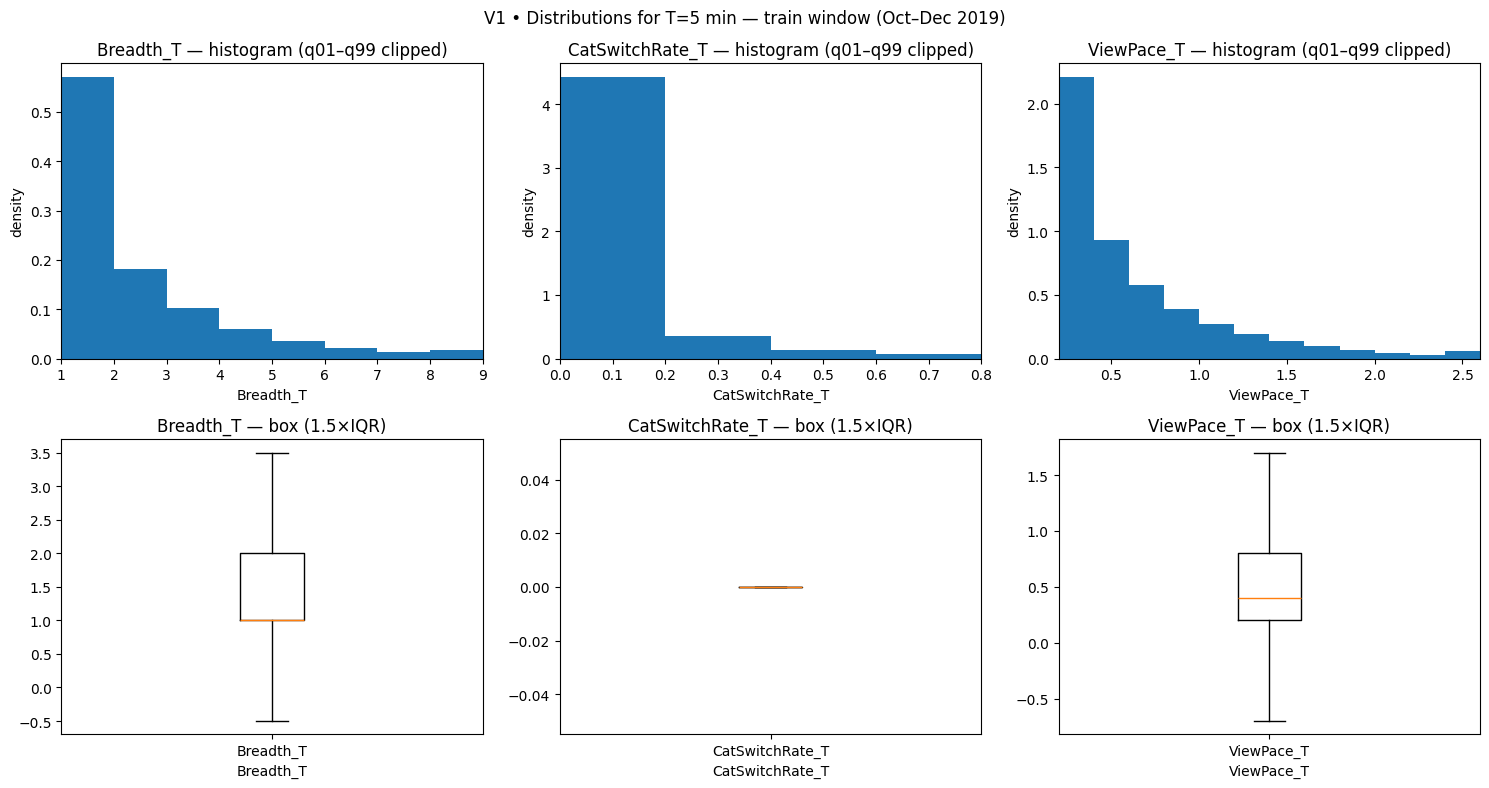

In [17]:
# =========================
# Cell 10.1 — V1 Distributions (train window Oct–Dec 2019, window-aware)
# =========================
from pathlib import Path
from datetime import datetime
import os, sys, gc
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# ---------- config import ----------
CONFIG_DIR = Path("/content/drive/MyDrive/CS539-F25-F02_WPI_ML_Colab/project")
if str(CONFIG_DIR) not in sys.path:
    sys.path.insert(0, str(CONFIG_DIR))
import config

# ---------- small logger ----------
if "nice_print" not in globals():
    from pprint import pformat

    def nice_print(ts, msg, obj=None):
        """
        Minimal logging helper used when a global `nice_print` is not defined.

        Parameters
        ----------
        ts : datetime | Any
            Timestamp or label to prefix the log line.
        msg : str
            Message text.
        obj : Any, optional
            Object to pretty-print under the message.
        """
        ts = ts.isoformat(timespec="seconds") if hasattr(ts, "isoformat") else str(ts)
        print(f"[{ts}] {msg}")
        if obj is not None:
            print(pformat(obj, width=100, compact=True))


T   = int(getattr(config, "T_MIN", 5))
OUT = config.OUT_DIR

# ---------- helpers for month labels ----------
_MON = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
}


def yyyymm(tag: str) -> str:
    """
    Convert a month tag in 'YYYY-Mon' format to 'YYYY-MM'.

    Examples
    --------
    "2019-Oct" → "2019-10"

    Parameters
    ----------
    tag : str
        Month tag such as "2019-Oct".

    Returns
    -------
    str
        Normalized label such as "2019-10".
    """
    y, mon = tag.split("-")
    return f"{y}-{_MON[mon]}"


TRAIN_MONTH_TAGS = ("2019-Oct", "2019-Nov", "2019-Dec")
TRAIN_MONTHS = [yyyymm(m) for m in TRAIN_MONTH_TAGS]
WINDOW_LABEL = "train window (Oct–Dec 2019)"


def _combined_candidates_oct_dec(T: int) -> list[Path]:
    """
    Candidate combined feature files for the Oct–Dec 2019 train window.

    Preference order (most specific → most generic), all for the Oct–Dec span:

    * LEAKFREE_ENRICHED_COMBINED_TARGETS
    * LEAKFREE_ENRICHED_COMBINED
    * LEAKFREE_COMBINED_TARGETS
    * LEAKFREE_COMBINED

    Parameters
    ----------
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate combined paths that may exist in OUT.
    """
    pats = [
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED.parquet",
    ]
    return [OUT / p for p in pats]


def _per_month_candidates(month_tag: str, T: int) -> list[Path]:
    """
    Candidate per-month feature files for a given month in the train window.

    Preference order
    ----------------
    1. *_LEAKFREE_ENRICHED_TARGETS.parquet
    2. *_LEAKFREE_ENRICHED.parquet
    3. *_LEAKFREE_TARGETS.parquet
    4. *_LEAKFREE.parquet
    5. *_SESSIONIZED.parquet

    Parameters
    ----------
    month_tag : str
        Month tag, e.g. "2019-Oct".
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate paths (not filtered for existence).
    """
    return [
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_ENRICHED_TARGETS.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_ENRICHED.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_TARGETS.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE.parquet",
        OUT / f"session_features_{month_tag}_T{T}_SESSIONIZED.parquet",
    ]


def choose_sources_train_oct_dec() -> tuple[list[Path], list[str], str]:
    """
    Choose feature sources for the Oct–Dec 2019 “train window” visualizations.

    Strategy
    --------
    1. Prefer a dedicated combined Oct–Dec file:
       * use :func:`_combined_candidates_oct_dec` to locate candidates,
         and pick the newest.
    2. If no combined file, fall back to per-month files for Oct, Nov, Dec:
       * any flavor of LEAKFREE/ENRICHED/TARGETS/SESSIONIZED, per month.
       * accept partial coverage (better to show *something* than fail).
    3. As a last resort, pick the newest generic combined file (even if it
       spans a larger window) and filter it to Oct–Dec.

    Returns
    -------
    (paths, month_filter_labels, window_used) : (list[Path], list[str], str)
        * paths               – Parquet files to read from.
        * month_filter_labels – list of 'YYYY-MM' strings for Oct–Dec.
        * window_used         – label describing which window is actually used.

    Raises
    ------
    FileNotFoundError
        If no suitable leak-free session feature files can be found.
    """
    # 1) Prefer any combined Oct–Dec file (best)
    combined_hits = [p for p in _combined_candidates_oct_dec(T) if p.exists()]
    if combined_hits:
        # choose the newest among the matched variants
        p = sorted(combined_hits, key=lambda x: x.stat().st_mtime, reverse=True)[0]
        return [p], TRAIN_MONTHS, WINDOW_LABEL

    # 2) Fall back to per-month files for Oct, Nov, Dec (second best)
    per: list[Path] = []
    for m in TRAIN_MONTH_TAGS:
        found = next((pp for pp in _per_month_candidates(m, T) if pp.exists()), None)
        if found:
            per.append(found)
    if len(per) >= 1:  # accept partial if you’re still building; better to show something than fail
        return per, TRAIN_MONTHS, WINDOW_LABEL

    # 3) Last resort: newest combined (warn) — we will filter to Oct–Dec if possible
    hits = sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    ) or sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    )
    if hits:
        return [hits[0]], TRAIN_MONTHS, WINDOW_LABEL + f" [filtered from {hits[0].name}]"

    raise FileNotFoundError("No suitable leak-free session feature files found for V1 (Oct–Dec train).")


paths, month_filter_labels, window_used = choose_sources_train_oct_dec()
nice_print(
    datetime.now(),
    "V1 will read Parquet file(s):",
    obj={"paths": [str(p) for p in paths], "window": window_used, "filter_months": month_filter_labels},
)

# ---------- LazyFrame with only needed columns (and optional month filter) ----------
VARS = ["Breadth_T", "CatSwitchRate_T", "ViewPace_T"]
lf_all = pl.scan_parquet([str(p) for p in paths])
cols_available = lf_all.collect_schema().names()

# If the source includes multiple months, filter to Oct–Dec 2019
if month_filter_labels and "session_month" in cols_available:
    lf_all = lf_all.filter(pl.col("session_month").is_in(month_filter_labels))

# Minimal presence check
vars_present = [c for c in VARS if c in cols_available]
missing = [c for c in VARS if c not in vars_present]
if missing:
    raise KeyError(f"Missing expected columns in features: {missing}")
lf = lf_all.select(vars_present)


# ---------- helpers ----------
def robust_range(lf: pl.LazyFrame, col: str, lo_q: float = 0.01, hi_q: float = 0.99) -> tuple[float, float]:
    """
    Compute a robust [lo, hi] range for a numeric column via quantiles.

    This uses `lo_q`/`hi_q` quantiles, and falls back to [min, max] if
    the quantiles are degenerate (non-finite or hi <= lo).

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame containing the column.
    col : str
        Column name.
    lo_q : float, default 0.01
        Lower quantile (0–1).
    hi_q : float, default 0.99
        Upper quantile (0–1).

    Returns
    -------
    (lo, hi) : tuple[float, float]
        Robust lower and upper bounds.
    """
    q = (
        lf.select(
            pl.col(col).quantile(lo_q).alias("lo"),
            pl.col(col).quantile(hi_q).alias("hi"),
        )
        .collect()
        .to_dicts()[0]
    )
    lo, hi = float(q["lo"]), float(q["hi"])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        m = lf.select(pl.min(col).alias("lo"), pl.max(col).alias("hi")).collect().to_dicts()[0]
        lo, hi = float(m["lo"]), float(m["hi"])
        if hi <= lo:
            hi = lo + 1.0
    return lo, hi


def binning_policy(col: str, lo: float, hi: float, T: int) -> np.ndarray:
    """
    Compute histogram edges for a column, respecting semantics of breadth vs. rate.

    * For ``Breadth_T``: use integer-spaced edges.
    * For rate-like features (ViewPace_T, CatSwitchRate_T, EventsPerMin):
      use a grid aligned to `step = 1/T`, expanded to cover [lo, hi].

    Parameters
    ----------
    col : str
        Column name.
    lo : float
        Lower bound of the range.
    hi : float
        Upper bound of the range.
    T : int
        Session window length in minutes.

    Returns
    -------
    numpy.ndarray
        Array of bin edges (monotonic).
    """
    if col == "Breadth_T":
        lo_i = np.floor(lo)
        hi_i = np.ceil(hi)
        return np.arange(lo_i, hi_i + 1, 1.0)
    step = 1.0 / float(T)
    start = np.floor(lo / step) * step
    stop  = np.ceil(hi / step) * step
    if stop <= start:
        stop = start + step
    return np.arange(start, stop + step * 0.5, step)


def hist_counts_edges(lf: pl.LazyFrame, col: str, *, edges: np.ndarray) -> tuple[np.ndarray, np.ndarray, float, float]:
    """
    Compute histogram counts lazily in Polars for a given column and bin edges.

    Returns the counts, the edges, the total row count, and the bin width,
    ready to be used with Matplotlib's `ax.stairs`.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame containing the column.
    col : str
        Column to histogram.
    edges : numpy.ndarray, keyword-only
        Bin edges for the histogram.

    Returns
    -------
    (counts, edges, n, width) : tuple
        * counts : np.ndarray
            Count per bin.
        * edges  : np.ndarray
            Same edges array.
        * n      : float
            Total number of non-null rows considered.
        * width  : float
            Approximate bin width (edges[1] - edges[0]).
    """
    lo, hi = float(edges[0]), float(edges[-1])
    bins = len(edges) - 1
    span = hi - lo
    width = edges[1] - edges[0]
    tiny = 1e-12

    # Map values into [0, bins-1] bin indices.
    bin_idx = (
        ((pl.col(col).clip(lo, hi - tiny) - lo) / span * bins)
        .floor()
        .clip(0, bins - 1)
        .cast(pl.Int32)
    )
    df_counts = (
        lf.select(pl.col(col))
          .filter(pl.col(col).is_not_null())
          .with_columns(bin_idx=bin_idx)
          .group_by("bin_idx")
          .agg(pl.len().alias("count"))
          .collect()
    )
    counts = np.zeros(bins, dtype=np.float64)
    if df_counts.height:
        for idx, cnt in df_counts.iter_rows():
            counts[int(idx)] = float(cnt)
    n = float(lf.select(pl.len()).collect()["len"][0])
    return counts, edges, n, width


# ---------- compute + plot ----------
fig, axes = plt.subplots(2, len(vars_present), figsize=(5 * len(vars_present), 8))

for i, col in enumerate(vars_present):
    # HIST (q01–q99 clipped; density on y)
    lo, hi = robust_range(lf, col, 0.01, 0.99)
    edges = binning_policy(col, lo, hi, T)
    counts, edges, n, width = hist_counts_edges(lf, col, edges=edges)

    counts = counts / (n * width if n > 0 else 1.0)
    ax_h = axes[0, i] if len(vars_present) > 1 else axes[0]
    ax_h.stairs(counts, edges, fill=True, linewidth=0)
    ax_h.set_xlim(edges[0], edges[-1])
    ax_h.set_title(f"{col} — histogram (q01–q99 clipped)")
    ax_h.set_xlabel(col)
    ax_h.set_ylabel("density")

    # BOX — standard 1.5×IQR
    s = (
        lf.select(
            pl.col(col).quantile(0.25).alias("q1"),
            pl.col(col).quantile(0.50).alias("med"),
            pl.col(col).quantile(0.75).alias("q3"),
        )
        .collect()
        .to_dicts()[0]
    )
    q1, med, q3 = float(s["q1"]), float(s["med"]), float(s["q3"])
    iqr = q3 - q1
    stats = {
        "label": col,
        "med": med,
        "q1": q1,
        "q3": q3,
        "whislo": q1 - 1.5 * iqr,
        "whishi": q3 + 1.5 * iqr,
        "fliers": [],
    }
    ax_b = axes[1, i] if len(vars_present) > 1 else axes[1]
    ax_b.bxp([stats], showfliers=False)
    ax_b.set_title(f"{col} — box (1.5×IQR)")
    ax_b.set_xlabel(col)

fig.suptitle(f"V1 • Distributions for T={T} min — {window_used}")
plt.tight_layout()

# ---- NEW: save figure to OUT_DIR before showing ----
fig_path = OUT / f"m2_vis_V1_distributions_T{T}_train.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
nice_print(datetime.now(), "V1 figure saved", obj={"path": str(fig_path)})

plt.show()


#### V1 — Distributions of Early‑Session Features (T = 5 min, train window Oct–Dec 2019)

Summary of patterns

The distributions of Breadth_T, CatSwitchRate_T, and ViewPace_T are all right‑skewed, indicating most sessions begin with brief, focused activity. A small slice of high‑activity sessions stretches the upper tail (plots clipped to q01–q99).

Breadth_T — distinct products viewed
Most sessions view 1–3 unique products in the first five minutes. The display clips at q99 ≈ 9, so extreme breadth values (rare) are off‑plot.
Implication: plausible non‑linearity (moderate exploration may be best), to be tested in V2.

CatSwitchRate_T — category transitions per minute
Mass is concentrated near 0, with a thin tail up to ~0.3–0.8 in rare cases. Most shoppers stay within a single top‑level category early on.
Implication: switching is uncommon and unlikely to drive global conversion by itself.

ViewPace_T — views per minute
Also right‑skewed. The median is sub‑1 view/min, and q99 ≈ 2–3 views/min (in these leak‑free, clipped plots).
Implication: pace still captures engagement intensity; faster early interaction tends to coincide with broader exploration.

Interpretation

Overall, early behavior is dominated by short, low‑intensity sessions. Engagement (tempo/pace) is the more informative signal; breadth and switching add at most secondary nuance.
For modeling, apply log1p + standardization to skewed rate/count features (ViewPace_T, EventsPerMin, Breadth_T, CatSwitchRate_T), and test non‑linear breadth effects conditional on engagement.

Note on axes
The x‑axis shows feature values; the y‑axis is density (areas sum to 1), enabling comparisons across variables with different scales. Figures are q01–q99 clipped, so extreme tails are intentionally suppressed in the display.

**V2 (Professor’s note)**: Purchase rate vs **Breadth_T** (deciles or spline) to test the **inverted‑U** hypothesis.

[2025-12-17T21:14:15] V2 will read Parquet file(s):
{'exclude_zero': False,
 'filter_months': ['2019-10', '2019-11', '2019-12'],
 'paths': ['../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'],
 'window': 'train window (Oct–Dec 2019)'}
[2025-12-17T21:14:15] V2 figure saved
{'path': '../cache_data/m2_vis_V2_breadth_curve_T5_train.png'}


/var/folders/sq/y62h0qk17yn1y5z20t900rsc0000gn/T/ipykernel_40096/1003018968.py:313: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


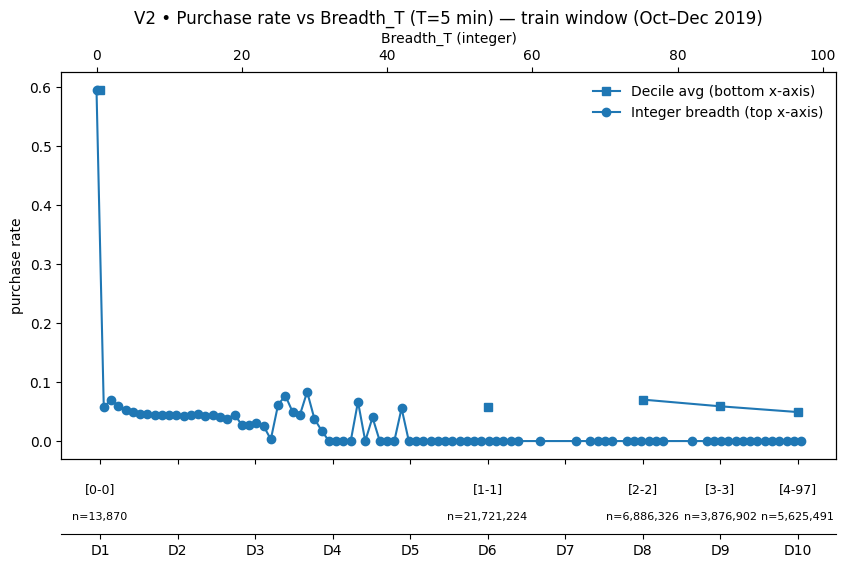

[2025-12-17T21:14:15] Why these files?
{'chosen': ['../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet',
            '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet',
            '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'],
 'exclude_zero_breadth': False,
 'filter_months': ['2019-10', '2019-11', '2019-12'],
 'reason': 'Leak-free session feature caches (ENRICHED/_TARGETS) contain Breadth_T and '
           'PurchaseInSession at the session grain. We lock to the TRAIN window (Oct–Dec 2019) to '
           'avoid look-ahead and stabilize design choices.',
 'window': 'train window (Oct–Dec 2019)'}


In [18]:
# =========================
# Cell 10.2 — V2 Purchase rate vs Breadth_T (deciles + integer trend)
# Train window locked to Oct–Dec 2019 (window-aware, filtered if needed)
# =========================
from pathlib import Path
from datetime import datetime
import sys, numpy as np
import polars as pl
import matplotlib.pyplot as plt

# ---- config ----
CONFIG_DIR = Path("/content/drive/MyDrive/CS539-F25-F02_WPI_ML_Colab/project")
if str(CONFIG_DIR) not in sys.path:
    sys.path.insert(0, str(CONFIG_DIR))
import config

if "nice_print" not in globals():
    from pprint import pformat

    def nice_print(ts, msg, obj=None):
        """
        Minimal logger used when a global `nice_print` is not defined.

        Parameters
        ----------
        ts : datetime | Any
            Timestamp or label to prefix the message.
        msg : str
            Message text.
        obj : Any, optional
            Extra object to pretty-print under the message.
        """
        ts = ts.isoformat(timespec="seconds") if hasattr(ts, "isoformat") else str(ts)
        print(f"[{ts}] {msg}")
        if obj is not None:
            print(pformat(obj, width=100, compact=True))


T   = int(getattr(config, "T_MIN", 5))
OUT = config.OUT_DIR

# ---- optional: exclude non-browsing cohort (Breadth=0) for a V2b plot
EXCLUDE_ZERO_BREADTH = bool(getattr(config, "EXCLUDE_ZERO_BREADTH", False))

# ---- helpers for month tags ----
_MON = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
}


def yyyymm(tag: str) -> str:
    """
    Convert a month tag from 'YYYY-Mon' to 'YYYY-MM'.

    Examples
    --------
    "2019-Oct" → "2019-10"

    Parameters
    ----------
    tag : str
        Month tag (e.g., "2019-Oct").

    Returns
    -------
    str
        Normalized label (e.g., "2019-10").
    """
    y, mon = tag.split("-")
    return f"{y}-{_MON[mon]}"


TRAIN_MONTH_TAGS = ("2019-Oct", "2019-Nov", "2019-Dec")
TRAIN_MONTHS = [yyyymm(m) for m in TRAIN_MONTH_TAGS]
WINDOW_LABEL = "train window (Oct–Dec 2019)"


def _combined_candidates_oct_dec(T: int) -> list[Path]:
    """
    Candidate combined feature files for the Oct–Dec 2019 train window.

    Preference order
    ----------------
    1. *_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet
    2. *_LEAKFREE_ENRICHED_COMBINED.parquet
    3. *_LEAKFREE_COMBINED_TARGETS.parquet
    4. *_LEAKFREE_COMBINED.parquet

    All paths are specific to 2019-Oct_to_2019-Dec.

    Parameters
    ----------
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate combined file paths (not filtered for existence).
    """
    pats = [
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED.parquet",
    ]
    return [OUT / p for p in pats]


def _per_month_candidates(month_tag: str, T: int) -> list[Path]:
    """
    Candidate per-month feature files for a given train month.

    Preference order
    ----------------
    1. *_LEAKFREE_ENRICHED_TARGETS.parquet
    2. *_LEAKFREE_ENRICHED.parquet
    3. *_LEAKFREE_TARGETS.parquet
    4. *_LEAKFREE.parquet
    5. *_SESSIONIZED.parquet

    Parameters
    ----------
    month_tag : str
        Month tag (e.g. "2019-Oct").
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate paths (not filtered for existence).
    """
    return [
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_ENRICHED_TARGETS.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_ENRICHED.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_TARGETS.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE.parquet",
        OUT / f"session_features_{month_tag}_T{T}_SESSIONIZED.parquet",
    ]


def choose_sources_train_oct_dec() -> tuple[list[Path], list[str], str]:
    """
    Choose feature sources for plotting Breadth_T → purchase in the train window.

    Strategy
    --------
    1. Prefer a dedicated combined Oct–Dec 2019 file:
       * use :func:`_combined_candidates_oct_dec`, pick the newest that exists.
    2. If no dedicated combined file, fall back to per-month files for
       Oct, Nov, Dec:
       * accept partial coverage (still useful for quick visuals).
    3. As a last resort, pick the newest generic combined LEAKFREE file
       and filter to Oct–Dec months, annotating the window label as such.

    Returns
    -------
    paths : list[pathlib.Path]
        Feature files to read from.
    month_filter_labels : list[str]
        Month labels in 'YYYY-MM' format for the train window.
    window_used : str
        Human-readable description of the window used in plots.

    Raises
    ------
    FileNotFoundError
        If no suitable feature sources are found in OUT_DIR.
    """
    # 1) Prefer any combined Oct–Dec file (best)
    combined_hits = [p for p in _combined_candidates_oct_dec(T) if p.exists()]
    if combined_hits:
        p = sorted(combined_hits, key=lambda x: x.stat().st_mtime, reverse=True)[0]
        return [p], TRAIN_MONTHS, WINDOW_LABEL

    # 2) Fall back to per-month files for Oct, Nov, Dec (second best; accepts partial)
    per: list[Path] = []
    for m in TRAIN_MONTH_TAGS:
        found = next((pp for pp in _per_month_candidates(m, T) if pp.exists()), None)
        if found:
            per.append(found)
    if len(per) >= 1:
        return per, TRAIN_MONTHS, WINDOW_LABEL

    # 3) Last resort: newest combined — will filter to Oct–Dec if possible
    hits = sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    ) or sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    )
    if hits:
        return [hits[0]], TRAIN_MONTHS, WINDOW_LABEL + f" [filtered from {hits[0].name}]"

    raise FileNotFoundError("No suitable leak-free session feature files found in OUT_DIR.")


paths, month_filter_labels, window_used = choose_sources_train_oct_dec()
nice_print(
    datetime.now(),
    "V2 will read Parquet file(s):",
    obj={
        "paths": [str(p) for p in paths],
        "window": window_used,
        "filter_months": month_filter_labels,
        "exclude_zero": EXCLUDE_ZERO_BREADTH,
    },
)

# ---- minimal LazyFrame (only what we need), with optional month filter & zero-breadth filter ----
NEEDED = ["Breadth_T", "PurchaseInSession"]
lf_all = pl.scan_parquet([str(p) for p in paths])
have = lf_all.collect_schema().names()
missing = [c for c in NEEDED if c not in have]
if missing:
    raise KeyError(f"Expected columns not found in features: {missing}")

# If the source includes multiple months, filter to Oct–Dec 2019 (requires session_month)
if month_filter_labels and "session_month" in have:
    lf_all = lf_all.filter(pl.col("session_month").is_in(month_filter_labels))

lf = lf_all.select(
    b = pl.col("Breadth_T").cast(pl.Int64),
    y = pl.col("PurchaseInSession").cast(pl.Int8),
)
if EXCLUDE_ZERO_BREADTH:
    lf = lf.filter(pl.col("b") >= 1)

# ---- aggregate by integer Breadth (tiny) ----
agg_int = (
    lf.group_by("b")
      .agg(
          n      = pl.len(),
          buyers = pl.col("y").sum(),
          rate   = pl.col("y").mean(),
      )
      .sort("b")
      .collect()
)
if agg_int.is_empty():
    raise RuntimeError("No data after filtering. Check selected sources / filters.")

b_vals  = agg_int["b"].to_numpy()
rates_i = agg_int["rate"].to_numpy()
n_i     = agg_int["n"].to_numpy()

# ---- deciles by session mass (weighted, over integer-b breadth bins) ----
total = float(n_i.sum())
cdf   = np.cumsum(n_i) / (total if total > 0 else 1.0)
dec_idx = np.minimum(9, np.floor(cdf * 10).astype(int))  # 0..9 → D1..D10

dec_rates, dec_counts, dec_lo, dec_hi = [], [], [], []
for d in range(10):
    mask = dec_idx == d
    if mask.any():
        n_d = n_i[mask].sum()
        buyers_d = (rates_i[mask] * n_i[mask]).sum()
        dec_rates.append(float(buyers_d / n_d) if n_d > 0 else np.nan)
        dec_counts.append(int(n_d))
        dec_lo.append(int(b_vals[mask].min()))
        dec_hi.append(int(b_vals[mask].max()))
    else:
        dec_rates.append(np.nan)
        dec_counts.append(0)
        dec_lo.append(None)
        dec_hi.append(None)

x_dec = np.arange(1, 11)

# ---- layout: main plot + slim annotation axis below; top twin x-axis for integer breadth ----
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 1], hspace=0.05)

ax_dec  = fig.add_subplot(gs[0])               # main (bottom x-scale = deciles)
ax_info = fig.add_subplot(gs[1], sharex=ax_dec)  # slim annotation strip
ax_int  = ax_dec.twiny()                       # top x-scale = integer breadth

# --- main: decile curve
label_suffix = " (Breadth ≥ 1)" if EXCLUDE_ZERO_BREADTH else ""
ax_dec.plot(x_dec, dec_rates, marker="s", linestyle="-", label="Decile avg (bottom x-axis)")
ax_dec.set_xlim(0.5, 10.5)
ax_dec.set_ylabel("purchase rate")
ax_dec.set_title(f"V2 • Purchase rate vs Breadth_T (T={T} min){label_suffix} — {window_used}")

# --- top axis: integer-level trend
ax_int.plot(b_vals, rates_i, color="C0", marker="o", linestyle="-", label="Integer breadth (top x-axis)")
ax_int.set_xlabel("Breadth_T (integer)")
ax_dec.set_xlabel("")

# --- legend (combine handles from both axes)
h1, l1 = ax_dec.get_legend_handles_labels()
h2, l2 = ax_int.get_legend_handles_labels()
ax_dec.legend(h1 + h2, l1 + l2, loc="upper right", frameon=False)

# --- annotation strip: show D1..D10 and each decile's [lo-hi] + n
ax_info.set_ylim(0, 1)
ax_info.set_xlim(0.5, 10.5)
ax_info.set_yticks([])
ax_info.spines[["top", "left", "right"]].set_visible(False)
ax_dec.tick_params(axis="x", which="both", labelbottom=False)
ax_info.set_xticks(x_dec)
ax_info.set_xticklabels([f"D{i}" for i in x_dec])

for xi, lo_b, hi_b, cnt in zip(x_dec, dec_lo, dec_hi, dec_counts):
    if lo_b is None:
        continue
    ax_info.text(xi, 0.70, f"[{lo_b}-{hi_b}]", ha="center", va="center", fontsize=9)
    ax_info.text(xi, 0.28, f"n={cnt:,}",     ha="center", va="center", fontsize=8)

plt.tight_layout()

# Save V2 figure for M2
fig_path = OUT / f"m2_vis_V2_breadth_curve_T{T}_train.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
nice_print(datetime.now(), "V2 figure saved", obj={"path": str(fig_path)})

plt.show()

nice_print(
    datetime.now(),
    "Why these files?",
    obj={
        "chosen": [str(p) for p in paths],
        "window": window_used,
        "filter_months": month_filter_labels,
        "exclude_zero_breadth": EXCLUDE_ZERO_BREADTH,
        "reason": (
            "Leak-free session feature caches (ENRICHED/_TARGETS) contain Breadth_T and PurchaseInSession at the "
            "session grain. We lock to the TRAIN window (Oct–Dec 2019) to avoid look-ahead and stabilize design choices."
        ),
    },
)


🔹 V2 — Purchase Rate vs Breadth_T (T = 5 min, train window)

Purpose
Probe the inverted‑U idea: does purchase probability first rise with early exploration breadth, then fall when shoppers browse too widely?

What the plot actually says

Breadth = 0 converts very high (~0.6) but is tiny in volume: n=15,887 ≈ 0.04% of sessions. This looks like resume‑checkout / direct‑to‑cart / instrumentation gaps—not normal browsing. Treat separately.

For Breadth ≥ 1, there’s no strong inverted‑U.

Breadth = 1 (the bulk of traffic) sits around ~5–6% purchase rate.

Breadth = 2–3 shows a small bump (roughly ~7–8%).

Breadth ≥ 4 trends downward toward low single digits; many integer bins beyond that are near zero.

Distribution is extremely skewed (per the brackets under the deciles):

[1] = 21,935,717 (~56.9%)

[2] = 6,987,270 (~18.1%)

[3] = 3,937,788 (~10.2%)

[4–97] = 5,715,595 (~14.8%)

[0] = 15,887 (~0.04%)
So ~85% of sessions have Breadth 1–3.

The jagged dots at higher integers are thin bins; don’t over‑read the spikes (e.g., the lone uptick around ~6).

Interpretation (Oct–Dec 2019)

The tidy “choice‑overload” inverted‑U isn’t there. At best, there’s a modest hump at 2–3, followed by a monotonic-ish decline as breadth widens.

Breadth = 0 is a distinct cohort with outlier conversion and negligible share—model with its own flag, not on the browsing curve.

Given how massed Breadth = 1 is (it occupies multiple deciles), decile smoothing hides detail; rely on the integer view or a smooth with monotonicity after ~3.

**V3 (Professor’s note)**: Stratified curves/cohorts—purchase rate vs **Breadth_T** by day‑part or by **CatSwitchRate_T** terciles (confounding check).

[2025-12-17T21:14:15] V3 will read Parquet file(s):
{'exclude_zero_breadth': False,
 'filter_months': ['2019-10', '2019-11', '2019-12'],
 'paths': ['../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'],
 'window': 'train window (Oct–Dec 2019)'}
[2025-12-17T21:14:16] V3 figure saved
{'path': '../cache_data/m2_vis_V3_stratified_breadth_T5_train.png'}


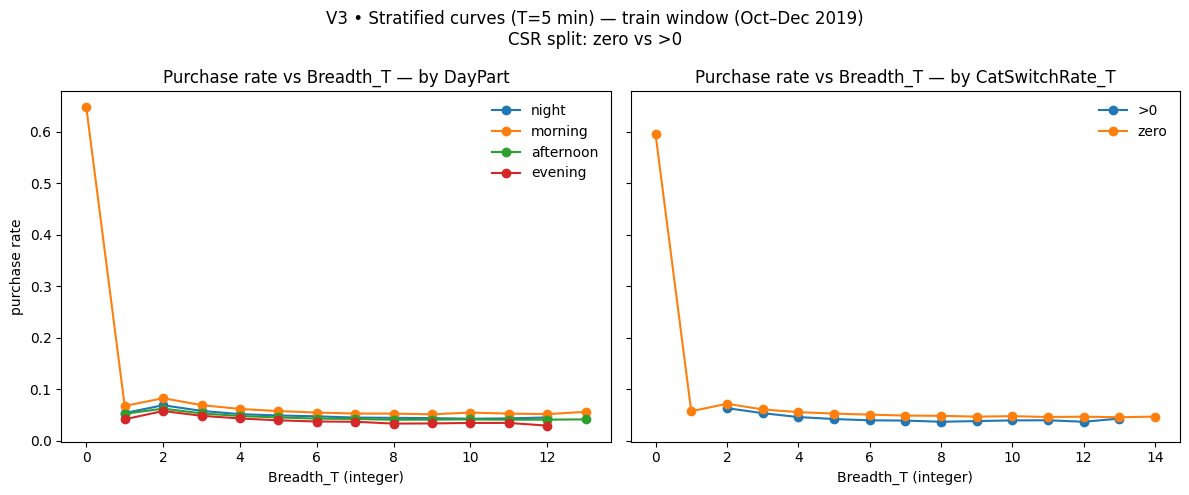

[2025-12-17T21:14:16] Why these files?
{'chosen': ['../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet',
            '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet',
            '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'],
 'csr_mode': 'binary_zero_vs_pos',
 'exclude_zero_breadth': False,
 'filter_months': ['2019-10', '2019-11', '2019-12'],
 'min_n_per_point': 5000,
 'reason': 'Leak-free session feature caches include Breadth_T, CatSwitchRate_T, DayPart (or '
           'session_start), and PurchaseInSession at the session level. We restrict to Oct–Dec '
           '2019 to avoid look-ahead and compute stratified purchase curves without event joins.',
 'tercile_cutpoints': {'q1': 0.0, 'q2': 0.0},
 'window': 'train window (Oct–Dec 2019)'}


In [19]:
# =========================
# Cell 10.3 — V3 Stratified purchase rate vs Breadth_T
# (by DayPart and by CatSwitchRate_T terciles)
# Train window locked to Oct–Dec 2019 (window-aware, filtered if needed)
# =========================
from pathlib import Path
from datetime import datetime
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# ---------- config ----------
import config


T   = int(getattr(config, "T_MIN", 5))
OUT = config.OUT_DIR

# Optional: drop the non-browsing cohort from these curves
EXCLUDE_ZERO_BREADTH = bool(getattr(config, "EXCLUDE_ZERO_BREADTH", False))

# ---------- helpers for train window ----------
_MON = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
}


def yyyymm(tag: str) -> str:
    """
    Convert month tag from 'YYYY-Mon' to 'YYYY-MM' for filtering.

    Examples
    --------
    "2019-Oct" → "2019-10"

    Parameters
    ----------
    tag : str
        Month tag such as "2019-Oct".

    Returns
    -------
    str
        Normalized "YYYY-MM" label.
    """
    y, mon = tag.split("-")
    return f"{y}-{_MON[mon]}"


TRAIN_MONTH_TAGS = ("2019-Oct", "2019-Nov", "2019-Dec")
TRAIN_MONTHS = [yyyymm(m) for m in TRAIN_MONTH_TAGS]
WINDOW_LABEL = "train window (Oct–Dec 2019)"


def _combined_candidates_oct_dec(T: int) -> list[Path]:
    """
    Candidate combined feature files for the Oct–Dec 2019 train window.

    Preference (most specific → generic), all for the Oct–Dec span:

    * *_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet
    * *_LEAKFREE_ENRICHED_COMBINED.parquet
    * *_LEAKFREE_COMBINED_TARGETS.parquet
    * *_LEAKFREE_COMBINED.parquet

    Parameters
    ----------
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate combined paths (not filtered for existence).
    """
    pats = [
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED.parquet",
    ]
    return [OUT / p for p in pats]


def _per_month_candidates(month_tag: str, T: int) -> list[Path]:
    """
    Candidate per-month feature files for a given month.

    Preference order
    ----------------
    1. *_LEAKFREE_ENRICHED_TARGETS
    2. *_LEAKFREE_ENRICHED
    3. *_LEAKFREE_TARGETS
    4. *_LEAKFREE
    5. *_SESSIONIZED

    Parameters
    ----------
    month_tag : str
        Month tag (e.g. "2019-Oct").
    T : int
        Early-session window in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate paths for that month (not filtered for existence).
    """
    return [
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_ENRICHED_TARGETS.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_ENRICHED.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_TARGETS.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE.parquet",
        OUT / f"session_features_{month_tag}_T{T}_SESSIONIZED.parquet",
    ]


def choose_sources_train_oct_dec() -> tuple[list[Path], list[str], str]:
    """
    Choose feature sources for stratified Breadth_T plots in the train window.

    Strategy
    --------
    1. Prefer a dedicated combined Oct–Dec file:
       * locate via :func:`_combined_candidates_oct_dec`, pick the newest existing.
    2. If none, fall back to per-month files for Oct, Nov, Dec:
       * accept partial coverage to keep the viz usable during incremental builds.
    3. If still nothing, fall back to the newest generic combined LEAKFREE file,
       annotating the window as filtered from that file.

    Returns
    -------
    (paths, month_filter_labels, window_used) : (list[Path], list[str], str)
        * `paths`               – files to read.
        * `month_filter_labels` – 'YYYY-MM' labels for train months.
        * `window_used`         – label used in figure titles.

    Raises
    ------
    FileNotFoundError
        If no suitable feature sources exist in OUT_DIR.
    """
    combined_hits = [p for p in _combined_candidates_oct_dec(T) if p.exists()]
    if combined_hits:
        p = sorted(combined_hits, key=lambda x: x.stat().st_mtime, reverse=True)[0]
        return [p], TRAIN_MONTHS, WINDOW_LABEL

    per: list[Path] = []
    for m in TRAIN_MONTH_TAGS:
        found = next((pp for pp in _per_month_candidates(m, T) if pp.exists()), None)
        if found:
            per.append(found)
    if len(per) >= 1:
        return per, TRAIN_MONTHS, WINDOW_LABEL

    hits = sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    ) or sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    )
    if hits:
        return [hits[0]], TRAIN_MONTHS, WINDOW_LABEL + f" [filtered from {hits[0].name}]"

    raise FileNotFoundError("No suitable leak-free session feature files in OUT_DIR for V3 (Oct–Dec train).")


paths, month_filter_labels, window_used = choose_sources_train_oct_dec()
nice_print(
    datetime.now(),
    "V3 will read Parquet file(s):",
    obj={
        "paths": [str(p) for p in paths],
        "window": window_used,
        "filter_months": month_filter_labels,
        "exclude_zero_breadth": EXCLUDE_ZERO_BREADTH,
    },
)

# ---------- minimal LazyFrame (with month filtering if needed) ----------
lf_all = pl.scan_parquet([str(p) for p in paths])
cols = lf_all.collect_schema().names()

# Filter to Oct–Dec 2019
if month_filter_labels:
    if "session_month" in cols:
        lf_all = lf_all.filter(pl.col("session_month").is_in(month_filter_labels))
    elif "session_start" in cols:
        lf_all = lf_all.filter(pl.col("session_start").dt.strftime("%Y-%m").is_in(month_filter_labels))

# Re-probe columns after potential filter
cols = lf_all.collect_schema().names()
missing_core = [c for c in ("Breadth_T", "PurchaseInSession") if c not in cols]
if missing_core:
    raise KeyError(f"Missing required columns in features: {missing_core}")

# DayPart: use column if present; else derive; else "unknown"
if "DayPart" in cols:
    daypart_expr = pl.col("DayPart").cast(pl.Utf8).alias("daypart")
elif "session_start" in cols:
    daypart_expr = (
        pl.when(pl.col("session_start").dt.hour() < 6).then(pl.lit("night"))
         .when(pl.col("session_start").dt.hour() < 12).then(pl.lit("morning"))
         .when(pl.col("session_start").dt.hour() < 18).then(pl.lit("afternoon"))
         .otherwise(pl.lit("evening"))
         .alias("daypart")
    )
else:
    daypart_expr = pl.lit("unknown").alias("daypart")

has_csr = "CatSwitchRate_T" in cols

# Assemble working LF (use .alias() instead of keyword args)
lf = lf_all.select([
    pl.col("Breadth_T").cast(pl.Int64).alias("b"),
    pl.col("PurchaseInSession").cast(pl.Int8).alias("y"),
    (pl.col("CatSwitchRate_T").cast(pl.Float64) if has_csr else pl.lit(None).cast(pl.Float64)).alias("csr"),
    daypart_expr,
])
if EXCLUDE_ZERO_BREADTH:
    lf = lf.filter(pl.col("b") >= 1)

# ---------- aggregation helpers ----------
MIN_N_PER_POINT = 5_000  # trims noisy tails


def stratify_by_daypart(lf: pl.LazyFrame) -> pl.DataFrame:
    """
    Aggregate purchase rate vs breadth, stratified by DayPart.

    The function:
    * assigns a stable ordering to daypart values
      (night, morning, afternoon, evening, unknown) via `dp_ord`,
    * groups by (daypart, breadth) and computes:

      - n    – count of sessions
      - rate – mean(PurchaseInSession)

    * drops strata with fewer than MIN_N_PER_POINT sessions per breadth
      (to avoid noisy tails).

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame with columns:
        - "b" (Breadth_T),
        - "y" (PurchaseInSession),
        - "daypart".

    Returns
    -------
    polars.DataFrame
        DataFrame with columns ["daypart", "b", "n", "rate"] sorted by daypart order and breadth.
    """
    order = ["night", "morning", "afternoon", "evening", "unknown"]
    dp_ord = (
        pl.when(pl.col("daypart") == order[0]).then(0)
         .when(pl.col("daypart") == order[1]).then(1)
         .when(pl.col("daypart") == order[2]).then(2)
         .when(pl.col("daypart") == order[3]).then(3)
         .otherwise(4)
         .alias("dp_ord")
    )
    df = (
        lf.with_columns(dp_ord)
          .group_by(["dp_ord", "daypart", "b"])
          .agg(n=pl.len(), rate=pl.col("y").mean())
          .filter(pl.col("n") >= MIN_N_PER_POINT)
          .sort(["dp_ord", "b"])
          .drop("dp_ord")
          .collect()
    )
    return df


def stratify_by_csr_terciles(lf: pl.LazyFrame):
    """
    Aggregate purchase rate vs breadth, stratified by CatSwitchRate_T bands.

    If CatSwitchRate_T has usable variation, this produces terciles:
        * low ≤ q1
        * mid ≤ q2
        * high > q2

    If CatSwitchRate_T is too degenerate (e.g., many zeros), we fall back to:
        * "unknown" (null)
        * "zero" (csr <= 0)
        * ">0" (csr > 0)

    For each band and breadth, we compute:

    * n    – number of sessions
    * rate – mean(PurchaseInSession)

    and drop rows where n < MIN_N_PER_POINT.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame with columns:
        - "b" (Breadth_T),
        - "y" (PurchaseInSession),
        - "csr" (CatSwitchRate_T, may contain null).

    Returns
    -------
    (df, (q1, q2), mode, cut_label) : tuple
        * df        – polars.DataFrame with columns ['csr_band', 'b', 'n', 'rate'].
        * (q1, q2)  – numeric cutpoints used (may be degenerate).
        * mode      – "terciles" or "binary_zero_vs_pos".
        * cut_label – human-readable description of the splits.
    """
    if "csr" not in lf.collect_schema().names():
        raise KeyError("CatSwitchRate_T not present in features; cannot build terciles.")

    qrow = (
        lf.filter(pl.col("csr").is_not_null())
          .select(
              pl.col("csr").quantile(1 / 3).alias("q1"),
              pl.col("csr").quantile(2 / 3).alias("q2"),
          )
          .collect()
          .to_dicts()[0]
    )
    q1, q2 = float(qrow["q1"]), float(qrow["q2"])
    eps = 1e-12

    # Degenerate case: no stable terciles → fall back to zero vs >0 split.
    if not np.isfinite(q1) or not np.isfinite(q2) or (q2 <= eps) or (abs(q2 - q1) <= eps):
        strata = (
            pl.when(pl.col("csr").is_null()).then(pl.lit("unknown"))
             .when(pl.col("csr") <= 0.0).then(pl.lit("zero"))
             .otherwise(pl.lit(">0")).alias("csr_band")
        )
        mode = "binary_zero_vs_pos"
        df = (
            lf.select("b", "y", strata)
              .group_by(["csr_band", "b"])
              .agg(n=pl.len(), rate=pl.col("y").mean())
              .filter(pl.col("n") >= MIN_N_PER_POINT)
              .sort(["csr_band", "b"])
              .collect()
        )
        cut_label = "split: zero vs >0"
        return df, (q1, q2), mode, cut_label
    else:
        strata = (
            pl.when(pl.col("csr").is_null()).then(pl.lit("unknown"))
             .when(pl.col("csr") <= q1).then(pl.lit(f"low ≤{q1:.2f}"))
             .when(pl.col("csr") <= q2).then(pl.lit(f"mid ≤{q2:.2f}"))
             .otherwise(pl.lit("high")).alias("csr_band")
        )
        mode = "terciles"
        df = (
            lf.select("b", "y", strata)
              .group_by(["csr_band", "b"])
              .agg(n=pl.len(), rate=pl.col("y").mean())
              .filter(pl.col("n") >= MIN_N_PER_POINT)
              .sort(["csr_band", "b"])
              .collect()
        )
        cut_label = f"tercile cutpoints ≈ {q1:.2f}, {q2:.2f}"
        return df, (q1, q2), mode, cut_label


# ---------- compute tiny tables ----------
df_day = stratify_by_daypart(lf)
df_csr, (q1, q2), csr_mode, cut_label = stratify_by_csr_terciles(lf)

# ---------- plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Panel A — DayPart
ax = axes[0]
for gdf in df_day.partition_by("daypart", maintain_order=True):
    label = str(gdf["daypart"][0])
    b = gdf["b"].to_numpy()
    r = gdf["rate"].to_numpy()
    ax.plot(b, r, marker="o", linestyle="-", label=label)
ax.set_xlabel("Breadth_T (integer)")
ax.set_ylabel("purchase rate")
ax.set_title("Purchase rate vs Breadth_T — by DayPart")
ax.legend(loc="upper right", frameon=False)

# Panel B — CatSwitchRate_T bands
ax = axes[1]
for gdf in df_csr.partition_by("csr_band", maintain_order=True):
    label = str(gdf["csr_band"][0])
    b = gdf["b"].to_numpy()
    r = gdf["rate"].to_numpy()
    ax.plot(b, r, marker="o", linestyle="-", label=label)
ax.set_xlabel("Breadth_T (integer)")
ax.set_title("Purchase rate vs Breadth_T — by CatSwitchRate_T")
ax.legend(loc="upper right", frameon=False)

suffix = " (Breadth ≥ 1)" if EXCLUDE_ZERO_BREADTH else ""
fig.suptitle(f"V3 • Stratified curves (T={T} min){suffix} — {WINDOW_LABEL}\nCSR {cut_label}")
plt.tight_layout()

# Save V3 figure for M2
fig_path = OUT / f"m2_vis_V3_stratified_breadth_T{T}_train.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
nice_print(datetime.now(), "V3 figure saved", obj={"path": str(fig_path)})

plt.show()

# ---------- provenance ----------
nice_print(
    datetime.now(),
    "Why these files?",
    obj={
        "chosen": [str(p) for p in paths],
        "window": window_used,
        "filter_months": TRAIN_MONTHS,
        "exclude_zero_breadth": EXCLUDE_ZERO_BREADTH,
        "min_n_per_point": MIN_N_PER_POINT,
        "csr_mode": csr_mode,
        "tercile_cutpoints": {"q1": q1, "q2": q2},
        "reason": (
            "Leak-free session feature caches include Breadth_T, CatSwitchRate_T, DayPart (or session_start), "
            "and PurchaseInSession at the session level. We restrict to Oct–Dec 2019 to avoid look-ahead "
            "and compute stratified purchase curves without event joins."
        ),
    },
)


🔹 V3 — Stratified Curves: Purchase Rate vs Breadth_T (T = 5 min, train window, Oct–Dec 2019)

CSR split in the figure: zero vs >0 (binary), not terciles.

Purpose
Check whether the Breadth_T → purchase relationship changes across (a) DayPart and (b) early category switching (CatSwitchRate_T), and isolate the special case at Breadth = 0.

Observations

Breadth = 0 (non‑browsing cohort)

There is a very large spike at Breadth_T = 0, concentrated in the morning series in the DayPart panel.

In the CSR panel, that spike sits entirely in the CatSwitchRate_T = 0 group by construction.

Likely behaviors: resume‑checkout, saved‑cart, direct‑to‑cart/email/push—not exploratory browsing.

By DayPart (Breadth ≥ 1)

Curves are parallel in shape: a small bump around 2–3 items, then gradual decline and flattening.

Level ordering is consistent: morning highest, evening lowest, with night/afternoon in the middle. Differences are modest (≈ 1–3 pp absolute) and look like level shifts, not slope changes.

By CatSwitchRate_T (binary split: zero vs >0)

For Breadth ≥ 1, both lines follow the same flat/slowly declining pattern.

The no‑switch (zero) group is slightly higher than any‑switch (>0) across most breadth values (≈ 0.3–1.0 pp), and the gap narrows in the tail.

The dramatic point at Breadth = 0 belongs to the zero‑switch group only.

Interpretation

The shape of Breadth_T’s effect is stable across day‑parts and switching; these factors mainly shift the baseline conversion, not the curvature.

The standout anomaly is Breadth_T = 0 in the morning, consistent with non‑browsing, intent‑heavy traffic. This cohort should not be forced onto the browsing curve.

**V4**: Heatmap **Breadth_T × ViewPace_T** colored by purchase rate (interaction scan).

[2025-12-17T21:14:16] V4 will read Parquet file(s):
{'exclude_zero_breadth': False,
 'filter_months': ['2019-10', '2019-11', '2019-12'],
 'paths': ['../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'],
 'window': 'train window (Oct–Dec 2019)'}
[2025-12-17T21:14:17] V4 figure saved
{'path': '../cache_data/m2_vis_V4_heatmap_Breadth_ViewPace_T5_train.png'}


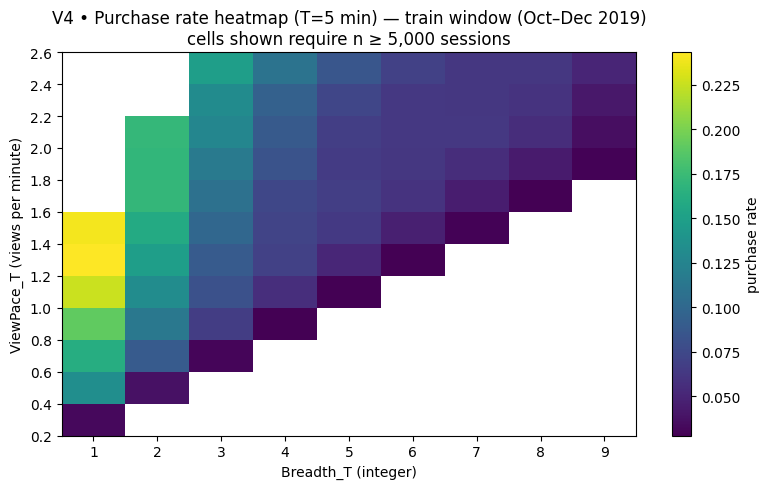

[2025-12-17T21:14:17] Why these files?
{'binning': {'breadth_range_int': [1, 9],
             'min_n_per_cell': 5000,
             'viewpace_edges_start_stop': [0.2, 2.6],
             'viewpace_step': 0.2},
 'chosen': ['../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet',
            '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet',
            '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'],
 'exclude_zero_breadth': False,
 'filter_months': ['2019-10', '2019-11', '2019-12'],
 'reason': 'Leak-free session feature caches at the session grain include Breadth_T, ViewPace_T '
           'and PurchaseInSession. We restrict to Oct–Dec 2019 (train) to avoid look-ahead. The '
           'heatmap uses q01–q99 clipped, grid-aligned bins (Breadth on integers; ViewPace on '
           'multiples of 1/T), and shows only cells with sufficient mass.',
 'window': 'train window (Oct–Dec 2019)'}


In [20]:
# =========================
# Cell 10.4 — V4 Heatmap: Breadth_T × ViewPace_T → purchase rate
# Train window locked to Oct–Dec 2019 (window-aware, filtered if needed)
# =========================
from pathlib import Path
from datetime import datetime
import sys, math
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# ---------- config ----------
import config

T   = int(getattr(config, "T_MIN", 5))
OUT = config.OUT_DIR

# Optional: drop the non-browsing cohort (Breadth=0) from the heatmap
EXCLUDE_ZERO_BREADTH = bool(getattr(config, "EXCLUDE_ZERO_BREADTH", False))

# ---------- helpers for train window ----------
_MON = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
}


def yyyymm(tag: str) -> str:
    """
    Convert a month tag from 'YYYY-Mon' to 'YYYY-MM' for filtering.

    Examples
    --------
    "2019-Oct" → "2019-10"

    Parameters
    ----------
    tag : str
        Month tag such as "2019-Oct".

    Returns
    -------
    str
        Normalized "YYYY-MM" label.
    """
    y, mon = tag.split("-")
    return f"{y}-{_MON[mon]}"


TRAIN_MONTH_TAGS = ("2019-Oct", "2019-Nov", "2019-Dec")
TRAIN_MONTHS = [yyyymm(m) for m in TRAIN_MONTH_TAGS]
WINDOW_LABEL = "train window (Oct–Dec 2019)"


def _combined_candidates_oct_dec(T: int) -> list[Path]:
    """
    Candidate combined feature files for the Oct–Dec 2019 train window.

    Preference (most specific → generic) is:

    * *_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet
    * *_LEAKFREE_ENRICHED_COMBINED.parquet
    * *_LEAKFREE_COMBINED_TARGETS.parquet
    * *_LEAKFREE_COMBINED.parquet

    All are specific to the '2019-Oct_to_2019-Dec' span.

    Parameters
    ----------
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate combined file paths (not filtered for existence).
    """
    pats = [
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED.parquet",
    ]
    return [OUT / p for p in pats]


def _per_month_candidates(month_tag: str, T: int) -> list[Path]:
    """
    Candidate per-month feature paths for a given month and T-window.

    Preference order
    ----------------
    1. *_LEAKFREE_ENRICHED_TARGETS
    2. *_LEAKFREE_ENRICHED
    3. *_LEAKFREE_TARGETS
    4. *_LEAKFREE
    5. *_SESSIONIZED

    Parameters
    ----------
    month_tag : str
        Month tag (e.g. "2019-Oct").
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate paths (not filtered for existence).
    """
    return [
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_ENRICHED_TARGETS.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_ENRICHED.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE_TARGETS.parquet",
        OUT / f"session_features_{month_tag}_T{T}_LEAKFREE.parquet",
        OUT / f"session_features_{month_tag}_T{T}_SESSIONIZED.parquet",
    ]


def choose_sources_train_oct_dec() -> tuple[list[Path], list[str], str]:
    """
    Choose feature sources for the Breadth_T × ViewPace_T heatmap in the train window.

    Strategy
    --------
    1. Prefer a dedicated combined Oct–Dec file (via :func:`_combined_candidates_oct_dec`).
    2. If none, fall back to per-month files for Oct, Nov, Dec (accept partial coverage).
    3. As a last resort, use the newest generic combined LEAKFREE file and
       annotate the window as filtered from that file.

    Returns
    -------
    (paths, month_filter_labels, window_used) : (list[Path], list[str], str)
        * `paths`               – feature files to read.
        * `month_filter_labels` – 'YYYY-MM' labels for Oct–Dec 2019.
        * `window_used`         – string label for the window used (for titles).

    Raises
    ------
    FileNotFoundError
        If no suitable feature sources are found in OUT_DIR.
    """
    # 1) Prefer any combined Oct–Dec file
    combined_hits = [p for p in _combined_candidates_oct_dec(T) if p.exists()]
    if combined_hits:
        p = sorted(combined_hits, key=lambda x: x.stat().st_mtime, reverse=True)[0]
        return [p], TRAIN_MONTHS, WINDOW_LABEL

    # 2) Fall back to per-month files (accept partial if still building caches)
    per: list[Path] = []
    for m in TRAIN_MONTH_TAGS:
        found = next((pp for pp in _per_month_candidates(m, T) if pp.exists()), None)
        if found:
            per.append(found)
    if len(per) >= 1:
        return per, TRAIN_MONTHS, WINDOW_LABEL

    # 3) Last resort: newest combined — we will filter to Oct–Dec if possible
    hits = sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    ) or sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    )
    if hits:
        return [hits[0]], TRAIN_MONTHS, WINDOW_LABEL + f" [filtered from {hits[0].name}]"

    raise FileNotFoundError("No suitable leak-free session feature files in OUT_DIR for V4 (Oct–Dec train).")


paths, month_filter_labels, window_used = choose_sources_train_oct_dec()
nice_print(
    datetime.now(),
    "V4 will read Parquet file(s):",
    obj={
        "paths": [str(p) for p in paths],
        "window": window_used,
        "filter_months": month_filter_labels,
        "exclude_zero_breadth": EXCLUDE_ZERO_BREADTH,
    },
)

# ---------- minimal LazyFrame (filter to Oct–Dec if needed) ----------
NEEDED = ["Breadth_T", "ViewPace_T", "PurchaseInSession", "session_month", "session_start"]
lf_all = pl.scan_parquet([str(p) for p in paths])
names = lf_all.collect_schema().names()

# Filter to Oct–Dec 2019 (by session_month if present; else by session_start)
if month_filter_labels:
    if "session_month" in names:
        lf_all = lf_all.filter(pl.col("session_month").is_in(month_filter_labels))
    elif "session_start" in names:
        lf_all = lf_all.filter(pl.col("session_start").dt.strftime("%Y-%m").is_in(month_filter_labels))

# Presence check for required features
for req in ["Breadth_T", "ViewPace_T", "PurchaseInSession"]:
    if req not in lf_all.collect_schema().names():
        raise KeyError(f"Missing expected column: {req}")

lf = lf_all.select(
    b  = pl.col("Breadth_T").cast(pl.Int64),
    vp = pl.col("ViewPace_T").cast(pl.Float64),
    y  = pl.col("PurchaseInSession").cast(pl.Int8),
)
if EXCLUDE_ZERO_BREADTH:
    lf = lf.filter(pl.col("b") >= 1)


# ---------- robust ranges + grid (q01–q99; grid-aligned to integers and 1/T) ----------
def robust_range(lf: pl.LazyFrame, col: str, lo_q: float = 0.01, hi_q: float = 0.99) -> tuple[float, float]:
    """
    Compute a robust [lo, hi] range for a numeric column using quantiles.

    If quantiles are degenerate (non-finite or hi <= lo), falls back to [min, max]
    with a small expansion if needed.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame containing the column.
    col : str
        Column name.
    lo_q : float, default 0.01
        Lower quantile (0–1).
    hi_q : float, default 0.99
        Upper quantile (0–1).

    Returns
    -------
    (lo, hi) : tuple[float, float]
        Robust lower and upper bounds for `col`.
    """
    q = (
        lf.select(
            pl.col(col).quantile(lo_q).alias("lo"),
            pl.col(col).quantile(hi_q).alias("hi"),
        )
        .collect()
        .to_dicts()[0]
    )
    lo, hi = float(q["lo"]), float(q["hi"])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        m = lf.select(pl.min(col).alias("lo"), pl.max(col).alias("hi")).collect().to_dicts()[0]
        lo, hi = float(m["lo"]), float(m["hi"])
        if hi <= lo:
            hi = lo + 1.0
    return lo, hi


# Breadth edges: integers centered at 0.5 so cells center on integer breadth
b_lo, b_hi = robust_range(lf, "b", 0.01, 0.99)
b_lo_i = int(max(0, math.floor(b_lo)))
b_hi_i = int(math.ceil(b_hi))
nx = max(1, b_hi_i - b_lo_i + 1)
x_edges = np.arange(b_lo_i - 0.5, b_hi_i + 0.5 + 1, 1.0)  # length nx+1

# ViewPace edges: multiples of 1/T; coarsen if too many bins
vp_lo, vp_hi = robust_range(lf, "vp", 0.01, 0.99)
step = 1.0 / float(T)
vp_start = math.floor(vp_lo / step) * step
vp_stop  = math.ceil(vp_hi / step) * step
ny_raw = int(round((vp_stop - vp_start) / step))
MAX_VP_BINS = 80
mult = max(1, int(math.ceil(ny_raw / MAX_VP_BINS)))
step_eff = step * mult
y_edges = np.arange(vp_start, vp_stop + step_eff * 0.5, step_eff)
ny = len(y_edges) - 1

# ---------- 2-D binning in Polars (lazy) ----------
tiny = 1e-12
b_idx = (pl.col("b").clip(b_lo_i, b_hi_i).cast(pl.Int64) - b_lo_i).cast(pl.Int32)
vp_idx = (
    ((pl.col("vp").clip(y_edges[0], y_edges[-1] - tiny) - y_edges[0]) / (y_edges[-1] - y_edges[0]) * ny)
    .floor()
    .clip(0, ny - 1)
    .cast(pl.Int32)
)

MIN_N_PER_CELL = 5_000  # suppress noisy cells; tweak if needed

agg = (
    lf.filter(pl.col("b").is_not_null() & pl.col("vp").is_not_null())
      .with_columns(bi=b_idx, vi=vp_idx)
      .group_by(["vi", "bi"])
      .agg(n=pl.len(), rate=pl.col("y").mean())
      .filter(pl.col("n") >= MIN_N_PER_CELL)
      .collect()
)

# ---------- pivot to grid (ny × nx) ----------
Z = np.full((ny, nx), np.nan, dtype=float)
if agg.height:
    for vi, bi, n, rate in agg.iter_rows():
        Z[int(vi), int(bi)] = float(rate)

# ---------- plot ----------
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
pcm = ax.pcolormesh(x_edges, y_edges, Z, shading="auto")
cb = fig.colorbar(pcm, ax=ax)
cb.set_label("purchase rate")

suffix = " (Breadth ≥ 1)" if EXCLUDE_ZERO_BREADTH else ""
ax.set_xlabel("Breadth_T (integer)")
ax.set_ylabel("ViewPace_T (views per minute)")
ax.set_title(
    f"V4 • Purchase rate heatmap (T={T} min){suffix} — {WINDOW_LABEL}\n"
    f"cells shown require n ≥ {MIN_N_PER_CELL:,} sessions"
)

# Helpful tick formatting (integers on x; grid-aligned y)
ax.set_xticks(np.arange(b_lo_i, b_hi_i + 1, max(1, (b_hi_i - b_lo_i) // 8 or 1)))
y_step_ticks = step_eff
y_start = math.ceil(y_edges[0] / y_step_ticks) * y_step_ticks
ax.set_yticks(np.arange(y_start, y_edges[-1] + 1e-9, y_step_ticks))

plt.tight_layout()

# Save V4 heatmap for M2
fig_path = OUT / f"m2_vis_V4_heatmap_Breadth_ViewPace_T{T}_train.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
nice_print(datetime.now(), "V4 figure saved", obj={"path": str(fig_path)})

plt.show()

# ---------- provenance (why these files) ----------
nice_print(
    datetime.now(),
    "Why these files?",
    obj={
        "chosen": [str(p) for p in paths],
        "window": window_used,
        "filter_months": TRAIN_MONTHS,
        "exclude_zero_breadth": EXCLUDE_ZERO_BREADTH,
        "reason": (
            "Leak-free session feature caches at the session grain include Breadth_T, ViewPace_T and "
            "PurchaseInSession. We restrict to Oct–Dec 2019 (train) to avoid look-ahead. "
            "The heatmap uses q01–q99 clipped, grid-aligned bins (Breadth on integers; ViewPace on multiples of 1/T), "
            "and shows only cells with sufficient mass."
        ),
        "binning": {
            "breadth_range_int": [b_lo_i, b_hi_i],
            "viewpace_step": float(step_eff),
            "viewpace_edges_start_stop": [float(y_edges[0]), float(y_edges[-1])],
            "min_n_per_cell": MIN_N_PER_CELL,
        },
    },
)


🔹 V4 — Purchase Rate Heatmap: Breadth_T × ViewPace_T (T = 5 min, train window: Oct–Dec 2019)

Purpose
Scan the interaction between exploration depth (Breadth_T) and browsing tempo (ViewPace_T) in the first 5 minutes. Cells are shown only when n ≥ 5,000 sessions (q01–q99 clipping on both axes).

Observations

Peak zone sits on the far left: Breadth_T = 1 (best) or 2 paired with a pace ≈ 1.2–1.6 views/min. The maximum purchase rate is ~0.23–0.24 around (Breadth 1, Pace ~1.4–1.6), with Breadth 2 slightly lower.

At a roughly fixed pace, purchase rate declines steadily with breadth. The drop from Breadth 1→4 at Pace ~1.2 is large (≈2–3×), and by Breadth ≥ 5 rates are ≤ ~0.08–0.10 even at faster paces.

At a fixed breadth, higher pace generally helps up to ~1.6–2.0 views/min, after which gains look small and coverage thins.

Very slow pace (<0.6) performs poorly in the few feasible cells (mostly Breadth 1–2).

The heatmap’s triangular support is mostly structural: to view B distinct items in 5 minutes you need ViewPace_T ≥ B/5 (≈ 0.2 × Breadth_T), which explains the blank lower‑right region. The sparse top‑left cells (very high pace with very low breadth) are missing because of the n ≥ 5k threshold, not zero conversion.

Interpretation

Best‑converting behavior is fast and focused—a handful of items, scanned decisively.

Both variables matter: pace lifts conversion, but broad browsing carries a strong penalty that higher pace can’t fully erase once Breadth passes ~3–4.

**V5**: Funnel `view → cart → purchase` by month and by top‑level category (handles “multiple purchases per session” by collapsing to session).

[2025-12-17T21:14:17] V5 — start (map-reduce per month)
{'T': 5,
 'include_unknown_category': False,
 'min_n_per_cell': 5000,
 'months': ['2019-Oct', '2019-Nov', '2019-Dec'],
 'top_k': 10,
 'window': 'train window (Oct–Dec 2019)'}
[2025-12-17T21:14:27] V5 figure saved
{'path': '../cache_data/m2_vis_V5_funnel_by_category_T5_train.png'}


/var/folders/sq/y62h0qk17yn1y5z20t900rsc0000gn/T/ipykernel_40096/1904837428.py:488: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


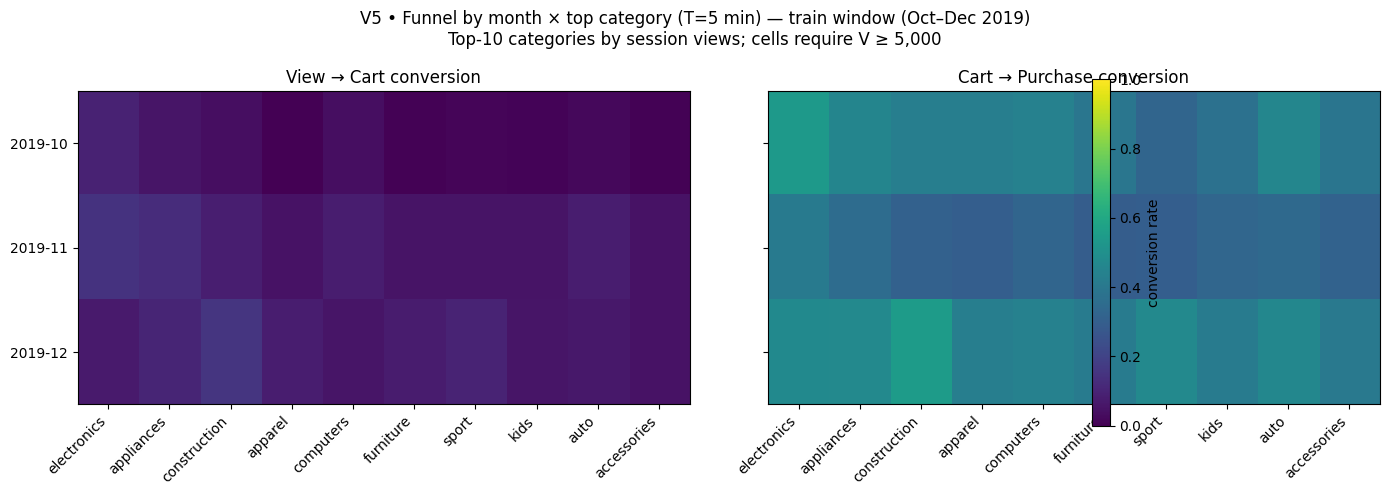

[2025-12-17T21:14:27] Why these files?
{'event_sources_used_per_month': {'2019-Dec': ['../cache_data/2019-Nov.parquet',
                                               '../cache_data/2019-Dec.parquet',
                                               '../cache_data/2020-Jan.parquet'],
                                  '2019-Nov': ['../cache_data/2019-Oct.parquet',
                                               '../cache_data/2019-Nov.parquet',
                                               '../cache_data/2019-Dec.parquet'],
                                  '2019-Oct': ['../cache_data/2019-Oct.parquet',
                                               '../cache_data/2019-Nov.parquet']},
 'min_n_per_cell': 5000,
 'months_plotted': ['2019-10', '2019-11', '2019-12'],
 'reason': 'Leak-free registries restrict to sessions that START in each month; events from '
           'prev/curr/next months capture first-T actions and purchases. Per-session, per-category '
           'flags collapse multiple

In [21]:
# =========================
# Cell 10.5 — V5 Funnel (view→cart→purchase) by month × top category
# Train window locked to Oct–Dec 2019 (window-aware, filtered if needed)
# =========================
from pathlib import Path
from datetime import datetime
import sys, math
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

import config


T              = int(getattr(config, "T_MIN", 5))
OUT            = config.OUT_DIR
DATA           = config.DATA_DIR
MONTHS_ORDERED = list(getattr(config, "MONTHS_FULL", []))

# ---- lock the window to Oct–Dec 2019 (train) ----
_MON = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
}


def month_label(mtag: str) -> str:
    """
    Convert a month tag in 'YYYY-Mon' format to 'YYYY-MM'.

    Examples
    --------
    "2019-Oct" → "2019-10"

    Parameters
    ----------
    mtag : str
        Month tag, e.g., "2019-Oct".

    Returns
    -------
    str
        Normalized month label "YYYY-MM".
    """
    y, mon = mtag.split("-")
    return f"{y}-{_MON[mon]}"


TRAIN_MONTH_TAGS = ("2019-Oct", "2019-Nov", "2019-Dec")
MONTHS_WINDOW    = list(TRAIN_MONTH_TAGS)  # <-- force Oct–Dec 2019
WINDOW_LABEL     = "train window (Oct–Dec 2019)"

TOP_K_CATEGORIES    = 10
INCLUDE_UNKNOWN_CAT = False  # set True if you want category_top == "unknown" included
MIN_N_PER_CELL      = 5_000  # require enough session mass for a (month, category) cell


def neighbor_months(order: list[str], current: str) -> list[str]:
    """
    Get [prev, current, next] month tags around `current` in `order`.

    Parameters
    ----------
    order : list[str]
        Ordered list of month tags (e.g. config.MONTHS_FULL).
    current : str
        Current month tag.

    Returns
    -------
    list[str]
        List of neighbors: previous (if any), current, next (if any).
    """
    i = order.index(current)
    out: list[str] = []
    if i > 0:
        out.append(order[i - 1])
    out.append(current)
    if i < len(order) - 1:
        out.append(order[i + 1])
    return out


# ---------- source discovery (events caches from previous cells) ----------
def discover_month_source(month: str) -> Path:
    """
    Discover an event source file for a given month, preferring cached Parquet.

    Preference order
    ----------------
    1. OUT/{month}.parquet            (Cell 0.3 converter)
    2. OUT/events_{month}.parquet     (Cell 6 event cache)
    3. DATA/{month}.parquet
    4. DATA/{month}.csv
    5. DATA/{month}.xlsx
    6. DATA/{month}.xls

    Parameters
    ----------
    month : str
        Month tag (e.g. "2019-Oct").

    Returns
    -------
    pathlib.Path
        Path to the first existing event source.

    Raises
    ------
    FileNotFoundError
        If no event source exists in OUT or DATA.
    """
    candidates = [
        OUT  / f"{month}.parquet",        # Cell 0.3 converter
        OUT  / f"events_{month}.parquet", # Cell 6 event cache
        DATA / f"{month}.parquet",
        DATA / f"{month}.csv",
        DATA / f"{month}.xlsx",
        DATA / f"{month}.xls",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No monthly events source for {month} in OUT_DIR/DATA_DIR.")


def scan_events_min(path: Path) -> pl.LazyFrame:
    """
    Minimal, typed scan with normalized time & strings for funnel computation.

    Columns retained (when present):
    * event_time
    * event_type
    * category_code
    * user_session

    Normalization:
    * `event_time` → UTC datetime (strip " UTC"/"Z"/"+00:00").
    * `event_type`, `category_code`, `user_session` → Utf8.

    Parameters
    ----------
    path : pathlib.Path
        Path to an event source file.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with minimal, normalized funnel-relevant columns.
    """
    suf = path.suffix.lower()
    if suf == ".parquet":
        lf = pl.scan_parquet(path)
    elif suf == ".csv":
        lf = pl.scan_csv(
            path,
            has_header=True,
            schema_overrides=getattr(config, "CSV_DTYPES", None),
            infer_schema_length=0,
        )
    else:
        import pandas as pd
        df = pd.read_excel(path)
        lf = pl.from_pandas(df, nan_to_null=True).lazy()

    names = lf.collect_schema().names()
    keep = [c for c in ["event_time", "event_type", "category_code", "user_session"] if c in names]
    lf = lf.select(keep)

    if "event_time" in keep:
        lf = lf.with_columns(
            pl.col("event_time")
              .cast(pl.Utf8)
              .str.replace_all(r"(?:\s?UTC|Z|\+00:00)$", "")
              .str.to_datetime(strict=False, time_zone="UTC")
        )
    for c in ("event_type", "category_code", "user_session"):
        if c in keep:
            lf = lf.with_columns(pl.col(c).cast(pl.Utf8))
    return lf


def category_top_expr() -> pl.Expr:
    """
    Expression that extracts top-level category from `category_code`.

    Behaviors:
    * If `category_code` is null → "unknown".
    * Else: split by "." and take the first token.

    Returns
    -------
    polars.Expr
        Expression yielding a `cat` column with top-level categories.
    """
    return (
        pl.when(pl.col("category_code").is_null())
          .then(pl.lit("unknown"))
          .otherwise(pl.col("category_code").str.split(by=".").list.get(0))
          .alias("cat")
    )


# ---------- registry helpers (sessions that START in the month, leak-free) ----------
def _registry_path(m: str) -> Path:
    """
    Path to the leak-free registry file for a given month.

    Returns
    -------
    pathlib.Path
        ``OUT/leakfree_registry_{m}_T{T}.parquet``.
    """
    return OUT / f"leakfree_registry_{m}_T{T}.parquet"


def ensure_registry_for_month(current_month: str) -> Path:
    """
    Ensure the leak-free session registry exists for a given month.

    The registry contains sessions that *start* in `current_month` with:

    * user_session
    * session_start
    * session_month

    It is built from prev+curr+next events to avoid boundary artifacts.

    Parameters
    ----------
    current_month : str
        Month tag (e.g., "2019-Nov").

    Returns
    -------
    pathlib.Path
        Path to ``leakfree_registry_{current_month}_T{T}.parquet``.
    """
    out = _registry_path(current_month)
    if out.exists():
        return out

    trio = neighbor_months(MONTHS_ORDERED, current_month)
    lfs = [scan_events_min(discover_month_source(m)) for m in trio]
    lf_events = pl.concat(lfs, how="vertical")
    keep_lbl  = month_label(current_month)

    lf_registry = (
        lf_events.group_by("user_session")
                 .agg(pl.col("event_time").min().alias("session_start"))
                 .with_columns(pl.col("session_start").dt.strftime("%Y-%m").alias("session_month"))
                 .filter(pl.col("session_month") == keep_lbl)
                 .select("user_session", "session_start", "session_month")
    )
    tmp = out.with_suffix(".tmp.parquet")
    if tmp.exists():
        tmp.unlink()
    try:
        lf_registry.sink_parquet(tmp, compression="zstd")
    except Exception:
        lf_registry.collect().write_parquet(tmp, compression="zstd")
    if out.exists():
        out.unlink()
    tmp.replace(out)
    return out


# ---------- per-month funnel (map step) ----------
def month_funnel(current_month: str, *, include_unknown: bool = False) -> tuple[pl.DataFrame, dict]:
    """
    Compute a monthly funnel (view → cart → purchase) by top-level category.

    For sessions that start in `current_month`, this computes:

    Per (month, category) session counts:
    * V  – sessions with any view in that category.
    * VC – sessions with any view AND any cart in that category.
    * CP – sessions with any view, any cart AND any purchase in that category.
    * VP – sessions with any view AND any purchase in that category.

    And then funnel rates:
    * r_V_to_C = VC / V
    * r_C_to_P = CP / VC
    * r_V_to_P = VP / V

    Parameters
    ----------
    current_month : str
        Month tag (e.g. "2019-Oct").
    include_unknown : bool, keyword-only
        If False, exclude category_top == "unknown" from the funnel.

    Returns
    -------
    (df, meta) : tuple
        * df   – polars.DataFrame with columns
                 [month, cat, V, VC, CP, VP, r_V_to_C, r_C_to_P, r_V_to_P].
        * meta – dict with provenance:
                 {"month", "registry", "event_sources"}.
    """
    reg_path = ensure_registry_for_month(current_month)
    trio = neighbor_months(MONTHS_ORDERED, current_month)
    srcs = [discover_month_source(m) for m in trio]

    # events limited to sessions that START in current month (semi-join)
    lf_ev = (
        pl.concat([scan_events_min(p) for p in srcs], how="vertical")
        .join(pl.scan_parquet(reg_path).select("user_session"), on="user_session", how="semi")
    )

    # top-level category + optional filter
    lf_ev = lf_ev.with_columns(category_top_expr())
    if not include_unknown:
        lf_ev = lf_ev.filter(pl.col("cat") != "unknown")

    # per-session × category flags (any view/cart/purchase in that category)
    flags = (
        lf_ev.group_by(["user_session", "cat"])
             .agg(
                 v = (pl.col("event_type") == "view").sum()     > 0,
                 c = (pl.col("event_type") == "cart").sum()     > 0,
                 p = (pl.col("event_type") == "purchase").sum() > 0,
             )
    )

    # collapse to month × category (counts are *sessions*)
    agg = (
        flags.group_by("cat")
             .agg(
                 V  = pl.col("v").sum().cast(pl.Float64),
                 VC = ((pl.col("v") & pl.col("c")).cast(pl.Int8)).sum().cast(pl.Float64),
                 CP = ((pl.col("v") & pl.col("c") & pl.col("p")).cast(pl.Int8)).sum().cast(pl.Float64),
                 VP = ((pl.col("v") & pl.col("p")).cast(pl.Int8)).sum().cast(pl.Float64),
             )
             .with_columns(month = pl.lit(month_label(current_month)))
             .select("month", "cat", "V", "VC", "CP", "VP")
    ).collect()

    # rates (safe divide)
    if not agg.is_empty():
        agg = agg.with_columns(
            r_V_to_C = pl.when(pl.col("V")  > 0).then(pl.col("VC") / pl.col("V")).otherwise(None),
            r_C_to_P = pl.when(pl.col("VC") > 0).then(pl.col("CP") / pl.col("VC")).otherwise(None),
            r_V_to_P = pl.when(pl.col("V")  > 0).then(pl.col("VP") / pl.col("V")).otherwise(None),
        )

    meta = {
        "month": current_month,
        "registry": str(reg_path),
        "event_sources": [str(p) for p in srcs],
    }
    return agg, meta


# ---------- run map-reduce over the locked window ----------
ts0 = datetime.now()
nice_print(
    ts0,
    "V5 — start (map-reduce per month)",
    obj={
        "months": MONTHS_WINDOW,
        "T": T,
        "top_k": TOP_K_CATEGORIES,
        "min_n_per_cell": MIN_N_PER_CELL,
        "include_unknown_category": INCLUDE_UNKNOWN_CAT,
        "window": WINDOW_LABEL,
    },
)

all_rows: list[pl.DataFrame] = []
provenance: list[dict] = []
for m in MONTHS_WINDOW:
    df_m, meta = month_funnel(m, include_unknown=INCLUDE_UNKNOWN_CAT)
    provenance.append(meta)
    if not df_m.is_empty():
        all_rows.append(df_m)

if not all_rows:
    raise RuntimeError("V5 produced no rows. Check inputs and earlier caches.")

df_all = pl.concat(all_rows, how="vertical")

# pick TOP_K by total V *within this window*
top_cats = (
    df_all.group_by("cat")
          .agg(total_V = pl.col("V").sum())
          .sort("total_V", descending=True)
          .head(TOP_K_CATEGORIES)
          .get_column("cat")
          .to_list()
)
df_top = df_all.filter(pl.col("cat").is_in(top_cats))

# Fixed month order for the *train* window
month_order = [month_label(m) for m in TRAIN_MONTH_TAGS]
present = set(df_top.get_column("month").to_list())
month_order = [m for m in month_order if m in present]
cat_order   = top_cats


# ---------- build matrices for heatmaps (apply MIN_N_PER_CELL) ----------
def pivot(df: pl.DataFrame, col: str, months: list[str], cats: list[str]) -> np.ndarray:
    """
    Pivot a (month, cat, col) table into a 2D grid.

    Parameters
    ----------
    df : polars.DataFrame
        DataFrame containing at least ["month", "cat", col].
    col : str
        Column name to pivot as the cell value.
    months : list[str]
        Ordered list of month labels for rows.
    cats : list[str]
        Ordered list of category labels for columns.

    Returns
    -------
    numpy.ndarray
        A matrix of shape (len(months), len(cats)) with values of `col`,
        or NaN where no data exists.
    """
    M, C = len(months), len(cats)
    Z = np.full((M, C), np.nan, dtype=float)
    if df.is_empty():
        return Z
    m_idx = {m: i for i, m in enumerate(months)}
    c_idx = {c: j for j, c in enumerate(cats)}
    for m, c, v in df.select("month", "cat", col).iter_rows():
        i, j = m_idx.get(m), c_idx.get(c)
        if i is not None and j is not None and v is not None:
            Z[i, j] = float(v)
    return Z


# Pivot rates and the underlying session counts V
Z_vc  = pivot(df_top, "r_V_to_C", month_order, cat_order)
Z_cp  = pivot(df_top, "r_C_to_P", month_order, cat_order)
Z_V   = pivot(df_top, "V",        month_order, cat_order)

# Mask sparse cells
mask_sparse = (Z_V < float(MIN_N_PER_CELL))
Z_vc[mask_sparse] = np.nan
Z_cp[mask_sparse] = np.nan

# ---------- plot (two heatmaps) ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)


def draw_heat(ax, Z: np.ndarray, title: str):
    """
    Draw a heatmap for a given matrix on a Matplotlib axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to draw on.
    Z : numpy.ndarray
        2D array of rates (NaN for missing).
    title : str
        Title for the subplot.

    Returns
    -------
    matplotlib.image.AxesImage
        The heatmap image object.
    """
    im = ax.imshow(Z, aspect="auto", origin="upper", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(cat_order)))
    ax.set_xticklabels(cat_order, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(month_order)))
    ax.set_yticklabels(month_order)
    return im


im1 = draw_heat(axes[0], Z_vc, "View → Cart conversion")
im2 = draw_heat(axes[1], Z_cp, "Cart → Purchase conversion")

# colorbar shared
cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("conversion rate")

fig.suptitle(
    f"V5 • Funnel by month × top category (T={T} min) — {WINDOW_LABEL}\n"
    f"Top-{TOP_K_CATEGORIES} categories by session views; cells require V ≥ {MIN_N_PER_CELL:,}"
)
plt.tight_layout()

# Save V5 funnel heatmaps for M2
fig_path = OUT / f"m2_vis_V5_funnel_by_category_T{T}_train.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
nice_print(datetime.now(), "V5 figure saved", obj={"path": str(fig_path)})

plt.show()

# ---------- provenance (why these files) ----------
nice_print(
    datetime.now(),
    "Why these files?",
    obj={
        "window": WINDOW_LABEL,
        "sessions_registry": [p["registry"] for p in provenance],
        "event_sources_used_per_month": {p["month"]: p["event_sources"] for p in provenance},
        "reason": (
            "Leak-free registries restrict to sessions that START in each month; events from prev/curr/next months "
            "capture first-T actions and purchases. Per-session, per-category flags collapse multiple actions to one, "
            "so the funnel isn’t inflated by repeats. Sparse (month,category) cells are masked using V ≥ threshold."
        ),
        "top_categories": cat_order,
        "months_plotted": month_order,
        "min_n_per_cell": MIN_N_PER_CELL,
    },
)


#### 🔹 V5 — Funnel by Month × Top Category (T = 5 min, train window: Oct–Dec 2019)

Purpose
Track conversion flow by top‑level category across months, separating the early view → cart step from cart → purchase. Each heatmap cell is the conversion rate for sessions that start in the month; categories shown are the top‑10 by session views and cells require sufficient volume (V ≥ 5,000) to appear.

Observations

View → Cart (left panel):
Rates are single‑digit across all categories with small month‑to‑month movement.

Nov is generally a touch higher than Oct across many categories.

Dec is mixed: construction and sport lift, while electronics/appliances lean back toward Oct levels.

Apparel and accessories stay at the lower end throughout.

Cart → Purchase (right panel):
Once in cart, conversion clusters around ~0.30–0.50 (a few cells near the mid‑0.50s).

Nov is the softest month in many categories.

Oct is often strong (e.g., electronics), and Dec rebounds—with construction and sport toward the higher end.

Stability & spread:
The stage gap (view→cart vs. cart→purchase) dominates the signal; category rank is fairly stable with only modest seasonal shifts.

Interpretation
Friction sits before the cart—lots of browsing, few adds. After an item reaches the cart, the path to purchase is comparatively efficient. High‑consideration categories (electronics, appliances, construction) convert well once engaged, while apparel/accessories remain more exploratory at the top of the funnel.

**V6 (optional)**: Missingness matrix and/or correlation heatmap.

[2025-12-17T21:14:27] V6 will read Parquet file(s):
{'filter_months': ['2019-10', '2019-11', '2019-12'],
 'paths': ['../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet',
           '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'],
 'window': 'train window (Oct–Dec 2019)'}
[2025-12-17T21:14:28] V6 figure saved
{'path': '../cache_data/m2_vis_V6_missing_corr_T5_train.png'}


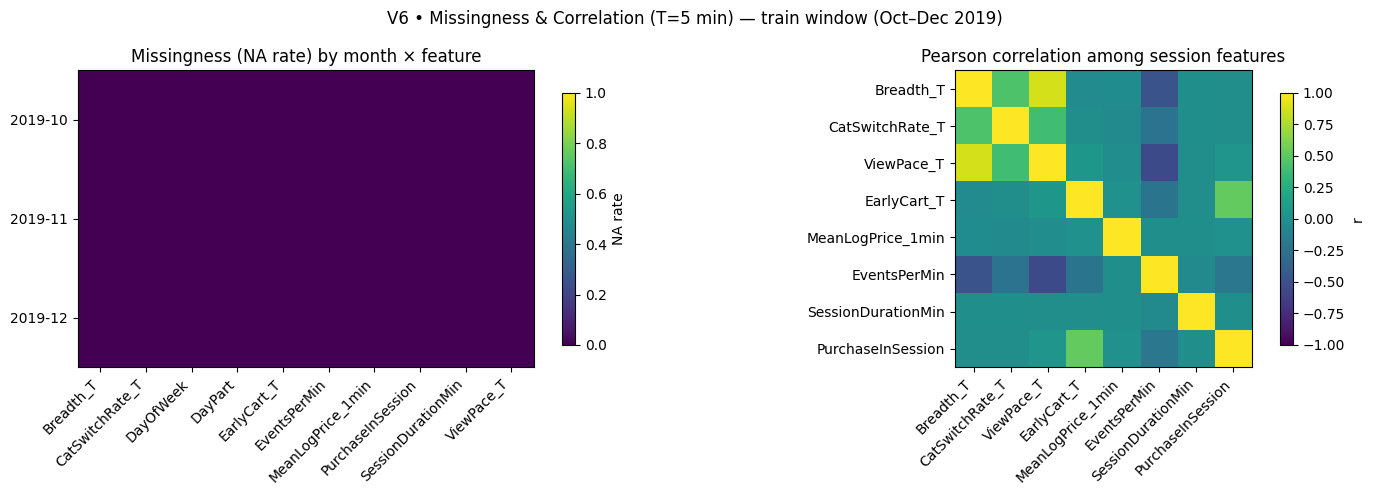

[2025-12-17T21:14:28] Top |r| correlations to target (diagnostic)
[('EarlyCart_T', 0.521261877008712), ('EventsPerMin', -0.20427154831102387),
 ('ViewPace_T', 0.04577108612342554), ('MeanLogPrice_1min', 0.014979738225577056),
 ('Breadth_T', -0.01315373992759467), ('CatSwitchRate_T', -0.011568433873341452),
 ('SessionDurationMin', -0.003527454771691319)]
[2025-12-17T21:14:28] Why these files?
{'chosen': ['../cache_data/session_features_2019-Oct_T5_SESSIONIZED.parquet',
            '../cache_data/session_features_2019-Nov_T5_SESSIONIZED.parquet',
            '../cache_data/session_features_2019-Dec_T5_SESSIONIZED.parquet'],
 'correlation_columns_used': ['Breadth_T', 'CatSwitchRate_T', 'ViewPace_T', 'EarlyCart_T',
                              'MeanLogPrice_1min', 'EventsPerMin', 'SessionDurationMin',
                              'PurchaseInSession'],
 'missingness_columns_used': ['Breadth_T', 'CatSwitchRate_T', 'ViewPace_T', 'EarlyCart_T',
                              'MeanLogPrice_1mi

In [22]:
# =========================
# Cell 10.6 — V6 Missingness matrix + Correlation heatmap (train window Oct–Dec 2019)
# =========================
from pathlib import Path
from datetime import datetime
import sys, math, itertools
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# ---------- config ----------

import config




T   = int(getattr(config, "T_MIN", 5))
OUT = config.OUT_DIR

# ---------- lock to train window Oct–Dec 2019 ----------
_MON = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
}


def yyyymm(tag: str) -> str:
    """
    Convert a month tag from 'YYYY-Mon' to 'YYYY-MM'.

    Examples
    --------
    "2019-Oct" → "2019-10"

    Parameters
    ----------
    tag : str
        Month tag (e.g. "2019-Oct").

    Returns
    -------
    str
        Normalized month label "YYYY-MM".
    """
    y, mon = tag.split("-")
    return f"{y}-{_MON[mon]}"


TRAIN_TAGS   = ("2019-Oct", "2019-Nov", "2019-Dec")
TRAIN_MONTHS = [yyyymm(m) for m in TRAIN_TAGS]
WINDOW_LABEL = "train window (Oct–Dec 2019)"


def _cand_per_month(m: str, T: int) -> list[Path]:
    """
    Candidate per-month feature files for a given month and T-window.

    Preference order
    ----------------
    1. *_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet  (rare but harmless)
    2. *_LEAKFREE_ENRICHED_TARGETS.parquet
    3. *_LEAKFREE_ENRICHED.parquet
    4. *_LEAKFREE_TARGETS.parquet
    5. *_LEAKFREE.parquet
    6. *_SESSIONIZED.parquet

    Parameters
    ----------
    m : str
        Month tag (e.g. "2019-Oct").
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate paths, not filtered for existence.
    """
    return [
        OUT / f"session_features_{m}_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet",
        OUT / f"session_features_{m}_T{T}_LEAKFREE_ENRICHED_TARGETS.parquet",
        OUT / f"session_features_{m}_T{T}_LEAKFREE_ENRICHED.parquet",
        OUT / f"session_features_{m}_T{T}_LEAKFREE_TARGETS.parquet",
        OUT / f"session_features_{m}_T{T}_LEAKFREE.parquet",
        OUT / f"session_features_{m}_T{T}_SESSIONIZED.parquet",
    ]


def _cand_combined_oct_dec(T: int) -> list[Path]:
    """
    Candidate combined feature files for the Oct–Dec 2019 train window.

    Preference order
    ----------------
    1. *_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet
    2. *_LEAKFREE_ENRICHED_COMBINED.parquet
    3. *_LEAKFREE_COMBINED_TARGETS.parquet
    4. *_LEAKFREE_COMBINED.parquet

    Parameters
    ----------
    T : int
        Early-session window length in minutes.

    Returns
    -------
    list[pathlib.Path]
        Candidate combined files (not filtered for existence).
    """
    pats = [
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED_TARGETS.parquet",
        f"session_features_2019-Oct_to_2019-Dec_T{T}_LEAKFREE_COMBINED.parquet",
    ]
    return [OUT / p for p in pats]


def choose_sources_train_oct_dec() -> tuple[list[Path], list[str], str]:
    """
    Choose session feature sources for missingness/correlation in the train window.

    Strategy
    --------
    1. Prefer any Oct–Dec combined file:
       * see :func:`_cand_combined_oct_dec` and use the newest existing.
    2. If none, fall back to per-month files for Oct, Nov, Dec:
       * accept partial coverage to keep the viz robust.
    3. As a last resort, use the newest generic LEAKFREE combined file
       and annotate as filtered from that source.

    Returns
    -------
    (paths, month_filter_labels, window_used)
        paths : list[pathlib.Path]
            Files to read from.
        month_filter_labels : list[str]
            'YYYY-MM' month labels for Oct–Dec 2019.
        window_used : str
            Label used in figure titles.

    Raises
    ------
    FileNotFoundError
        If no suitable feature files exist in OUT_DIR.
    """
    # 1) Prefer any combined Oct–Dec file
    hits = [p for p in _cand_combined_oct_dec(T) if p.exists()]
    if hits:
        p = sorted(hits, key=lambda x: x.stat().st_mtime, reverse=True)[0]
        return [p], TRAIN_MONTHS, WINDOW_LABEL

    # 2) Fall back to per-month files (accept partial if still building caches)
    per: list[Path] = []
    for m in TRAIN_TAGS:
        found = next((pp for pp in _cand_per_month(m, T) if pp.exists()), None)
        if found:
            per.append(found)
    if per:
        return per, TRAIN_MONTHS, WINDOW_LABEL

    # 3) Last resort: newest combined — we will filter to Oct–Dec if present there
    any_combined = sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_ENRICHED_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    ) or sorted(
        OUT.glob(f"session_features_*_to_*_T{T}_LEAKFREE_COMBINED*.parquet"),
        key=lambda x: x.stat().st_mtime, reverse=True,
    )
    if any_combined:
        return [any_combined[0]], TRAIN_MONTHS, WINDOW_LABEL + f" [filtered from {any_combined[0].name}]"

    raise FileNotFoundError("No suitable leak-free session feature files found in OUT_DIR.")


paths, month_filter_labels, window_used = choose_sources_train_oct_dec()
nice_print(
    datetime.now(),
    "V6 will read Parquet file(s):",
    obj={"paths": [str(p) for p in paths], "window": window_used, "filter_months": month_filter_labels},
)

# ---------- LazyFrame (filter to Oct–Dec if needed) ----------
lf_all = pl.scan_parquet([str(p) for p in paths])
schema_names = lf_all.collect_schema().names()

# Apply month filter if possible
if month_filter_labels:
    if "session_month" in schema_names:
        lf_all = lf_all.filter(pl.col("session_month").is_in(month_filter_labels))
    elif "session_start" in schema_names:
        lf_all = lf_all.filter(pl.col("session_start").dt.strftime("%Y-%m").is_in(month_filter_labels))

# Ensure there is data after filtering
n_rows = int(lf_all.select(pl.len().alias("n")).collect()["n"][0])
if n_rows == 0:
    raise RuntimeError("V6 has no rows after filtering to Oct–Dec 2019. Check caches for this window.")

# Month label expression for missingness heatmap
names = lf_all.collect_schema().names()
if "session_month" in names:
    month_expr = pl.col("session_month").alias("month")
elif "session_start" in names:
    month_expr = pl.col("session_start").dt.strftime("%Y-%m").alias("month")
else:
    month_expr = pl.lit("all").alias("month")

# ---------- pick columns ----------
CAND_MISS = [
    "Breadth_T", "CatSwitchRate_T", "ViewPace_T", "EarlyCart_T",
    "MeanLogPrice_1min", "EventsPerMin", "SessionDurationMin",
    "DayPart", "DayOfWeek", "PurchaseInSession",
]
miss_cols = [c for c in CAND_MISS if c in names]
if not miss_cols:
    raise KeyError("No expected columns found for missingness matrix.")

CAND_CORR = [
    "Breadth_T", "CatSwitchRate_T", "ViewPace_T",
    "EarlyCart_T", "MeanLogPrice_1min", "EventsPerMin",
    "SessionDurationMin", "PurchaseInSession",
]
corr_cols = [c for c in CAND_CORR if c in names]
if len(corr_cols) < 2:
    raise KeyError("Need at least two numeric features present to compute correlations.")

# ---------- Missingness by month ----------
df_miss = (
    lf_all.with_columns(month_expr)
          .group_by("month")
          .agg([pl.col(c).is_null().mean().alias(c) for c in miss_cols])
          .collect()
          .sort("month")
)
miss_months = df_miss.get_column("month").to_list()
df_miss_long = df_miss.unpivot(
    index="month",
    on=miss_cols,
    variable_name="feature",
    value_name="na_rate",
)

feat_order = sorted(df_miss_long.get_column("feature").unique().to_list())
M, C = len(miss_months), len(feat_order)
Z_miss = np.full((M, C), np.nan, dtype=float)
for m, f, r in df_miss_long.select("month", "feature", "na_rate").iter_rows():
    i = miss_months.index(m)
    j = feat_order.index(f)
    Z_miss[i, j] = float(r) if r is not None else np.nan

# ---------- Correlation heatmap (pairwise, streaming stats) ----------
exprs = []
for a in corr_cols:
    x = pl.col(a).cast(pl.Float64)
    exprs += [
        x.is_not_null().sum().alias(f"n::{a}"),
        x.sum().alias(f"sx::{a}"),
        (x * x).sum().alias(f"sxx::{a}"),
    ]

for a, b in itertools.combinations(corr_cols, 2):
    xa = pl.col(a).cast(pl.Float64)
    xb = pl.col(b).cast(pl.Float64)
    mask = xa.is_not_null() & xb.is_not_null()
    exprs += [
        mask.sum().alias(f"n::{a}::{b}"),
        pl.when(mask).then(xa).otherwise(None).sum().alias(f"sx::{a}::{b}"),
        pl.when(mask).then(xb).otherwise(None).sum().alias(f"sy::{a}::{b}"),
        pl.when(mask).then(xa * xa).otherwise(None).sum().alias(f"sxx::{a}::{b}"),
        pl.when(mask).then(xb * xb).otherwise(None).sum().alias(f"syy::{a}::{b}"),
        pl.when(mask).then(xa * xb).otherwise(None).sum().alias(f"sxy::{a}::{b}"),
    ]

stats = lf_all.select(exprs).collect().to_dicts()[0]

K = len(corr_cols)
R = np.full((K, K), np.nan, dtype=float)
for i, a in enumerate(corr_cols):
    na = float(stats.get(f"n::{a}", 0.0)) or 0.0
    R[i, i] = 1.0 if na > 1 else np.nan

for i, a in enumerate(corr_cols):
    for j, b in enumerate(corr_cols):
        if j <= i:
            continue
        key = f"{a}::{b}"
        n = float(stats.get(f"n::{key}", 0.0)) or 0.0
        if n <= 1:
            r = np.nan
        else:
            sx  = float(stats[f"sx::{key}"])
            sy  = float(stats[f"sy::{key}"])
            sxx = float(stats[f"sxx::{key}"])
            syy = float(stats[f"syy::{key}"])
            sxy = float(stats[f"sxy::{key}"])
            mx, my = sx / n, sy / n
            vx = max(sxx / n - mx * mx, 0.0)
            vy = max(syy / n - my * my, 0.0)
            denom = math.sqrt(vx * vy)
            r = (sxy / n - mx * my) / denom if denom > 0 else np.nan
        R[i, j] = R[j, i] = r

# ---------- plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missingness
ax0 = axes[0]
im0 = ax0.imshow(Z_miss, aspect="auto", origin="upper", vmin=0.0, vmax=1.0)
ax0.set_title("Missingness (NA rate) by month × feature")
ax0.set_xticks(np.arange(C))
ax0.set_xticklabels(feat_order, rotation=45, ha="right")
ax0.set_yticks(np.arange(M))
ax0.set_yticklabels(miss_months)
cb0 = fig.colorbar(im0, ax=ax0, shrink=0.85)
cb0.set_label("NA rate")

# Correlation
ax1 = axes[1]
im1 = ax1.imshow(R, vmin=-1.0, vmax=1.0, origin="upper", aspect="equal")
ax1.set_title("Pearson correlation among session features")
ax1.set_xticks(np.arange(K))
ax1.set_xticklabels(corr_cols, rotation=45, ha="right")
ax1.set_yticks(np.arange(K))
ax1.set_yticklabels(corr_cols)
cb1 = fig.colorbar(im1, ax=ax1, shrink=0.85)
cb1.set_label("r")

fig.suptitle(f"V6 • Missingness & Correlation (T={T} min) — {window_used}")
plt.tight_layout()

# Save V6 missingness + correlation figure for M2
fig_path = OUT / f"m2_vis_V6_missing_corr_T{T}_train.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
nice_print(datetime.now(), "V6 figure saved", obj={"path": str(fig_path)})

plt.show()

# ---------- top |r| to target (diagnostic) ----------
if "PurchaseInSession" in corr_cols:
    tgt = "PurchaseInSession"
    j_tgt = corr_cols.index(tgt)
    pairs = []
    for i, feat in enumerate(corr_cols):
        if feat == tgt:
            continue
        r = R[i, j_tgt]
        if not np.isnan(r):
            pairs.append((feat, float(r)))
    pairs_sorted = sorted(pairs, key=lambda x: -abs(x[1]))[:8]
    nice_print(datetime.now(), "Top |r| correlations to target (diagnostic)", obj=pairs_sorted)

# ---------- provenance ----------
nice_print(
    datetime.now(),
    "Why these files?",
    obj={
        "chosen": [str(p) for p in paths],
        "window_label": window_used,
        "reason": (
            "Leak-free session feature caches (ENRICHED/_TARGETS) are already at the session grain "
            "with engineered features and target — ideal for missingness and correlations without touching raw events."
        ),
        "missingness_columns_used": miss_cols,
        "correlation_columns_used": corr_cols,
        "months_filtered_to": TRAIN_MONTHS,
    },
)


####🔹 V6 — Missingness & Correlation (T = 5 min, Oct–Dec 2019)

Purpose
Assess data completeness and inter-feature relationships for leak‑free session features. Left: NA rate by month × feature. Right: Pearson correlations among session variables to spot redundancy before modeling.

Observations

Missingness (left):
The grid is uniformly dark across Oct, Nov, and Dec 2019 → no missing data for any feature (including calendar dummies like DayOfWeek and DayPart). Feature construction and caching look consistent.

Correlation (right):

The strongest off‑diagonal relationship is CatSwitchRate_T ↔ ViewPace_T (high positive).

Breadth_T is positively related to both ViewPace_T and CatSwitchRate_T, but a step lower than the pair above.

EventsPerMin aligns positively with ViewPace_T (both “tempo” signals).

SessionDurationMin shows negative correlation with EventsPerMin (longer sessions ≈ lower event rate) and mild positive ties to browsing volume (e.g., Breadth_T).

EarlyCart_T remains weakly correlated with most variables, suggesting a distinct early‑intent signal.

MeanLogPrice_1min is mostly weakly related to engagement features; PurchaseInSession is broadly low‑correlation, with small positive ties to MeanLogPrice_1min and EarlyCart_T.

Interpretation

Variables are complete and stable in this train window.

There is collinearity among pace/exploration features—especially CatSwitchRate_T with ViewPace_T (and, to a lesser extent, Breadth_T).

EventsPerMin vs SessionDurationMin capture tempo vs length, not the same thing; keeping both can help if the model can handle correlation structure.

### 7) Lightweight statistical probes (EDA‑level)
#### Association scans

- Categoricals → χ² + Cramér’s V (effect size) and per‑level conversion.

- Numerics → discretized mutual information with the binary target (no giant collect; uses q01–q99 clipped, fixed‑count bins and counts tables).

#### Quick logistic with spline on `Breadth_T `
To inspect the shape (univariate; no final modeling).

- Fit is weighted by session counts per breadth, so we never collect row‑level data.

In [23]:
config.DATA_DIR

PosixPath('../data')

In [24]:
# =========================
# Cell 7 — Session targets (enrich leak-free features with purchase totals)
#           Fix A: never assign to a variable named `df` (use `s` for summaries)
# =========================
from pathlib import Path
from datetime import datetime
import os, sys, gc
import polars as pl

# Keep worker count sane on Colab/shared boxes (harmless locally too)
os.environ.setdefault("POLARS_MAX_THREADS", "2")


# ---------- params ----------
MONTHS_ORDERED = list(getattr(config, "MONTHS_FULL", [])) or list(getattr(config, "MONTHS", []))
TARGET_MONTHS  = list(getattr(config, "LEAK_MONTHS", [])) or MONTHS_ORDERED
T              = int(getattr(config, "T_MIN", 5))
WRITE_COMBINED = True  # also write combined enriched file (streamed)

# ---------- helpers ----------
_MON = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04", "May": "05", "Jun": "06",
    "Jul": "07", "Aug": "08", "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12",
}


def month_label(tag: str) -> str:
    """
    Convert a month tag in 'YYYY-Mon' format to 'YYYY-MM'.

    Examples
    --------
    "2019-Oct" → "2019-10"

    Parameters
    ----------
    tag : str
        Month tag like "2019-Oct".

    Returns
    -------
    str
        Normalized "YYYY-MM" label.
    """
    y, mon = tag.split("-")
    return f"{y}-{_MON[mon]}"


def _base_path(month: str) -> Path:
    """
    Path to the per-month leak-free base features (from Cell 6).

    Parameters
    ----------
    month : str
        Month tag.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{month}_T{T}_LEAKFREE.parquet``.
    """
    # prefer previously built leak-free session features (Cell 6)
    return config.OUT_DIR / f"session_features_{month}_T{T}_LEAKFREE.parquet"


def _targets_out_path(month: str) -> Path:
    """
    Path to the per-month enriched leak-free features (with purchase totals).

    Enriched features add:
    * ItemsPurchasedInSession
    * OrderValueInSession
    * PurchaseInSession (recomputed from item count)

    Parameters
    ----------
    month : str
        Month tag.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{month}_T{T}_LEAKFREE_ENRICHED.parquet``.
    """
    # enriched (adds ItemsPurchasedInSession / OrderValueInSession / PurchaseInSession)
    return config.OUT_DIR / f"session_features_{month}_T{T}_LEAKFREE_ENRICHED.parquet"


def _combined_enriched_path(first: str, last: str) -> Path:
    """
    Path to the combined enriched leak-free file for a contiguous window.

    Parameters
    ----------
    first : str
        First month tag in the window.
    last : str
        Last month tag in the window.

    Returns
    -------
    pathlib.Path
        ``OUT_DIR/session_features_{first}_to_{last}_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet``.
    """
    return config.OUT_DIR / f"session_features_{first}_to_{last}_T{T}_LEAKFREE_ENRICHED_COMBINED.parquet"


def _build_month_targets(month: str) -> Path:
    """
    Enrich leak-free features for `month` with per-session purchase targets.

    For sessions in a given month, this computes:

    * ItemsPurchasedInSession – number of purchase events in the session.
    * OrderValueInSession – sum of price for purchase events.
    * PurchaseInSession – recomputed as 1 if ItemsPurchasedInSession > 0.

    Notes
    -----
    * Uses events from the same month only (no cross-month look-ahead).
    * If an `events_{month}.parquet` cache exists, reuses it; otherwise
      falls back to the raw ``OUT_DIR/{month}.parquet`` file.
    * Logs a small summary per month, stored in `s` (not `df`) as per Fix A.

    Parameters
    ----------
    month : str
        Month tag, e.g., "2019-Oct".

    Returns
    -------
    pathlib.Path
        Path to the enriched leak-free feature file for this month.
    """
    src_features = _base_path(month)
    out = _targets_out_path(month)
    lbl = month_label(month)

    # Build purchase totals from events of the *same month* (still leak-free).
    # If you already wrote a per-month events cache, reuse it; otherwise read minimally.
    # We compute per-session ItemsPurchasedInSession and OrderValueInSession.
    events_path = config.OUT_DIR / f"events_{month}.parquet"
    if not events_path.exists():
        # Minimal scan via discover helper (assumed from earlier cells)
        # Fallback: scan from raw data month file
        from pathlib import Path as _P
        raw = (_P(config.OUT_DIR) / f"{month}.parquet")
        if not raw.exists():
            raise FileNotFoundError(f"Month file not found: {raw}")
        lf_events = pl.scan_parquet(str(raw)).select(
            "event_type", "user_session", "price",
        )
    else:
        lf_events = pl.scan_parquet(str(events_path)).select(
            "event_type", "user_session", "price",
        )

    targets = (
        lf_events
        .filter(pl.col("event_type") == "purchase")
        .group_by("user_session")  # <-- Polars 1.x uses group_by on LazyFrame
        .agg([
            pl.len().alias("ItemsPurchasedInSession"),
            pl.col("price").sum().fill_null(0.0).alias("OrderValueInSession"),
        ])
    )

    # Re-join to per-session leak-free features (left join).
    lf_aug = (
        pl.scan_parquet(str(src_features))
          .join(targets, on="user_session", how="left")
          .with_columns([
              pl.col("ItemsPurchasedInSession").fill_null(0).cast(pl.Int64),
              pl.col("OrderValueInSession").fill_null(0.0).cast(pl.Float64),
          ])
          .with_columns(
              (pl.col("ItemsPurchasedInSession") > 0)
              .cast(pl.Int8)
              .alias("PurchaseInSession")
          )
    )

    tmp = out.with_suffix(".tmp.parquet")
    if tmp.exists():
        tmp.unlink()
    try:
        lf_aug.sink_parquet(str(tmp), compression="zstd")
    except Exception:
        _df_tmp = lf_aug.collect()
        _df_tmp.write_parquet(str(tmp), compression="zstd")
    if out.exists():
        out.unlink()
    tmp.replace(out)

    # --- Fix A: NEVER assign summaries to a variable named `df`. Use `s`.
    s = (
        pl.scan_parquet(str(out))
          .filter(pl.col("session_month") == lbl)
          .select(
              rows          = pl.len(),
              sessions      = pl.n_unique("user_session"),
              purchase_rate = pl.col("PurchaseInSession").mean(),
              items         = pl.col("ItemsPurchasedInSession").sum(),
              revenue       = pl.col("OrderValueInSession").sum(),
          )
          .collect()
          .to_dicts()[0]
    )
    nice_print(
        datetime.now(),
        f"{month} enriched summary",
        obj={
            "rows": int(s["rows"]),
            "sessions": int(s["sessions"]),
            "purchase_rate": (None if s["purchase_rate"] is None else float(round(s["purchase_rate"], 4))),
            "items_purchased": int(s["items"]),
            "order_value_sum": float(s["revenue"]),
        },
    )
    return out


# ---------- driver ----------
nice_print(datetime.now(), "Cell 7 — Session targets (enrich leak-free)", obj={"months": TARGET_MONTHS, "T": T})
enriched_paths: list[Path] = []
for m in TARGET_MONTHS:
    enriched_paths.append(_build_month_targets(m))
    gc.collect()

# ---------- optional combined enriched ----------
ENRICHED_COMBINED = None
if WRITE_COMBINED and enriched_paths:
    first, last = TARGET_MONTHS[0], TARGET_MONTHS[-1]
    ENRICHED_COMBINED = _combined_enriched_path(first, last)
    if ENRICHED_COMBINED.exists():
        ENRICHED_COMBINED.unlink()
    (
        pl.concat([pl.scan_parquet(str(p)) for p in enriched_paths], how="vertical")
          .sink_parquet(str(ENRICHED_COMBINED), compression="zstd")
    )
    nice_print(datetime.now(), "Combined enriched leak-free written", obj={"path": str(ENRICHED_COMBINED)})

# ---------- Fix A safety: if a stray dict named `df` exists, drop it ----------
if isinstance(globals().get("df", None), dict):
    del globals()["df"]
    print("[Cell 7] Removed stray `df` dict to keep downstream cells happy.")

nice_print(datetime.now(), "Cell 7 — done", obj={"months_enriched": len(enriched_paths)})


[2025-12-17T21:14:28] Cell 7 — Session targets (enrich leak-free)
{'T': 5, 'months': ['2020-Apr']}
[2025-12-17T21:14:30] 2020-Apr enriched summary
{'items_purchased': 965595,
 'order_value_sum': 244191013.43,
 'purchase_rate': 0.0675,
 'rows': 11629595,
 'sessions': 11629595}
[2025-12-17T21:14:30] Combined enriched leak-free written
{'path': '../cache_data/session_features_2020-Apr_to_2020-Apr_T5_LEAKFREE_ENRICHED_COMBINED.parquet'}
[Cell 7] Removed stray `df` dict to keep downstream cells happy.
[2025-12-17T21:14:30] Cell 7 — done
{'months_enriched': 1}


[Cell 11] df_train loaded from: ../cache_data/session_features_2020-Apr_to_2020-Apr_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet


IndexError: index 0 is out of bounds for axis 0 with size 0

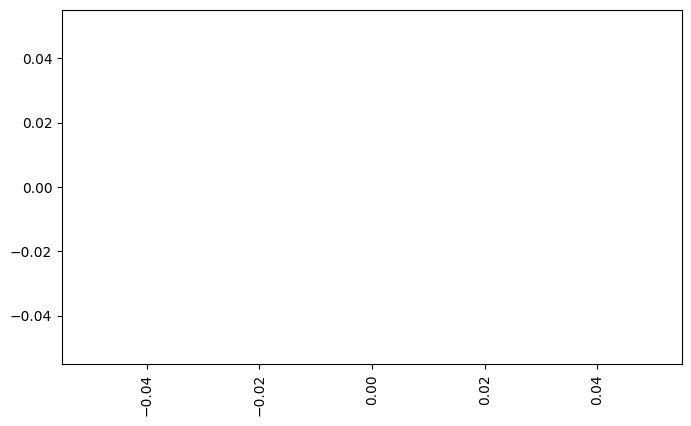

In [25]:
# =========================
# Cell 11 - V7 — VISUALS (window-locked to Oct–Dec 2019)
# =========================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# if "df_train" not in globals():
#     raise NameError("df_train is not defined; run Cell 8 before Cell 11.")
# df = df_train  # use a local alias; keep df_train intact

import json
from pathlib import Path
import pandas as pd
import polars as pl  # lightweight schema check / optional

T   = int(getattr(config, "T_MIN", 5))
OUT = Path(config.OUT_DIR)

def _pick_df_source_parquet() -> Path:
    """
    Prefer the TRAIN manifest if it exists; otherwise use the current window
    combined targets; otherwise fall back to newest *_COMBINED_TARGETS parquet.
    """
    # 1) Best: Cell 8's TRAIN manifest (pins the exact intended training file)
    man = OUT / f"cell8_predictors_manifest_T{T}_TRAIN.json"
    if man.exists():
        with open(man, "r") as f:
            src = Path(json.load(f).get("source", ""))
        if src.exists():
            return src

    # 2) Next: current config window expected combined targets
    win = list(getattr(config, "LEAK_MONTHS", [])) or []
    if win:
        first, last = win[0], win[-1]
        expected = OUT / f"session_features_{first}_to_{last}_T{T}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet"
        if expected.exists():
            return expected

    # 3) Fallback: newest combined targets in OUT_DIR
    hits = sorted(
        OUT.glob(f"session_features_*_T{T}_*_COMBINED_TARGETS.parquet"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if hits:
        return hits[0]

    raise FileNotFoundError(
        f"No *_COMBINED_TARGETS.parquet found in {OUT}. "
        f"Run Cell 8 (targets build) to create one."
    )


if "df_train" not in globals():
    src = _pick_df_source_parquet()
    df_train = pd.read_parquet(src)
    print(f"[Cell 11] df_train loaded from: {src}")

df = df_train  # keep downstream cell logic unchanged
TARGET = "PurchaseInSession"
assert TARGET in df.columns, f"Target {TARGET} not found in {list(df.columns)[:20]}..."



TARGET = "PurchaseInSession"
assert TARGET in df.columns, "Target not found; re-run Cell 8 to write *_TARGETS caches."

# ---------- enforce train window: Oct–Dec 2019 ----------
TRAIN_MONTHS = {"2019-10", "2019-11", "2019-12"}
if "session_month" in df.columns:
    df_eda = df[df["session_month"].isin(TRAIN_MONTHS)].copy()
elif "session_start" in df.columns:
    df_eda = df[df["session_start"].dt.strftime("%Y-%m").isin(TRAIN_MONTHS)].copy()
else:
    df_eda = df.copy()  # source file is already Oct–Dec combined

WINDOW_LABEL = "train window (Oct–Dec 2019)"

# ---------- helpers ----------
def _cramers_v_from_ct(ct_vals: np.ndarray) -> tuple[float, float]:
    """
    Compute chi-square and Cramér's V from a contingency table.

    Parameters
    ----------
    ct_vals : np.ndarray
        Contingency table (counts) of shape (rows, cols).

    Returns
    -------
    (chi2, v) : tuple[float, float]
        * chi2 – Pearson chi-square statistic.
        * v    – Cramér's V effect size (0–1, higher = stronger association).
    """
    obs = ct_vals.astype(float)
    n = obs.sum()
    if n == 0:
        return np.nan, np.nan
    row_s = obs.sum(axis=1, keepdims=True)
    col_s = obs.sum(axis=0, keepdims=True)
    exp = row_s @ col_s / n
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nansum((obs - exp) ** 2 / np.where(exp == 0, np.nan, exp))
    r, c = obs.shape
    # for binary target, use min(r-1, c-1) in denominator
    k = max(1, min(r - 1, c - 1))
    v = np.sqrt((chi2 / n) / k)
    return chi2, v


def _mutual_info_bits_from_ct(ct_vals: np.ndarray) -> float:
    """
    Compute discrete mutual information (in bits) from a contingency table.

    MI(X;Y) = Σ_{i,j} p_ij * log2( p_ij / (p_i * p_j) )

    Parameters
    ----------
    ct_vals : np.ndarray
        Contingency table of joint counts between a discretized feature
        and the target.

    Returns
    -------
    float
        Mutual information in bits. NaN if the table is empty.
    """
    n = ct_vals.sum()
    if n == 0:
        return np.nan
    p = ct_vals / n
    px = p.sum(axis=1, keepdims=True)
    py = p.sum(axis=0, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = p / (px @ py)
        log2_ratio = np.log2(ratio, where=(ratio > 0))
        mi = np.nansum(np.where(p > 0, p * log2_ratio, 0.0))
    return float(mi)


def _per_level_conversion(df_in: pd.DataFrame, col: str, target: str = TARGET,
                          order=None, min_n: int = 50_000):
    """
    Compute per-level conversion rate and counts for a categorical variable.

    Parameters
    ----------
    df_in : pandas.DataFrame
        DataFrame with the feature and target.
    col : str
        Categorical column name to analyze.
    target : str, default TARGET
        Binary target column (0/1).
    order : list[Any] | None, optional
        Optional explicit ordering of levels. Levels not present are ignored.
    min_n : int, default 50_000
        Minimum count required for a level to appear in the plotting subset.

    Returns
    -------
    (full, g_plot) : tuple[pd.DataFrame, pd.DataFrame]
        * full   – all levels with columns ['rate', 'n'].
        * g_plot – subset of levels where n ≥ min_n, used for charts.
    """
    g = (
        df_in.groupby(col, dropna=False)[target]
             .agg(["mean", "count"])
             .rename(columns={"mean": "rate", "count": "n"})
    )
    if order is not None:
        order = [x for x in order if x in g.index]
        g = g.reindex(order)
    g_plot = g[g["n"] >= min_n].copy()  # filter tiny for plotting
    return g, g_plot


def _discretize_series(s: pd.Series, bins: int = 20, clip_q=(0.01, 0.99)) -> pd.Series:
    """
    Discretize a numeric series into equal-frequency-ish bins (by clipping + equal-width).

    Steps
    -----
    1. Compute [lo, hi] using quantiles `clip_q`.
    2. Clip values to [lo, hi]; if degenerate, fall back to [min, max] with a tiny expansion.
    3. Build `bins + 1` edges evenly spaced in [lo, hi].
    4. Use pd.cut to map values → integer bin labels [0 .. bins-1].

    Parameters
    ----------
    s : pandas.Series
        Numeric series to discretize.
    bins : int, default 20
        Number of bins.
    clip_q : tuple[float, float], default (0.01, 0.99)
        Lower and upper quantiles for clipping.

    Returns
    -------
    pandas.Series
        Integer bin labels for non-NaN values (NaN where s was NaN).
    """
    lo = s.quantile(clip_q[0])
    hi = s.quantile(clip_q[1])
    s_clipped = s.clip(lo, hi)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = s.min(), s.max()
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            hi = lo + 1.0
    edges = np.linspace(lo, hi, bins + 1)
    labels = pd.cut(s_clipped, bins=edges, include_lowest=True, labels=False)
    return labels


# ---------- A) Categorical: per-level conversion + Cramér’s V ----------
cat_cols = [c for c in ["DayPart", "DayOfWeek"] if c in df_eda.columns]
for c in cat_cols:
    ct = pd.crosstab(df_eda[c], df_eda[TARGET], dropna=False)
    chi2, v = _cramers_v_from_ct(ct.values)
    order = (
        ["morning", "afternoon", "evening", "night"] if c == "DayPart"
        else [1, 2, 3, 4, 5, 6, 7] if str(df_eda[c].dtype).startswith(("int", "Int"))
        else None
    )
    full, to_plot = _per_level_conversion(df_eda, c, order=order, min_n=50_000)

    plt.figure(figsize=(8, 4.6))
    to_plot["rate"].plot(kind="bar")
    plt.title(
        f"{c} → purchase rate  |  χ²={chi2:,.0f},  Cramér’s V={v:.3f}  (n≥50k per level)\n{WINDOW_LABEL}"
    )
    plt.xlabel(c)
    plt.ylabel("purchase rate")
    if c == "DayOfWeek":
        plt.xticks(rotation=0)
    plt.tight_layout()
    # Save V7 categorical figure for this feature (M2)
    fig = plt.gcf()
    
    fig_path = OUT / f"m2_vis_V7_cat_{c}_T{T}_train.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    nice_print(datetime.now(), f"V7 categorical figure saved ({c})", obj={"path": str(fig_path)})
    
    plt.show()

# ---------- B) Numeric: discretized MI (bits) + simple bar viz ----------
num_candidates = [
    c for c in [
        "EventsPerMin", "SessionDurationMin", "ViewPace_T",
        "MeanLogPrice_1min", "Breadth_T", "CatSwitchRate_T",
    ] if c in df_eda.columns
]

mi_rows = []
bins = 20
clip_q = (0.01, 0.99)
for col in num_candidates:
    labels = _discretize_series(df_eda[col], bins=bins, clip_q=clip_q)
    ct = pd.crosstab(labels, df_eda[TARGET], dropna=True)
    mi_bits = _mutual_info_bits_from_ct(ct.values)
    mi_rows.append({"feature": col, "MI_bits": mi_bits})

mi_df = (
    pd.DataFrame(mi_rows)
      .sort_values("MI_bits", ascending=False)
      .reset_index(drop=True)
)

plt.figure(figsize=(8.2, 4.6))
plt.bar(mi_df["feature"], mi_df["MI_bits"])
plt.title(
    f"Discretized mutual information with target (bits)  |  bins={bins}, clip q01–q99\n{WINDOW_LABEL}"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("MI (bits)")
plt.tight_layout()

# Save V7 MI figure for M2
fig = plt.gcf()
fig_path = OUT / f"m2_vis_V7_MI_T{T}_train.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
nice_print(datetime.now(), "V7 MI figure saved", obj={"path": str(fig_path)})


plt.show()
print("[V7] MI (bits):", mi_df.to_dict(orient="records"))

# ---------- C) Shape check: Breadth_T → purchase (integer bins + smoothing) ----------
if "Breadth_T" in df_eda.columns:
    grp = (
        df_eda.groupby("Breadth_T")[TARGET]
              .agg(["mean", "count"])
              .rename(columns={"mean": "rate", "count": "n"})
              .sort_index()
    )

    MIN_N_PER_POINT = 5_000
    g = grp[grp["n"] >= MIN_N_PER_POINT].copy()
    if not g.empty:
        win = 3  # moving-average window for the dashed smoother
        smooth = g["rate"].rolling(window=win, center=True, min_periods=1).mean()

        plt.figure(figsize=(9, 5))
        plt.plot(
            g.index.values, g["rate"].values,
            marker="o", linestyle="-",
            label=f"integer rate (n≥{MIN_N_PER_POINT:,})",
        )
        plt.plot(
            g.index.values, smooth.values,
            linestyle="--",
            label=f"smoothed (win={win})",
        )
        plt.title(f"Breadth_T → PurchaseInSession (integer bins)\n{WINDOW_LABEL}")
        plt.xlabel("Breadth_T (integer)")
        plt.ylabel("purchase rate")
        plt.legend(loc="upper right", frameon=False)  # explicit legend
        plt.tight_layout()
         # Save V7 Breadth_T shape figure for M2
        fig = plt.gcf()
        fig_path = OUT / f"m2_vis_V7_breadth_shape_T{T}_train.png"
        fig.savefig(fig_path, dpi=150, bbox_inches="tight")
        nice_print(datetime.now(), "V7 breadth shape figure saved", obj={"path": str(fig_path)})
        plt.show()
    else:
        print(f"[V7] No Breadth_T bins with n ≥ {MIN_N_PER_POINT:,} — skipping curve.")

print("[V7] Visuals rendered for", WINDOW_LABEL)


In [ ]:
# --- Cell 11.1
# --- Force train window filter (Oct–Dec 2019) for plotting ---
_train_months = {"2019-10", "2019-11", "2019-12"}
if "session_month" in df.columns:
    df_train = df[df["session_month"].isin(_train_months)].copy()
elif "session_start" in df.columns:
    # if you only have timestamps, derive YYYY-MM inline
    df_train = df[df["session_start"].dt.strftime("%Y-%m").isin(_train_months)].copy()
else:
    df_train = df  # nothing to filter by; already train window from the file


# --- Spline plot with explicit legend and window label ---
def plot_breadth_logit_spline(
    df_in: pd.DataFrame,
    target: str = "PurchaseInSession",
    min_n: int = 5_000,
    n_knots: int = 6,
    exclude_zero: bool = True,
    window_label: str = "train window (Oct–Dec 2019)",
):
    """
    Plot a smoothed logit spline for Breadth_T → purchase rate.

    This function works on **aggregated** bins of Breadth_T, not raw rows, and fits
    a cubic regression spline on the logit scale using weighted least squares
    (IRLS-style) to capture the univariate shape.

    Pipeline
    --------
    1. Group by integer Breadth_T and compute:
       * buyers = sum(target)
       * n      = count
    2. Optionally drop Breadth_T = 0 bins (non-browsing cohort).
    3. Keep only bins with n ≥ `min_n`.
    4. Scale Breadth_T to u ∈ [0, 1], build a cubic spline basis with `n_knots`
       interior knots placed at weighted quantiles of u (weights = n).
    5. Fit a binomial logit model on aggregated data using IRLS, with per-bin
       weights n.
    6. Plot:
       * empirical rate per Breadth_T bin
       * smoothed spline curve on a dense grid.

    Parameters
    ----------
    df_in : pandas.DataFrame
        DataFrame containing at least `Breadth_T` and `target`.
    target : str, default "PurchaseInSession"
        Binary target column (0/1 or bool).
    min_n : int, default 5_000
        Minimum count per Breadth_T bin required to be included in the fit.
    n_knots : int, default 6
        Number of interior knots for the cubic spline on [0,1].
    exclude_zero : bool, default True
        If True, drop Breadth_T == 0 bins (non-browsing cohort).
    window_label : str, default "train window (Oct–Dec 2019)"
        Label added in the plot title to indicate the evaluation window.

    Notes
    -----
    * The fit is purely univariate and does not adjust for other covariates.
    * This is intended as an EDA diagnostic; it does not write any files.
    """
    import numpy as np, matplotlib.pyplot as plt

    # ---- aggregate by integer Breadth_T
    grp = (
        df_in.groupby("Breadth_T")[target]
             .agg(["sum", "count"])
             .rename(columns={"sum": "buyers", "count": "n"})
             .sort_index()
    )
    if exclude_zero:
        grp = grp.loc[grp.index >= 1]
    grp = grp.loc[grp["n"] >= min_n]
    if grp.empty:
        print(f"[Breadth spline] No bins with n ≥ {min_n:,}.")
        return

    x = grp.index.values.astype(float)
    n = grp["n"].values.astype(float)
    ybar = (grp["buyers"] / grp["n"]).values.astype(float)

    # ---- cubic regression-spline basis on scaled u in [0,1]
    x_min, x_max = float(x.min()), float(x.max())
    span = max(1e-9, x_max - x_min)
    u = (x - x_min) / span

    def wq(x, w, qs):
        """
        Weighted quantiles of x with weights w.

        Parameters
        ----------
        x : np.ndarray
            Values in [0,1].
        w : np.ndarray
            Non-negative weights.
        qs : array-like
            Quantiles in [0,1].

        Returns
        -------
        np.ndarray
            Weighted quantile positions.
        """
        o = np.argsort(x)
        xs, ws = x[o], w[o]
        cw = np.cumsum(ws)
        cw = cw / cw[-1]
        return np.interp(qs, cw, xs)

    qs = np.linspace(0, 1, n_knots + 2)[1:-1] if n_knots > 0 else []
    knots = wq(u, n, qs) if len(qs) else np.array([], dtype=float)

    def design(z, k):
        """
        Build cubic regression-spline design matrix on z ∈ [0,1].

        Basis = [1, z, z^2, z^3, (z - k1)_+^3, ..., (z - kM)_+^3].
        """
        cols = [np.ones_like(z), z, z**2, z**3]
        for kk in k:
            cols.append(np.maximum(z - kk, 0.0) ** 3)
        return np.column_stack(cols)

    X = design(u, knots)

    # ---- IRLS for binomial logit with bin weights n
    eps = 1e-9
    p0 = np.clip(ybar, eps, 1 - eps)
    eta = np.log(p0 / (1 - p0))
    beta = np.zeros(X.shape[1])
    for _ in range(60):
        p = 1.0 / (1.0 + np.exp(-eta))
        W = np.maximum(n * p * (1 - p), eps)
        z = eta + (ybar - p) / np.maximum(p * (1 - p), eps)
        XtW = X.T * W
        A = XtW @ X + 1e-6 * np.eye(X.shape[1])
        b = XtW @ z
        beta_new = np.linalg.lstsq(A, b, rcond=None)[0]
        eta_new  = X @ beta_new
        if np.max(np.abs(beta_new - beta)) < 1e-8:
            beta, eta = beta_new, eta_new
            break
        beta, eta = beta_new, eta_new

    # ---- smooth curve on a dense grid
    grid = np.linspace(x_min, x_max, 400)
    ug   = (grid - x_min) / span
    Xg   = design(ug, knots)
    p_hat = 1.0 / (1.0 + np.exp(-(Xg @ beta)))

    # ---- plot with legend
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    ax.plot(
        x,
        ybar,
        marker="o",
        linestyle="-",
        label=f"Empirical (per breadth), n≥{min_n:,}",
    )
    ax.plot(
        grid,
        p_hat,
        linestyle="-",
        label=f"Spline (logit WLS), knots={len(knots)}",
    )
    ax.set_title(
        "Univariate shape: Breadth_T → PurchaseInSession (spline, aggregated)\n"
        + window_label
    )
    ax.set_xlabel("Breadth_T (integer)")
    ax.set_ylabel("purchase rate")
    ax.legend(loc="upper right", frameon=False)  # explicit legend
    plt.tight_layout()
    # Save V7 spline figure for M2
    fig = plt.gcf()
    
    fig_path = OUT / f"m2_vis_V7_breadth_spline_T{T}_train.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    nice_print(datetime.now(), "V7 spline figure saved", obj={"path": str(fig_path)})
    
    plt.show()


# call it
plot_breadth_logit_spline(
    df_train,
    target="PurchaseInSession",
    min_n=5_000,
    n_knots=6,
    exclude_zero=True,
    window_label="train window (Oct–Dec 2019)",
)


#### 🔹 V7 — Lightweight Statistical Probes (EDA-level, **Oct–Dec 2019 train window**)

**Purpose.**  
Model-free scans of how early-session features relate to the binary target `PurchaseInSession`.  
Methods:  
- χ² + *Cramér’s V* for categorical features (effect size + per-level conversion)  
- *Mutual Information (MI)* for numeric features (non-parametric association)  
- Spline-based logit fit for `Breadth_T` to inspect curvature

---

### 🟦 A) Categorical associations

| Feature | Cramér’s V | Observed pattern | Interpretation |
|:--|:--:|:--|:--|
| **DayPart** | ≈ 0.037 | Morning ≈ 7.3 %; Afternoon ≈ 5.6 %; Night ≈ 5.8 %; Evening ≈ 4.7 % | Small but reliable baseline shifts by time of day |
| **DayOfWeek** | ≈ 0.031 | Sunday (≈ 7.8 %) highest; Friday (≈ 5.3 %) lowest; others ≈ 5.8–6.3 % | Weekend lift is minor but consistent |

→ Both temporal variables only shift baseline conversion; they don’t alter behavioral shape.

---

### 🟩 B) Numeric associations (Mutual Information)

| Feature | MI (bits) | Rank | Comment |
|:--|--:|:--:|:--|
| **EventsPerMin** | 0.048 | 1 | Strongest predictor — higher interaction intensity → more purchases |
| **SessionDurationMin** | 0.013 | 2 | Longer sessions raise likelihood but with diminishing returns |
| **ViewPace_T** | 0.008 | 3 | Faster pace signals stronger intent |
| **MeanLogPrice_1min** | ≈ 0.0015 | 4 | Tiny global effect |
| **Breadth_T** | ≈ 0.0006 | 5 | Weak on its own; likely interacts with engagement |
| **CatSwitchRate_T** | ≈ 0.0002 | 6 | Negligible stand-alone signal |

→ Engagement-intensity features dominate; exploration breadth and switching matter only in context.

---

### 🟨 C) Univariate shape — `Breadth_T → PurchaseInSession`

- Peak around **Breadth ≈ 2** (≈ 7 – 7.5 % purchase rate)  
- Gradual decline to ≈ 4.5 – 4.7 % by Breadth ≥ 10  
- Minor bump near Breadth ≈ 13–14 then flattens  
- `Breadth = 0` is an anomaly (~ 60 % conversion, tiny volume) → treat with a flag (`ZeroBreadth_T`)

---

### 🧭 Interpretation

- Temporal features shift baselines (V ≈ 0.03 – 0.04) but don’t change within-session trends.  
- `Breadth_T` shows a clear small inverted-U: *modest exploration helps; too much hurts.*  
- Engagement (`EventsPerMin`, `SessionDurationMin`, `ViewPace_T`) remains the primary driver.

---




### **Takeaways**

- The relationship between early-session breadth and purchases is weakly non-monotone (doesn’t move consistently in one direction), showing that intermediate browsing breadths have a slightly higher likelihood of resulting in purchases.
- Temporal covariates (independent variables), such as:
  - day-part
  - day-of-week
  - month

    Primarily shift baseline conversion levels instead of changing the direction of within-session patterns, like:
    **```As Breadth_T increases, purchase rate first dips then rises a bit```**

#### **Milestone 3 considerations for modeling**

- Analysis indicates that engagement metrics are the primary predictors of purchase behavior, while the initial breadth of browsing shows at most a minor non-linear correlation that may disappear once basic engagement factors are controlled for. In short:
  - Primary engagement predictors: `EventsPerMin, SessionDurationMin, ViewPace_T`.

  - Controlling for engagement: include them as covariates so that the Breadth_T effect is evaluated within comparable engagement levels, not across mixed ones.


### 8) Surprises (explicit)


| **Expected X**                                                                                                                                          | **Saw Y**                                                                                                                                            | **Why it Matters / Implications for RQ and Features**                                                                                                                                                                                                        |
| :------------------------------------------------------------------------------------------------------------------------------------------------------ | :--------------------------------------------------------------------------------------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Expected:** A strong positive link between **Breadth_T** and purchase — more exploration → higher intent.                                             | **Saw:** Only a *weak, slightly inverted-U* curve; moderate breadth performed marginally better, while very low or very high breadth converted less. | *Quantity of exploration* isn’t a reliable early-signal. The “explore-then-buy” idea is confounded by pace and duration. Breadth_T may need redefining as a *normalized* metric (e.g., breadth per minute or relative to events) to retain predictive value. |
| **Expected:** High **CatSwitchRate_T** (frequent category jumps) would sharply *decrease* purchase likelihood — assuming erratic browsing = indecision. | **Saw:** Almost **no information gain** (MI ≈ 0.0002 bits); conversion changed little across low vs high switchers.                                  | Early category jumps aren’t inherently bad; they may represent multi-category or gift shoppers. Treat CatSwitchRate_T as **contextual**, not as a penalty, or interact it with signals of session intent (e.g., price level or brand repeats).               |
| **Expected:** Temporal covariates (DayPart, DayOfWeek, Month) would be negligible noise.                                                                | **Saw:** Consistent but *small-magnitude* level shifts (morning/weekend lift ≈ 2–3 pp).                                                              | These shift the **baseline conversion rate** but not the shape of within-session patterns. They serve as **additive controls** (intercept shifts) rather than drivers of behavioral change.                                                                  |
| **Expected:** Engagement variables (pace/duration) would act as secondary controls.                                                                     | **Saw:** **EventsPerMin** and **SessionDurationMin** were **dominant predictors** (~80× stronger MI than Breadth_T).                                 | Engagement intensity is the **primary predictor** of conversion. This reframes the RQ: early exploration effects must be tested *conditional on engagement*. Future features should emphasize **tempo** (actions per minute) over raw counts.                |


#### **Summary**
>Early-session breadth and switch categories behave differently than one might expect; both show weak or insignificant correlations with purchases when engagement is held constant. While baseline conversion levels are influenced by temporal variables, the slopes of behavioral trends remain consistent. The most significant indicators are engagement-intensity variables such as Events Per Minute, Session Duration (in minutes), and View Pace. Therefore, the next step in modeling should control for these variables when examining the impact of early exploration.

### 9) Next steps (pre‑Milestone‑3 plan)

#### **Modeling Roadmap**

| **Step**                                | **Goal**                                                     | **Notes & Rationale**                                        |
| :-------------------------------------- | :----------------------------------------------------------- | :----------------------------------------------------------- |
| **1. Baseline (statistical)**           | Train a **regularized logistic regression** and a **Generalized Additive Model (GAM)** with spline terms for **Breadth_T** to reproduce and quantify the inverted-U found in EDA. | Transparent models show direction, curvature, and calibration. Regularization (L2 / Elastic-Net) controls collinearity among engagement variables. |
| **2. Non-linear (machine learning)**    | Fit **Gradient-Boosted Trees (GBTs)** (e.g., XGBoost / LightGBM) as a more flexible benchmark. | Captures interaction effects such as Breadth × Pace or Breadth × CategorySwitchRate without manual splines. Interpretability will rely on SHAP plots. |
| **3. Feature control & encoding**       | Transform engineered session-level variables (**Breadth_T**, **CatSwitchRate_T**, **ViewPace_T**, **EarlyCart_T**) into model-ready numeric form. <br>– Scale continuous rates (log / z-score). <br>– Binary-encode EarlyCart_T. <br>– One-hot encode DayPart / Month. | Aligns with the professor’s guidance to make session-level features model-ready and compare models that handle behavioral non-linearity. |
| **4. Temporal validation**              | Use **time-split validation** — train on early months (Oct–Dec 2019), test on later ones (Jan–Mar 2020). | Prevents leakage from future sessions into training; mirrors real deployment. |
| **5. Evaluation metrics**               | **ROC-AUC** (discrimination), **PR-AUC** (class imbalance), and **Brier score** (calibration). | Tracks both ranking power and probability accuracy. Consistent with Milestone 1 hypotheses and professor feedback. |
| **6. Interpretability & visualization** | – For logistic/GAM: partial-dependence plots to verify the inverted-U. <br>– For GBT: SHAP summary and feature importance ranking. | Confirms whether EDA relationships (e.g., engagement dominance, weak breadth effect) persist after controlling for correlated variables. |

---

##### Feature Engineering Extensions

1. **Engagement normalization**  
   - `Breadth_perMin = Breadth_T / SessionDurationMin`  
   - `SwitchRate_perView = CatSwitchRate_T / ViewPace_T`  
     Normalized versions test whether breadth still matters once engagement intensity is held constant.

2. **Phenotype clustering (optional)**  
   - Run **k-means** on {Breadth_T, CatSwitchRate_T, ViewPace_T} (using only training months) to discover session “types” (e.g., focused, skimming, wandering).  
   - Add cluster ID as a categorical feature or use it for segmented evaluation.  
   - This answers the *user-phenotype* question while staying at session granularity.

3. **Temporal controls**  
   - Add `DayPart`, `DayOfWeek`, and `session_month` as additive baseline shifters (rather than interaction terms), since they affect overall conversion level not behavioral shape.

---

##### Hypothesis Translation to Modeling

| **Hypothesis**                  | **How it will be tested**                                    |
| :------------------------------ | :----------------------------------------------------------- |
| **H1a (Breadth_T inverted-U)**  | Inspect spline coefficients in GAM and partial-dependence for Breadth_T in GBT. |
| **H1b (CatSwitchRate_T ↓)**     | Expect flat or negative marginal effect; validate via SHAP importance. |
| **H1c (Pace / EarlyCart ↑)**    | Expect strong positive effects; compare magnitudes vs. Breadth_T. |
| **H2 (Engagement confounding)** | Add `EventsPerMin` and `SessionDurationMin` as controls to see if Breadth_T’s effect attenuates or changes sign. |

---

##### Validation & Ethics

- **Leakage prevention:** All predictors computed only from the first T minutes; train/test split is temporal.  
- **Privacy:** All features remain session-level and anonymous; no user identifiers or tracking.  
- **Attribution:** Dataset source (Kaggle REES46 multi-category store) will be cited per professor’s guidelines.  

---

##### Expected Outcomes for Milestone 3

1. **Compare interpretability vs robustness:**  
   Logistic/GAM for transparency vs GBT for accuracy.  
2. **Quantify behavioral feature impact:**  
   SHAP and coefficients should confirm engagement metrics dominate and Breadth_T is secondary.  
3. **Assess temporal stability:**  
   Evaluate AUC and Brier drift across months to check generalization.  
4. **Optional clustering extension:**  
   If session phenotypes improve calibration or segment performance, document as a future direction.  

---




#### **Data Preparation & Feature Engineering Strategy**

##### **1. Missing-Data Handling**

| **Variable Type**                                            | **Strategy**                                                 | **Notes**                                                    |
| :----------------------------------------------------------- | :----------------------------------------------------------- | :----------------------------------------------------------- |
| **Numerical features** (e.g., `price`, `EventsPerMin`, `SessionDurationMin`, `MeanLogPrice_1min`) | Impute with **median** of training window; add a binary “is_missing” flag where rates of missingness are non-trivial. | Preserves central tendency and keeps imputation logic leak-free (fit medians on training months only). |
| **Categorical features** (e.g., `brand`, `category_top`, `DayPart`, `Month`) | Replace nulls with `"unknown"` category; one-hot encode later. | Prevents category reindexing errors between train/test splits. |
| **Binary flags** (e.g., `EarlyCart_T`)                       | Leave missing as 0 when logically equivalent to “no event”; otherwise impute from session context. | Simple and transparent rule avoids over-imputation.          |
| **Derived ratios or rates**                                  | Clip or fill with 0 only if denominators are 0; never propagate division-by-zero artifacts. | Ensures stability for pace and switch-rate features.         |

---

##### **2. Transformations**

| **Feature**                                                  | **Transform**                                                | **Rationale**                                                |
| :----------------------------------------------------------- | :----------------------------------------------------------- | :----------------------------------------------------------- |
| `price`, `MeanLogPrice_1min`, `SessionDurationMin`, `EventsPerMin` | **log(1 + x)** then **z-score**                              | Normalizes heavy-tailed variables; stabilizes model coefficients. |
| `ViewPace_T`, `CatSwitchRate_T`                              | **z-score scaling**                                          | Keeps rates comparable across models; centers around mean = 0 for regularization. |
| `Breadth_T`                                                  | Optionally **sqrt** or **log1p** to compress extreme values; feed raw into GAM spline. | Reduces leverage from long-tail sessions with unusually high breadth. |
| `DayPart`, `DayOfWeek`, `session_month`, `phenotype_cluster` | **One-hot encoding** (low cardinality).                      | Ensures interpretability; compatible with logistic/GAM/GBTs. |

All transformations are **fit on training data only** to maintain temporal purity.

---

##### **3. Candidate Feature Engineering**

| **Feature Name**                | **Definition**                                               | **Purpose / Hypothesis**                                     |
| :------------------------------ | :----------------------------------------------------------- | :----------------------------------------------------------- |
| `Breadth_perMin`                | `Breadth_T / SessionDurationMin`                             | Controls breadth for session length; tests whether exploration intensity, not count, predicts purchase. |
| `SwitchRate_perView`            | `CatSwitchRate_T / ViewPace_T`                               | Captures category volatility adjusted for browsing speed.    |
| `Depth_perCategory`             | `Views_T / unique(category_top)`                             | Indicates focus depth within categories.                     |
| `EngagementIndex`               | Composite z-score of (`EventsPerMin`, `ViewPace_T`, `SessionDurationMin`) | Single summary of session intensity; simplifies interaction terms. |
| `EarlyCart_T`                   | Binary (1 = cart in first T min)                             | Strong early-intent signal; benchmark for quick conversions. |
| `PhenotypeCluster` *(optional)* | Cluster ID from k-means on {`Breadth_T`, `CatSwitchRate_T`, `ViewPace_T`} | Adds behavioral archetype context (focused vs exploratory sessions). |

---

##### **4. Implementation Rules**

- All preprocessing (imputation, scaling, encoding) pipelines will be **fit on training months** and **applied to test months** to avoid data leakage.  
- Use **scikit-learn Pipelines** or equivalent to ensure reproducibility and version control of transformations.  
- Store fitted scalers/imputers in the project’s `cache_data/` directory for Milestone 3 reuse.

---

**Summary:**  

> Missing values should be addressed transparently, either by using the median or by filling them with "unknown" labels and explicitly flagging these entries. Engagement metrics that exhibit heavy-tailed distributions should be log-scaled and standardized. Categorical variables should be converted using one-hot encoding, along with a limited set of engineered features such as normalized breadth, switch rate over view, engagement index, and behavioral clusters. These enhancements should improve the model's ability to capture the diversity of behaviors in initial sessions without increasing the risk of data leakage.



### **10) Ethics, Attribution, and Documentation**

#### **Ethics and Privacy**

- **Data minimization:** All analysis and modeling operate strictly at the **session level**. No persistent user IDs, demographic fields, or cross-session linkages are used.  
- **Aggregation over identification:** Each record represents aggregated interactions within a single browsing session, not a traceable individual.  
- **No re-identification risk:** The dataset lacks personally identifiable information (PII); no attempt is made to infer or reconstruct user identities.  
- **Purpose limitation:** Features are designed to study behavioral patterns and model purchase intent, not to profile or target specific individuals.  
- **Reproducibility & transparency:** All preprocessing (imputation, scaling, encoding) steps are logged in notebooks and stored in versioned scripts within the project folder, ensuring auditability.  

#### **Attribution**

- **Dataset source:**  
  *Kaggle — “E-commerce Behavior Data from Multi-Category Store (REES46, 2019–2020)”*  
  https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store  
- **License:** Dataset provided under CC BY 4.0; attribution included in project documentation.  
- **Citations:** Any external methods (e.g., Polars, scikit-learn, SHAP, XGBoost) are cited in the final report’s references section.

#### **Documentation Practices**

- Each milestone notebook begins with a configuration cell defining global paths and constants (`DATA_DIR`, `OUT_DIR`, `T_MIN`, `MONTHS`).  
- All transformation, feature-engineering, and modeling steps are modularized for clarity and reuse.  
- Outputs (plots, intermediate caches, metrics) are timestamped and saved to `project/cache_data/` for reproducibility.  
- Markdown sections document rationale, assumptions, and parameter choices inline with the code to maintain a full experimental record.
